# UK Biobank — Clinical-Trials Impact

How UK Biobank research reaches into **clinical trials**. This notebook drills into the
**151** trials that Dimensions links to UK Biobank, with one framing point kept front of
mind for the write-up:

> **These are not trials *run by* UK Biobank.** They are clinical trials whose registry
> record **references UKB-related papers** — *every one of the 151 trials cites at least
> one paper in our UKB corpus* (§8). So the story is **influence / impact**: UKB findings
> are informing the design and rationale of real-world trials, and that pipeline is a case
> for continued / expanded funding.

**Sections**
1. **Setup** — imports, environment, the shared `STYLE` dict (verbatim from `…_00_all`)
2. **Data loading, cleaning & missing-data report** — CT-specific parsing (diseases, org
   sectors, enrollment, referenced papers) + a full missing report
3. **What — diseases studied** — MeSH (as shipped, and **rebuilt** from the CTgov
   API as condition-**leaf** terms), free-text `conditions` (word cloud), and **RCDC**
   categories; all three axes mapped to **ICD-10 chapters**
4. **Status** — aggregated trial lifecycle stage, by study type
5. **Recruitment size** — planned enrollment per trial (`study_participants`)
6. **When** — trials by start year
7. **Who / where** — organisations by country **and sector** (academia vs industry vs …)
8. **The UKB papers behind the trials** — match `publication_ids` to `df_dimensions`,
   persist the matched set, and explore what those high-impact papers are about
9. **Combined panel** — the headline views in one figure

> **Modularisation note.** Functions are pure and `STYLE`-driven, ready to lift into
> `src/utils/nonacademic_utils.py` alongside the helpers shared with `…_00_all`.

## 1. Setup

Identical to `…_00_all.ipynb` — same imports, working directory, and the single shared
formatting dictionary `STYLE` (four-colour palette, sizes, dpi) that every figure reads.

In [1]:
import os
import sys
import re
import ast
import json
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Make `src` importable and anchor all paths on the repo root, regardless of the
# directory this notebook is launched from (repo root, src/, or src/data_analysis/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, filter_analysis_window

# Reuse the patent country matcher (pycountry + fuzzy) for the world map.
from utils import shared_patent_utils as patent


In [2]:
# =============================================================================
# SHARED FORMATTING DICTIONARY  -- every figure reads from this
# =============================================================================
# The palette, figure sizes, font sizes, semantic colour roles and output directory
# live in universal_settings.yml at the repo root, section style.notebooks.04_non_academic_01_clinical_trials.
# load_style merges the shared `base` with this notebook's overrides, resolves the
# semantic roles (c_accent, c_gold, c_green, c_primary) against the palette, registers the result for
# savefig()/extended_palette() and pushes it into rcParams — everything the STYLE
# literal used to do here, minus the drift between notebooks.
from utils.shared_style import apply_style, extended_palette, load_style, savefig, use_style
from utils.shared_style import apply_typography, set_title
apply_typography()
STYLE = load_style("04_non_academic_01_clinical_trials")

print("STYLE ready — palette:", STYLE["colors"])


STYLE ready — palette: ['#344874', '#FFBB00', '#2A9D8F', '#5B8DB8', '#E76F51', '#8E6C9E']


## 2. Data loading, cleaning & missing-data report

The parsing helpers (`parse_listcol`, `parse_dictcol`, `item_names`, `count_items`,
`split_for_levels`, `add_for_columns`, `missing_report`) are **the same rules** as
`…_00_all.ipynb`. On top of them this notebook adds four CT-specific derivations:

* **diseases** — `mesh_terms` (controlled vocabulary) and `conditions` (free text)
* **organisation sector** — each research org's Dimensions `types` mapped to a sector
  (Academia / Healthcare / Industry / Government / Nonprofit / Other)
* **recruitment size** — `study_participants` (planned enrollment)
* **referenced papers** — `publication_ids` (the UKB papers each trial cites)

In [3]:
from utils.shared_showcase import (parse_listcol, parse_dictcol, item_names,
                                   count_items, count_items_frac)
# =============================================================================
# PARSING HELPERS — verbatim from ..._00_all.ipynb (same cleaning rules)
# =============================================================================
# ---- Fields of Research (FOR, 2020 ANZSRC) L2/L4 splitter -------------------
# Shared implementation: src/utils/for_utils.py. It resolves the FOR column itself —
# newer Dimensions exports renamed `category_for_2020` -> `category_for` (same taxonomy),
# and the old local copy SILENTLY returned the frame unchanged when the column was
# missing, producing no for_l2/for_l4 at all. The shared version raises instead.
from utils.shared_for import split_for_levels, add_for_columns, resolve_for_column


def _col_kind(series):
    for v in series.dropna():
        if isinstance(v, list):
            return "list"
        if isinstance(v, dict):
            return "dict"
        if isinstance(v, str):
            s = v.strip()
            if s.startswith("["):
                return "list"
            if s.startswith("{"):
                return "dict"
        return "flat"
    return "empty"


def missing_report(df, cols=None):
    n = len(df)
    cols = list(df.columns) if cols is None else cols
    rows = []
    for c in cols:
        kind = _col_kind(df[c])
        miss = int(df[c].isna().sum())
        if kind == "list":
            ne = int(df[c].apply(lambda x: len(parse_listcol(x)) > 0).sum())
        elif kind == "dict":
            ne = int(df[c].apply(lambda x: len(parse_dictcol(x)) > 0).sum())
        else:
            ne = n - miss
        rows.append((c, kind, miss, round(100 * miss / n, 1), ne, round(100 * ne / n, 1)))
    return (pd.DataFrame(rows, columns=["column", "kind", "n_missing", "%_missing",
                                        "n_nonempty", "%_nonempty"])
            .sort_values("%_missing", ascending=False, ignore_index=True))

In [4]:
# =============================================================================
# ORGANISATION SECTOR — Dimensions `types` first, then infer the untyped from the name
# =============================================================================
# research_orgs entries carry a `types` list, e.g. ['Education'], ['Company'], ['Healthcare'].
# Two steps, because ~5% of orgs come through with a non-committal GRID type
# ('Facility', 'Other') or no type at all — and those were nearly all universities,
# companies and hospitals that GRID simply hadn't classified (see the audit: 28 'Other'
# orgs, of which only 2 were genuinely ambiguous).
#
#   step 1  trust the CLEAR Dimensions types (Education/Company/Healthcare/Government/Nonprofit)
#   step 2  for 'Facility' / 'Other' / untyped, INFER the sector from the org name; only
#           orgs that match nothing stay 'Other'
#
# The two sectors the impact story cares about most are ACADEMIA and INDUSTRY.
import re

# step 1: the unambiguous Dimensions types (note: 'Facility'/'Other' are NOT here — they
# fall through to name inference rather than being dumped into an 'Other' bucket).
ORG_TYPE_TO_SECTOR = {
    "Education":  "Academia",
    "Company":    "Industry",
    "Healthcare": "Healthcare",
    "Government": "Government",
    "Nonprofit":  "Nonprofit",
}

# step 2: name -> sector, tried IN ORDER (first match wins). Order matters:
#   * Industry / Government are the most specific signals, so first;
#   * Healthcare (hospital/clinic) BEFORE Academia, so a teaching hospital
#     ('University Hospital of X', 'Centre Hospitalier Universitaire') counts as care
#     delivery rather than as a university;
#   * the research-institute rule has no trailing \b — accented characters
#     ('Investigación') are word-chars, so \b would fail mid-word.
ORG_NAME_RULES = [
    ("Industry",   r"\b(inc|corp|corporation|ltd|llc|gmbh|pharma\w*|therapeutics|biologics|"
                   r"biosciences|technologies|diagnostics|laboratories)\b"),
    ("Government", r"\b(ministry|statens|national institutes? of health|public health|"
                   r"serum institut|centers? for disease|agency)\b"),
    ("Healthcare", r"\b(hospital|hospitalier|medical cent(er|re)|clinic|health system|"
                   r"infirmary|nhs|clinical research facility)\b"),
    ("Academia",   r"\b(univer\w+|college|school of medicine|institute of technology|"
                   r"polytechnic|université|academ\w+)\b"),
    ("Academia",   r"\b(research institut|research cent|clinical research|biomedical research|"
                   r"institut|fondazione|centro de investiga|biocenter|foundation)"),
]


def infer_sector_from_name(name):
    """Sector guessed from an org name when Dimensions gave no usable type; else 'Other'."""
    n = (name or "").lower()
    for sector, pattern in ORG_NAME_RULES:
        if re.search(pattern, n):
            return sector
    return "Other"


def org_sector(org):
    """Sector for one research-org dict: a clear Dimensions type wins; otherwise infer from
    the name (so 'Facility'/'Other'/untyped orgs are placed rather than lumped as 'Other')."""
    for t in (org.get("types") or []):
        if t in ORG_TYPE_TO_SECTOR:
            return ORG_TYPE_TO_SECTOR[t]
    return infer_sector_from_name(org.get("name"))


SECTOR_ORDER  = ["Academia", "Healthcare", "Industry", "Government", "Nonprofit", "Other"]
SECTOR_COLORS = {
    "Academia":   STYLE["c_primary"],   # blue
    "Industry":   STYLE["c_accent"],    # red
    "Healthcare": STYLE["c_green"],     # green
    "Government": STYLE["c_gold"],      # gold
    "Nonprofit":  "#7B6D8D",            # muted purple
    "Other":      "#B8B8B8",            # grey
}

In [5]:
# see what's the other here? 
# some other tags print them into the text 



In [6]:
# =============================================================================
# LOAD the clinical-trials data + CT-specific derivations
# =============================================================================
# SOURCE REPOINTED 2026-09-22, the move D43 made for patents. This read the side CSV at
# data/analysis/non_academic/clinical_trials/clinical_trials.csv, which `ensure_*_csv`
# returns whenever it happens to exist — so the arm's index date was a property of the
# filesystem, and that CSV pre-dates the corpus file by three weeks. The records now come
# out of the corpus's OWN `clinical_trials__*` block, the same extraction the publication
# rows come from, through `shared_showcase.endpoint_records` (D44).
#
# It changes no number here: both hold the same 195 trials and agree cell for cell on all
# 46 shared columns. What it removes is the way they could stop agreeing unnoticed. The one
# field the corpus does not carry is `mesh_leaf_ids` (§3.5.2's MeSH-descriptor D-numbers,
# written by this repo's own ct.gov re-fetch); it is merged back from the CSV by
# `clinical_trials_records`, so §3.5.2 is unaffected.
#
# List/dict columns now arrive as real Python objects rather than JSON strings.
# `parse_listcol` keeps an already-parsed list as-is, so every use below is unchanged.
from utils.data_analysis_04_non_academic_sources import clinical_trials_records
df_ct = filter_analysis_window(
    clinical_trials_records(), year_col="start_year", date_col="start_date"
)
print(f"Clinical trials : {df_ct.shape[0]} rows x {df_ct.shape[1]} cols")

# FOR L2/L4 (same splitter as _00_all)
add_for_columns(df_ct, "category_for_2020")

# WHEN — start_year (0% missing) + active_years as a real list
df_ct["start_date_parsed"] = pd.to_datetime(df_ct["start_date"], errors="coerce")
df_ct["start_year"] = df_ct["start_date_parsed"].dt.year
df_ct["active_years_list"] = df_ct["active_years"].apply(parse_listcol)

# REFERENCED PAPERS — publication_ids as a list; these link each trial to UKB papers (§8)
df_ct["pids"] = df_ct["publication_ids"].apply(parse_listcol)
df_ct["n_pids"] = df_ct["pids"].apply(len)

# ORG SECTORS present in each trial (list, deduped) — for the who/where + sector view
def _trial_sectors(cell):
    return sorted({org_sector(o) for o in parse_listcol(cell) if isinstance(o, dict)})
df_ct["org_sectors"] = df_ct["research_orgs"].apply(_trial_sectors)

# quick coverage prints
_has_country = df_ct["research_orgs"].apply(
    lambda x: any(isinstance(d, dict) and d.get("country_name") for d in parse_listcol(x)))
print(f"Trials with >=1 research-org country : {_has_country.sum()}/{len(df_ct)}")
print(f"Trials referencing >=1 paper (pids)  : {(df_ct['n_pids']>0).sum()}/{len(df_ct)} "
      f"(mean {df_ct['n_pids'].mean():.1f} pids/trial)")
print(f"Trials involving >=1 Industry org    : {df_ct['org_sectors'].apply(lambda s: 'Industry' in s).sum()}")
print(f"Trials involving >=1 Academia org    : {df_ct['org_sectors'].apply(lambda s: 'Academia' in s).sum()}")
print(f"Start years : {int(df_ct['start_year'].min())}–{int(df_ct['start_year'].max())}")
print(f"Enrollment (study_participants): median {int(df_ct['study_participants'].median())}, "
      f"max {int(df_ct['study_participants'].max())}, total {int(df_ct['study_participants'].sum()):,}")

Clinical trials : 168 rows x 47 cols
Trials with >=1 research-org country : 160/168
Trials referencing >=1 paper (pids)  : 168/168 (mean 22.1 pids/trial)
Trials involving >=1 Industry org    : 15
Trials involving >=1 Academia org    : 111
Start years : 2014–2025
Enrollment (study_participants): median 160, max 203424, total 615,546


In [7]:
df_ct_interventional = df_ct[df_ct['study_type'] == 'Interventional'].copy()

df_ct_observational = df_ct[df_ct['study_type'] == 'Observational'].copy()

df_ct_interventional.to_csv(P.CLINICAL_TRIALS / "clinical_trials_interventional.csv", index=False)
df_ct_observational.to_csv(P.CLINICAL_TRIALS / "clinical_trials_observational.csv", index=False)


In [8]:
df_ct_interventional

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,mesh_leaf_ids,for_l2,for_l4,n_for_l2,start_date_parsed,start_year,active_years_list,pids,n_pids,org_sectors
0,The purpose of this study is to evaluate imagi...,BARI,"[2018, 2019, 2020]",Biomarkers of Liver Pathology in Patients With...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '899', 'name': 'Oral and gastrointesti...","[{'id': '10604', 'name': '6.4 Surgery'}]",...,['D065626'],[Biomedical and Clinical Sciences],[Ophthalmology and Optometry],1,2018-07-18,2018,"[2018, 2019, 2020]","[pub.1031053386, pub.1000692352, pub.102463538...",27,[Academia]
2,Prospective natural history pilot study to exp...,None,"[2022, 2023, 2024, 2025, 2026, 2027]",Adverse Outcomes and Mortality in Liver Transp...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '900', 'name': 'Musculoskeletal'}]","[{'id': '10401', 'name': '4.1 Discovery and pr...",...,"['D058625', 'D055948', 'D005355']",[Biomedical and Clinical Sciences],[Clinical Sciences],1,2022-11-02,2022,"[2022, 2023, 2024, 2025, 2026, 2027]","[pub.1142237820, pub.1047137284, pub.110089360...",14,"[Healthcare, Industry]"
3,Most treatment-seeking smokers will fail in th...,None,"[2016, 2017, 2018, 2019]","Examination of Sleep, Smoking Cessation, and C...","[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80233', 'name': '5203 Clinical and He...","[{'id': '80233', 'name': '5203 Clinical and He...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '894', 'name': 'Cardiovascular'}, {'id...","[{'id': '10601', 'name': '6.1 Pharmaceuticals'}]",...,"['D014029', 'D012907', 'D016540']","[Biomedical and Clinical Sciences, Psychology]","[Clinical and Health Psychology, Pharmacology ...",2,2016-11-01,2016,"[2016, 2017, 2018, 2019]","[pub.1001386994, pub.1041793731, pub.100566306...",5,[Academia]
4,"In humans, prolonged alterations in the circad...",CHRONODIET,"[2023, 2024, 2025]",Chronotype-adapted Diet and Weight Loss,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '890', 'name': 'Generic health relevan...",None,...,"['D050177', 'D009765', 'D015431']",[Biomedical and Clinical Sciences],[Nutrition and Dietetics],1,2023-03-06,2023,"[2023, 2024, 2025]","[pub.1103845425, pub.1008191495, pub.108385967...",13,[Healthcare]
6,This study aims to investigate the association...,None,"[2020, 2021]",Listen Carefully: An Exploratory Study of the ...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80136', 'name': '4201 Allied Health a...","[{'id': '80136', 'name': '4201 Allied Health a...","[{'id': '3901', 'name': 'Clinical'}]",None,"[{'id': '10201', 'name': '2.1 Biological and e...",...,"['D060825', 'D034381']","[Biomedical and Clinical Sciences, Health Scie...","[Allied Health and Rehabilitation Science, Cli...",2,2020-08-08,2020,"[2020, 2021]","[pub.1129741867, pub.1042706487, pub.100667749...",6,"[Academia, Healthcare]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,The goal of this clinical trial is to develop ...,None,[2025],RED BEAN AND TOMATO SNACK BAR FORMULATIONS AS ...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '906', 'name': 'Metabolic and endocrin...",None,...,['D003920'],[Biomedical and Clinical Sciences],[Nutrition and Dietetics],1,2025-08-15,2025,[2025],"[pub.1173736975, pub.116317164

In [9]:
df_ct_observational

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,mesh_leaf_ids,for_l2,for_l4,n_for_l2,start_date_parsed,start_year,active_years_list,pids,n_pids,org_sectors
1,The aim of this study is to determine the effe...,None,"[2022, 2023]",Utilization of MAsS in Patients Undergoing LT ...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '899', 'name': 'Oral and gastrointesti...",None,...,"['D065626', 'D006528', 'D008107', 'D008113', '...",[Biomedical and Clinical Sciences],[Clinical Sciences],1,2022-06-16,2022,"[2022, 2023]","[pub.1113638550, pub.1047137284, pub.113205551...",14,"[Academia, Healthcare, Industry]"
5,Endometrial cancer (EC) is one of the most pre...,MPEC,"[2024, 2025, 2026, 2027, 2028]",Molecular Classification in Relation to Preven...,"[{'id': '4003', 'name': 'Public Health'}]","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '911', 'name': 'Cancer'}]","[{'id': '10201', 'name': '2.1 Biological and e...",...,"['D016889', 'D020022', 'D012309', 'D006973', '...","[Biomedical and Clinical Sciences, Health Scie...",[Health Services and Systems],2,2024-07-15,2024,"[2024, 2025, 2026, 2027, 2028]","[pub.1129881976, pub.1152758558, pub.101988994...",36,"[Government, Healthcare]"
7,This study will delineate the risk profile of ...,None,"[2017, 2018]",Risk Profiling for Patients With Isolated or C...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '894', 'name': 'Cardiovascular'}]","[{'id': '10701', 'name': '7.1 Individual care ...",...,"['D017202', 'D002545']","[Biomedical and Clinical Sciences, Health Scie...",[Health Services and Systems],2,2017-01-01,2017,"[2017, 2018]","[pub.1022462306, pub.1052249325, pub.1014435181]",3,[]
8,Endocrine disorders like Type 2 diabetes melli...,MACENDOR,"[2020, 2021, 2022, 2023, 2024, 2025, 2026, 202...",Magnetocardiography Endocrine Registry,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '894', 'name': 'Cardiovascular'}]","[{'id': '10401', 'name': '4.1 Discovery and pr...",...,"['D004700', 'D002318', 'D007511']","[Biomedical and Clinical Sciences, Health Scie...",[Clinical Sciences],2,2020-12-14,2020,"[2020, 2021, 2022, 2023, 2024, 2025, 2026, 202...","[pub.1084069522, pub.1008774917, pub.102246230...",5,[Industry]
19,The Electronic Medical Records and Genomics (e...,eMERGE,"[2015, 2016, 2017, 2018, 2019, 2020]",Electronic Medical Records and Genomics (eMERG...,None,"[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...",None,None,None,...,"['D006331', 'D009369', 'D006937', 'D003920', '...","[Biological Sciences, Health Sciences]","[Genetics, Health Services and Systems]",2,2015-09-01,2015,"[2015, 2016, 2017, 2018, 2019, 2020]","[pub.1041803635, pub.1005699874, pub.101279166...",11,"[Academia, Government, Healthcare, Industry, N..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,"LiverSeek is a fully automated, passive case-f...",LiverSeek,"[2024, 2025, 2026, 2027]",Automated Passive Case-Finding for Advanced Li...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3902', 'name': 'Health services & sys...","[{'id': '899', 'name': 'Oral and gastrointesti...",None,...,"['D008103', 'D003924', 'D009765', 'D065626']","[Biomedical and Clinical Science

### Missing-data report (quantified, every column)

Same auto report as `…_00_all`, here for the clinical-trials file only.

In [10]:
print(f"CLINICAL TRIALS  (n = {len(df_ct)}, {df_ct.shape[1]} columns)")
with pd.option_context("display.max_rows", None):
    display(missing_report(df_ct))

CLINICAL TRIALS  (n = 168, 56 columns)


,column,kind,n_missing,%_missing,n_nonempty,%_nonempty
0,associated_grant_ids,list,160,95.2,8,4.8
1,phase,flat,158,94.0,10,6.0
2,altmetric,flat,147,87.5,21,12.5
3,category_icrp_cso,list,137,81.5,31,18.5
4,category_icrp_ct,list,126,75.0,42,25.0
5,acronym,flat,72,42.9,96,57.1
6,study_maximum_age,flat,71,42.3,97,57.7
7,funder_countries,list,63,37.5,105,62.5
8,funders,list,63,37.5,105,62.5
9,category_hrcs_rac,list,51,30.4,117,69.6


**Data-handling decisions (CT-specific).**

* **Diseases** — two complementary columns. `mesh_terms` (8% missing) is a **controlled
  vocabulary** → used for the ranked bar, shown **raw and fractional**. `conditions` (0%
  missing) is **free text** the sponsor typed → used for a **word cloud** (too many unique
  phrasings for a bar). Fractional counting spreads a weight of 1 across each trial's
  diseases so a trial tagged with 8 MeSH terms doesn't outweigh one tagged with 1.
* **ICD codes** — checked: the CT export carries **no ICD field**, and neither `conditions`
  nor `mesh_terms` contains ICD codes (MeSH is a *different* controlled vocabulary). A
  MeSH→ICD-10 crosswalk exists only in external resources (UMLS Metathesaurus) and can't be
  done reliably offline, so we treat **MeSH as the disease axis** and do not fabricate ICD.
* **Status** — analysed only at the **aggregated lifecycle stage** (see §4 for the exact
  9→5 mapping), split by interventional vs. observational `study_type`.
* **Recruitment size** — `study_participants` is the **planned/target** enrollment from the
  registry (0% missing, 1 zero). It is heavily right-skewed (median ≈ 180, max 150,000), so
  it is shown on a **log** axis and bucketed.
* **Who/where** — `research_orgs` (4% missing) gives country **and** `types`→sector. Each
  trial's (country, sector) pairs are counted **fractionally** so the stacked bar sums to
  the number of located trials. **These orgs run the trials that cite UKB — UKB is not itself
  the sponsor.**
* **Referenced papers** — `publication_ids` (0% missing, mean 23 pids/trial) are matched
  against `df_dimensions` in §8; the intersection is the set of **UKB papers** the trials cite.

### MeSH terms (controlled vocabulary)

In [11]:
df_ct.loc[df_ct['mesh_terms'].isnull()]

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,mesh_leaf_ids,for_l2,for_l4,n_for_l2,start_date_parsed,start_year,active_years_list,pids,n_pids,org_sectors
20,Skeletal muscle dysfunction as a systemic cons...,None,"[2021, 2022]",Eccentric Training in Individuals With COPD,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '896', 'name': 'Respiratory'}, {'id': ...","[{'id': '10607', 'name': '6.7 Physical'}]",...,['D029424'],"[Biomedical and Clinical Sciences, Health Scie...",[Sports Science and Exercise],2,2021-09-13,2021,"[2021, 2022]","[pub.1022790831, pub.1051839626, pub.100445748...",16,[Nonprofit]
35,Interventions to increase the number of people...,None,"[2019, 2020, 2021]",The Cycle Nation Project (Phase 2: Feasibility),None,"[{'id': '80138', 'name': '4203 Health Services...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '3903', 'name': 'Population & Society'}]","[{'id': '909', 'name': 'Stroke'}, {'id': '894'...","[{'id': '10301', 'name': '3.1 Primary preventi...",...,"['D015438', 'D009043']",[Health Sciences],[Health Services and Systems],1,2019-08-05,2019,"[2019, 2020, 2021]","[pub.1105679442, pub.1015109394, pub.108523196...",24,[Academia]
51,Physical activity (PA) is one of the few behav...,DIWAH,"[2023, 2024, 2025, 2026, 2027]",Developing Intelligent Wearable Algorithms,None,"[{'id': '80017', 'name': '46 Information and C...","[{'id': '80017', 'name': '46 Information and C...",None,"[{'id': '894', 'name': 'Cardiovascular'}, {'id...",None,...,['D009043'],"[Health Sciences, Information and Computing Sc...",[Public Health],2,2023-09-01,2023,"[2023, 2024, 2025, 2026, 2027]","[pub.1139043720, pub.1007882864, pub.110077820...",34,[Academia]
53,This study aims to create a comprehensive Magn...,None,"[2023, 2024, 2025, 2026, 2027, 2028]",Twins MR Imaging Study,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3900', 'name': 'Biomedical'}]","[{'id': '890', 'name': 'Generic health relevan...","[{'id': '10401', 'name': '4.1 Discovery and pr...",...,[],[Biomedical and Clinical Sciences],[Clinical Sciences],1,2023-12-19,2023,"[2023, 2024, 2025, 2026, 2027, 2028]","[pub.1090923919, pub.1104139451]",2,"[Academia, Healthcare]"
85,Menopause is defined as a permanent cessation ...,HIRT,[2021],High Intensity Resistance Training In Postmeno...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80058', 'name': '3215 Reproductive Me...","[{'id': '80058', 'name': '3215 Reproductive Me...","[{'id': '3901', 'name': 'Clinical'}]",None,"[{'id': '10607', 'name': '6.7 Physical'}]",...,[],"[Biomedical and Clinical Sciences, Health Scie...","[Clinical Sciences, Reproductive Medicine]",2,2021-03-01,2021,[2021],"[pub.1072591815, pub.1007215496, pub.110076978...",6,[Academia]
96,This study is part of a hyperhydration project...,None,[2023],"Salt Intake, Hydration Status and Gastrointest...","[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '899', 'name': 'Oral and gastrointesti...",None,...,[],[Biomedical and Clinical Sciences],[Nutrition and Dietetics],1,2023-02-14,2023,[2023],"[pub.1124550961, pub.1092696027]",2,[Academia]
131,ORIGINS-VRCE-2 is an observational study aimed...,ORIGINS-VRCE-2,"[2025, 2026, 2027, 2028, 2029]",Circulating Vascular Regenerative Cell Exhaust...,None,"[{'id': '80049', 'name': '3206 Medical Biotech...","[{'id': '80049', 'name': '3206 Medical Biotech...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '894', 'name': 'Cardiovascular'}]",None,...,[],[Biomedical and Clinical Sciences],[Medical Bi

In [12]:
[c for c in df_ct.columns if 'mesh' in c]

['mesh_terms',
 'mesh_leaf',
 'mesh_ancestors',
 'mesh_intervention',
 'mesh_leaf_ids']

## 3. What — diseases studied

Two views of the same question, from the two disease columns.

In [13]:
import textwrap
# ---- Reusable STYLE-driven primitives ---------------------------------------
def plot_hbar(counts, title, xlabel, style=STYLE, color=None, ax=None,
              annotate=True, pct_of=None, fmt="{:.0f}", name="hbar",ylabel=None):
    """Horizontal bar chart of a pre-sorted count Series (largest on top)."""
    color = color or style["c_primary"]
    counts = counts.sort_values(ascending=True)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(style["figsize_small"][0],
                                        max(3.5, 0.45 * len(counts) + 1)))
    else:
        fig = ax.figure
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=color, edgecolor=style["edgecolor"], linewidth=1)
    if annotate:
        for b, v in zip(bars, counts.values):
            lab = fmt.format(v) + (f"  ({100*v/pct_of:.0f}%)" if pct_of else "")
            ax.text(v + max(counts.values) * 0.01, b.get_y() + b.get_height()/2,
                    lab, va="center", fontsize=style["annot_fs"])
    set_title(ax, title, fontsize=style["title_fs"], loc="left", fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=style["label_fs"])
    
    # for all the y-ticklabels, set the textwrap 
    for label in ax.get_yticklabels():
        label.set_text("\n".join(textwrap.wrap(label.get_text(), 20)))
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=style["label_fs"])
    ax.margins(x=0.12)
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


def plot_wordcloud(freqs, title, style=STYLE, max_words=120, ax=None, name="wordcloud",width=1600, height=800):
    """Word cloud from a {word: weight} mapping (or Series), coloured from the palette."""
    import random
    from wordcloud import WordCloud
    freqs = dict(freqs)
    palette = style["colors"]
    def _color(*a, **k):
        return random.choice(palette)
    wc = WordCloud(width=width, height=height, background_color="white", prefer_horizontal=0.95,
                   color_func=_color, max_words=max_words, collocations=False,
                   random_state=42).generate_from_frequencies(freqs)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=style["figsize_wide"])
    else:
        fig = ax.figure
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    set_title(ax, title, fontsize=style["title_fs"], fontweight="bold")
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax

### 3.1 Diseases (MeSH terms) — raw vs. fractional counts

> ⚠️ **Read this bar with §3.5.** `mesh_terms` as shipped by Dimensions merges the MeSH the
> registry matched with its **tree ancestors** and with **intervention**-derived terms, so the
> ranking below is topped by scaffolding (*Pathologic Processes*, *Pathological Conditions,
> Signs and Symptoms*) rather than by diseases. §3.5 rebuilds this from the ClinicalTrials.gov
> API keeping only the **condition-leaf** terms — that is the disease bar to quote.

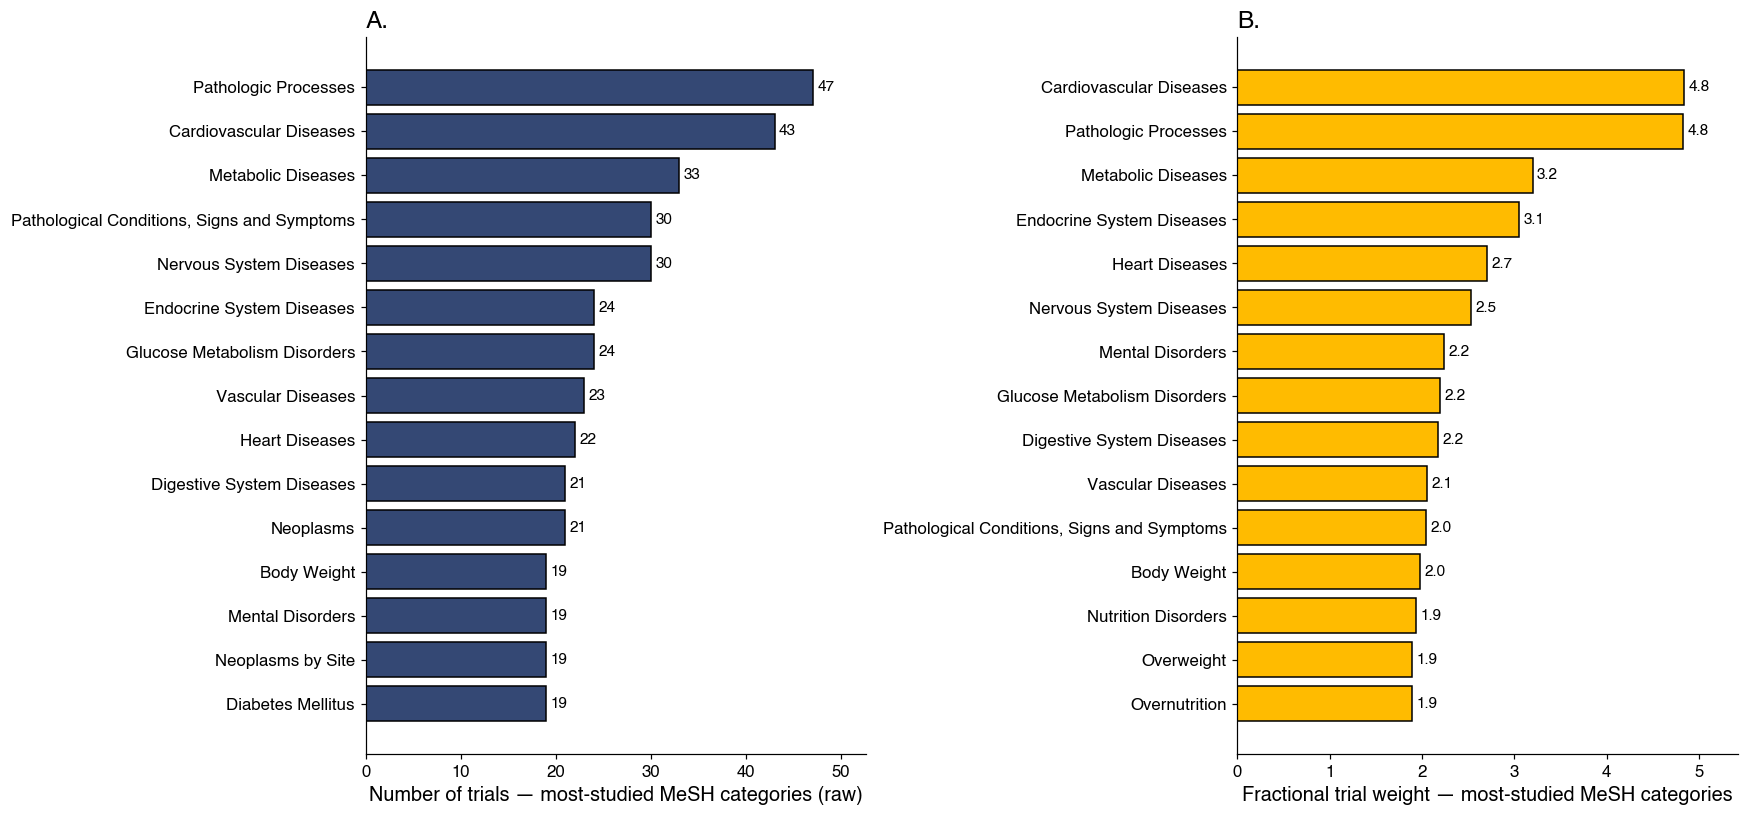

In [14]:
mesh_raw  = count_items(df_ct["mesh_terms"], top=15)
mesh_frac = count_items_frac(df_ct["mesh_terms"]).head(15)
n_mesh = int(df_ct["mesh_terms"].apply(lambda x: len(parse_listcol(x)) > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_hbar(mesh_raw, "a.",
          "Number of trials — most-studied MeSH categories (raw)", color=STYLE["c_primary"],  ax=axes[0])
plot_hbar(mesh_frac, "b.",
          "Fractional trial weight — most-studied MeSH categories", color=STYLE["c_gold"], fmt="{:.1f}", ax=axes[1])
#fig.suptitle(f"Diseases studied in UKB-linked clinical trials "
#             f"({n_mesh}/{len(df_ct)} trials MeSH-coded)",
#             fontsize=STYLE["title_fs"] + 1, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94]); savefig(fig, "ct_diseases_mesh")
plt.show()

### 3.2 Diseases (free-text `conditions`) — normalised word cloud

`conditions` is sponsor free text, so the same disease appears under many surface forms
(*Type 2 diabetes / Diabetes mellitus / Diabetes*; *Atrial fibrillation / Atrial
fibrillation (AF)*). Before the cloud we **normalise** each phrase — lowercase, drop
parenthetical acronyms, then a small synonym map merges the obvious families — and count
**fractionally** (each trial spreads weight 1 across its distinct normalised conditions).
The synonym map is deliberately conservative and easy to extend.

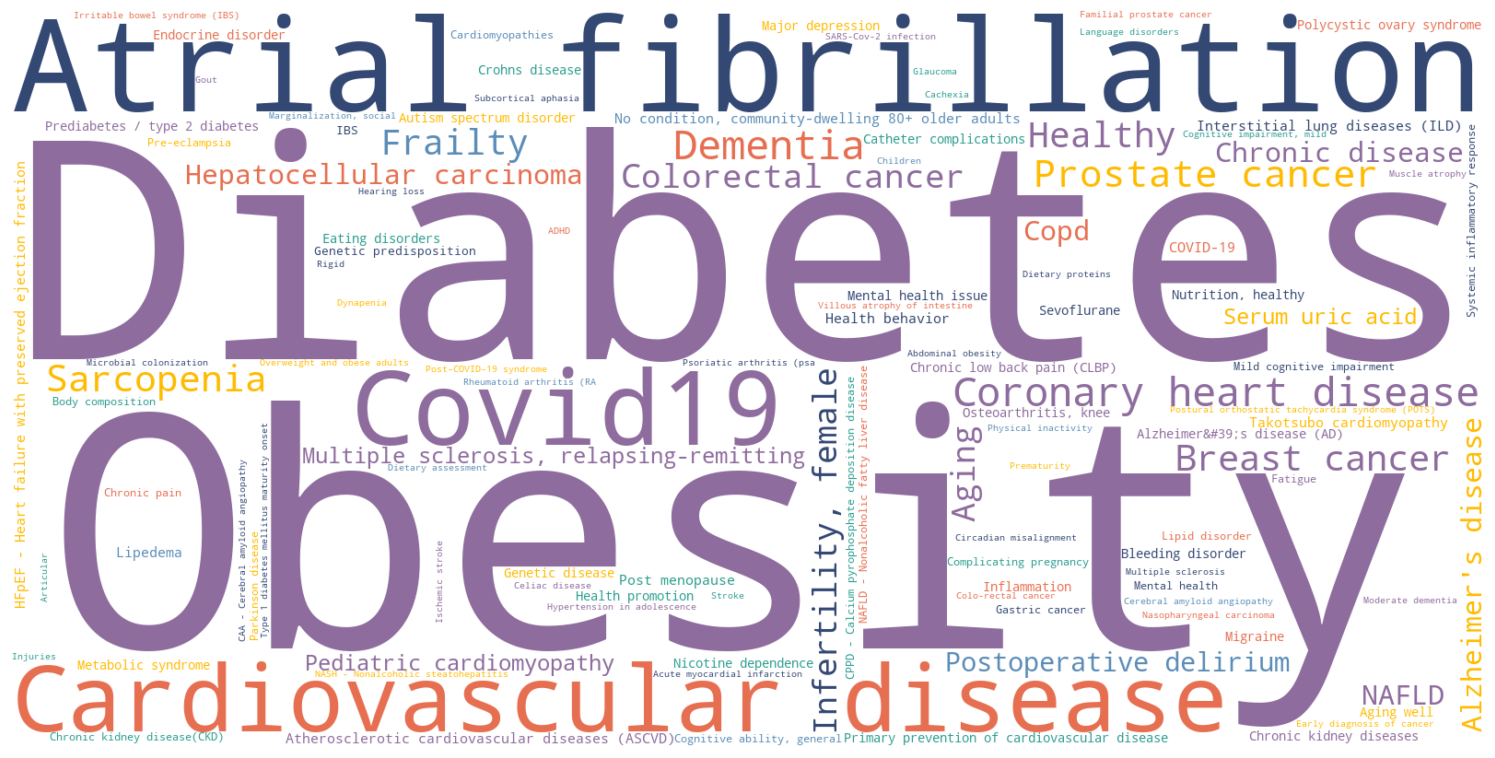

Top normalised conditions: Obesity (8.5), Diabetes (8.0), Atrial fibrillation (5.9), Covid19 (3.5), Cardiovascular disease (3.4), Coronary heart disease (2.1), Dementia (2.1), Prostate cancer (1.7), Sarcopenia (1.6), Breast cancer (1.6), Healthy (1.5), Frailty (1.5)


In [15]:
import html

# Conservative synonym map. KEYS are in the *normalised* form norm_key() produces
# (lowercase, no parentheticals, commas/&/slashes -> spaces, collapsed) so lookups hit.
COND_SYNONYMS = {}
def _syn(canonical, *variants):
    for v in variants:
        COND_SYNONYMS[v] = canonical

_syn("Diabetes", "diabetes", "type 2 diabetes", "type 1 diabetes", "diabetes mellitus",
     "diabetes mellitus type 2", "type 2 diabetes mellitus", "diabetes mellitus type 1",
     "type 1 diabetes mellitus", "t2dm", "niddm", "diabetes autoimmune")
_syn("Obesity", "obesity", "obesity morbid", "morbid obesity", "obesity adolescent",
     "adolescent obesity", "obesity childhood", "childhood obesity", "overweight",
     "overweight and obesity", "obesity overweight", "overweight childhood",
     "adolescent overweight")
_syn("Cardiovascular disease", "cardiovascular disease", "cardiovascular diseases",
     "cardiovascular risk", "cardiovascular diseases risk")
_syn("Coronary heart disease", "coronary heart disease", "coronary artery disease")
_syn("Atrial fibrillation", "atrial fibrillation")
_syn("Alzheimer's disease", "alzheimer's disease", "alzheimer disease", "alzheimers disease")
_CANON = set(COND_SYNONYMS.values())


def norm_key(name):
    """Normalise a free-text condition to a merge key (unescape HTML, lowercase, drop
    '(...)', turn commas/&/slashes into spaces, collapse), then apply the synonym map."""
    s = html.unescape(str(name)).lower()
    s = re.sub(r"\(.*?\)", " ", s)          # drop parenthetical acronyms e.g. (AF)
    s = re.sub(r"[.,;/&]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return COND_SYNONYMS.get(s, s)


def normalized_condition_freq(series):
    """Fractional frequency of NORMALISED conditions. Each trial spreads weight 1 across
    its distinct merge-keys; the display label is the synonym canonical (if any) else the
    most common original surface form for that key."""
    kw = defaultdict(float)
    surf = defaultdict(Counter)
    for cell in series:
        keys = set()
        for it in item_names(cell):
            k = norm_key(it)
            keys.add(k); surf[k][html.unescape(it)] += 1
        if not keys:
            continue
        f = 1.0 / len(keys)
        for k in keys:
            kw[k] += f
    out = defaultdict(float)
    for k, w in kw.items():
        label = k if k in _CANON else surf[k].most_common(1)[0][0]
        out[label] += w
    return pd.Series(out, dtype="float64").sort_values(ascending=False)


cond_freq = normalized_condition_freq(df_ct["conditions"])
plot_wordcloud(cond_freq,"", #"Conditions studied (free-text, normalised + fractional)",
               name="ct_conditions_wordcloud")
plt.show()
print("Top normalised conditions:",
      ", ".join(f"{k} ({v:.1f})" for k, v in cond_freq.head(12).items()))

### 3.3 Mapping disease names to ICD-10 chapters

The data carries **no ICD field**, but the **names can be mapped** to ICD — e.g. *Diabetes*
→ **E10–E14** (chapter *IV Endocrine, nutritional & metabolic*), *Atrial fibrillation* →
**I48** (chapter *IX Circulatory*). A full term-level MeSH→ICD-10 crosswalk needs the
licence-gated UMLS Metathesaurus, but a **chapter-level** grouping is both reliable and more
useful for a headline: it collapses the long MeSH list into the ~a dozen ICD-10 body-system
chapters. Below we apply a transparent **keyword → ICD-10 chapter** map to each trial's MeSH
terms (first match wins; MeSH qualifiers like *Pathologic Processes* stay *Unmapped*), then
count trials per chapter (a trial can span several).

> This is a **curated approximation**, not an authoritative UMLS mapping — the `ICD_CHAPTERS`
> rules are in the cell and easy to inspect / extend.

139/168 trials mapped to >=1 ICD-10 chapter; dot area ∝ trials.


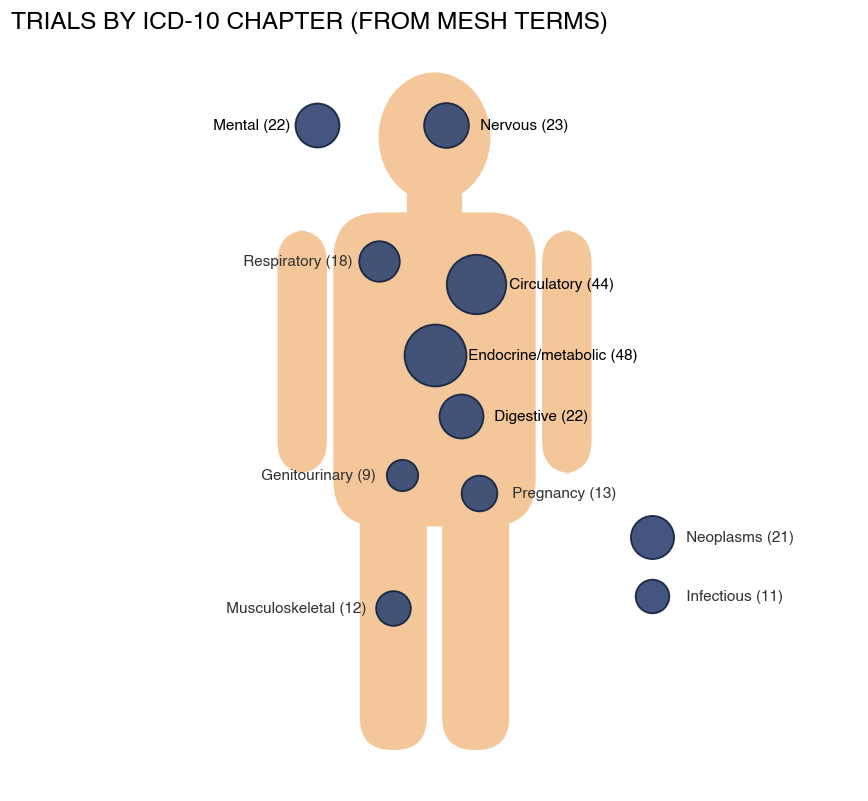

,n_trials
"IV Endocrine, nutritional & metabolic (E00–E90)",48
IX Circulatory system (I00–I99),44
VI Nervous system (G00–G99),23
XI Digestive system (K00–K93),22
V Mental & behavioural (F00–F99),22
II Neoplasms (C00–D48),21
X Respiratory system (J00–J99),18
XV Pregnancy & childbirth (O00–O99),13
XIII Musculoskeletal (M00–M99),12
I Infectious & parasitic (A00–B99),11


In [16]:
# Keyword -> ICD-10 chapter (checked in order; first hit wins). Circulatory is listed before
# nervous so 'stroke' (I60-I69) lands in circulatory, etc.
ICD_CHAPTERS = [
    ("II  Neoplasms (C00–D48)",
     ["neoplasm", "cancer", "carcinoma", "tumor", "tumour", "lymphoma", "leukemia",
      "leukaemia", "melanoma", "sarcoma", "malignan", "adenoma"]),
    ("IV  Endocrine, nutritional & metabolic (E00–E90)",
     ["diabet", "obes", "overweight", "metaboli", "nutrition", "lipid", "cholesterol",
      "thyroid", "glucose", "insulin", "hyperglyc", "dyslipid", "hyperlipid"]),
    ("IX  Circulatory system (I00–I99)",
     ["cardiovascular", "cardiac", "heart", "coronary", "atrial fibrillation", "arrhythmia",
      "myocard", "vascular", "hypertension", "atheroscler", "thrombo", "ischemi", "ischaemi",
      "stroke", "aneurysm", "angina", "cardiomyopath", "embolism"]),
    ("V   Mental & behavioural (F00–F99)",
     ["depress", "anxiety", "psychiatr", "psychosis", "schizophren", "bipolar", "mood",
      "mental disorder", "substance", "addiction", "alcohol"]),
    ("VI  Nervous system (G00–G99)",
     ["alzheimer", "dementia", "parkinson", "epilep", "migraine", "sclerosis",
      "neurodegener", "cognitive", "neuropath"]),
    ("X   Respiratory system (J00–J99)",
     ["asthma", "copd", "respiratory", "pulmonary disease", "lung disease", "pneumon", "bronch"]),
    ("XI  Digestive system (K00–K93)",
     ["liver", "hepat", "nafld", "gastro", "digest", "bowel", "crohn", "colitis",
      "pancrea", "cirrhosis", "fatty liver", "steato"]),
    ("XIII Musculoskeletal (M00–M99)",
     ["arthr", "osteo", "musculoskeletal", "sarcopenia", "bone", "joint", "rheumat"]),
    ("XIV Genitourinary (N00–N99)",
     ["kidney", "renal", "urinary", "prostat", "nephro", "bladder"]),
    ("XV  Pregnancy & childbirth (O00–O99)",
     ["pregnan", "eclampsia", "obstetric", "gestational"]),
    ("I   Infectious & parasitic (A00–B99)",
     ["infect", "covid", "viral", "bacteri", "sepsis", "hiv"]),
]


def _norm_icd_term(term):
    """Lowercase a term for keyword matching, defusing substring traps.

    'Non-alcoholic Fatty Liver Disease' contains the substring 'alcohol', and the Mental &
    behavioural rules are tested BEFORE Digestive — so every NAFLD trial was landing in
    F00-F99. Stripping the negation makes it match 'liver' -> XI Digestive, which is right
    (NAFLD is K76.0).
    """
    return term.lower().replace("non-alcoholic", " ").replace("nonalcoholic", " ")


def map_icd_chapter(term):
    """First-matching ICD-10 chapter for a disease term, else None (unmapped)."""
    t = _norm_icd_term(term)
    for chapter, kws in ICD_CHAPTERS:
        if any(k in t for k in kws):
            return chapter
    return None


def trials_by_icd_chapter(df, col="mesh_terms"):
    """Trials per ICD-10 chapter (a trial counted once per chapter it touches)."""
    c = Counter()
    n_mapped = 0
    for cell in df[col]:
        chapters = {map_icd_chapter(t) for t in item_names(cell)}
        chapters.discard(None)
        if chapters:
            n_mapped += 1
        c.update(chapters)
    return pd.Series(c, dtype="int64").sort_values(ascending=False), n_mapped


# ---- Human "body map": place each ICD-10 chapter on a body silhouette --------
BODY_COLOR = "#F4C79B"
# full-chapter -> (x, y, short label) anatomical positions; systemic chapters
# (neoplasms, infectious) sit just off the body on the right, like the reference figure.
ICD_BODY_POS = {
    "VI  Nervous system (G00–G99)":                     (5.20, 12, "Nervous"),
    "V   Mental & behavioural (F00–F99)":               (3, 12.0, "Mental"),
    "X   Respiratory system (J00–J99)":                 (4.05, 9.70, "Respiratory"),
    "IX  Circulatory system (I00–I99)":                 (5.70, 9.30, "Circulatory"),
    "IV  Endocrine, nutritional & metabolic (E00–E90)": (5.00, 8.10, "Endocrine/metabolic"),
    "XI  Digestive system (K00–K93)":                   (5.45, 7.05, "Digestive"),
    "XIV Genitourinary (N00–N99)":                      (4.45, 6.05, "Genitourinary"),
    "XV  Pregnancy & childbirth (O00–O99)":             (5.75, 5.75, "Pregnancy"),
    "XIII Musculoskeletal (M00–M99)":                   (4.3, 3.80, "Musculoskeletal"),
    "II  Neoplasms (C00–D48)":                          (8.70, 5, "Neoplasms"),
    "I   Infectious & parasitic (A00–B99)":             (8.70, 4, "Infectious"),
}


def _draw_body(ax, color=BODY_COLOR):
    """Draw a simple pale humanoid silhouette (head, torso, arms, legs)."""
    from matplotlib.patches import FancyBboxPatch, Ellipse
    rr = lambda xy, w, h, s=0.55: FancyBboxPatch(
        xy, w, h, boxstyle=f"round,pad=0.02,rounding_size={s}", fc=color, ec="none")
    for x in (3.75, 5.15):                       # legs (shortened proportions)
        ax.add_patch(rr((x, 2.1), 1.1, 6))
    for x in (2.35, 6.85):                        # arms
        ax.add_patch(rr((x, 6.8), 0.8, 4.1))
    ax.add_patch(rr((3.3, 5.9), 3.4, 5.3, 0.8))  # torso
    ax.add_patch(rr((4.55, 10.9), 0.9, 1.0, 0.2))  # neck
    ax.add_patch(Ellipse((5.0, 12.5), 1.9, 2.2, fc=color, ec="none"))  # head


def plot_icd_bodymap(counts, title, style=STYLE, n_annotate=5, ax=None, name="ct_icd_bodymap"):
    """Body-map of trials per ICD-10 chapter: each chapter is a dot at its anatomical
    position, area proportional to the trial count; the top-`n_annotate` are bold."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 9))
    else:
        fig = ax.figure
    _draw_body(ax)
    mx = max(counts.max(), 1)
    top = set(counts.sort_values(ascending=False).head(n_annotate).index)
    for chap, v in counts.items():
        if chap not in ICD_BODY_POS:
            continue
        x, y, short = ICD_BODY_POS[chap]
        ax.scatter([x], [y+0.7], s=140 + (v / mx) * 1500, c=style["c_primary"],
                   edgecolors="#12233F", linewidths=1.2, zorder=5, alpha=0.92)
        if x < 4.7:
            ha, dx = "right", -0.45
        elif x > 7:
            ha, dx = "left", 0.5
        else:
            ha, dx = "left", 0.5
        ax.annotate(f" {short} ({int(v)})", (x, y+0.7), (x + dx, y+0.7), textcoords="data",
                    ha=ha, va="center", fontsize=style["annot_fs"],
                    fontweight="bold" if chap in top else "normal",
                    color="black" if chap in top else "#333333", zorder=6)
    ax.set_xlim(-2.2, 12.2); ax.set_ylim(1.4, 14.2)
    ax.set_aspect("equal"); ax.axis("off")
    set_title(ax, title, fontsize=style["title_fs"], fontweight="bold")
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


icd_counts, n_icd = trials_by_icd_chapter(df_ct)
plot_icd_bodymap(icd_counts, "Trials by ICD-10 chapter (from MeSH terms)",
                 name="ct_icd_bodymap")
print(f"{n_icd}/{len(df_ct)} trials mapped to >=1 ICD-10 chapter; dot area ∝ trials.")
plt.show()
display(icd_counts.rename("n_trials").to_frame())

### 3.4 Research areas & diseases (RCDC categories)

`category_rcdc` is Dimensions' **RCDC** tagging — NIH's *Research, Condition, and Disease
Categorisation* — and it is **0% missing** (every trial carries a median of 9 tags, 157
distinct tags in total), which makes it a stronger disease axis than `mesh_terms` (8%
missing).

The catch is that RCDC is a **mixed vocabulary**. Next to genuine conditions
(*Cardiovascular*, *Obesity*, *Brain Disorders*) it carries cross-cutting research areas
(*Clinical Research*, *Prevention*), methods (*Biomedical Imaging*), populations (*Women's
Health*) and funding-portfolio labels (*Clinical Trials and Supportive Activities*). Those
sit at the very top of a raw ranking and say nothing about *what disease* a trial studies,
so we keep **two views**:

* **all tags** — what the RCDC portfolio of these trials looks like as tagged;
* **disease-only** — the same counts after a `RCDC_STOP` list drops the cross-cutting tags
  (the list is in the cell below, explicit and easy to edit).

Both are shown **raw and fractional**, exactly as in §3.1 — fractional spreads a weight of 1
across each trial's tags, so a trial carrying 15 RCDC tags doesn't outweigh one carrying 3.

Trials with >=1 RCDC tag           : 168/168 (156 distinct tags, median 9 tags per trial)
Trials with >=1 *disease* RCDC tag  : 159/168 (97 distinct tags) — 56 cross-cutting tags stop-listed


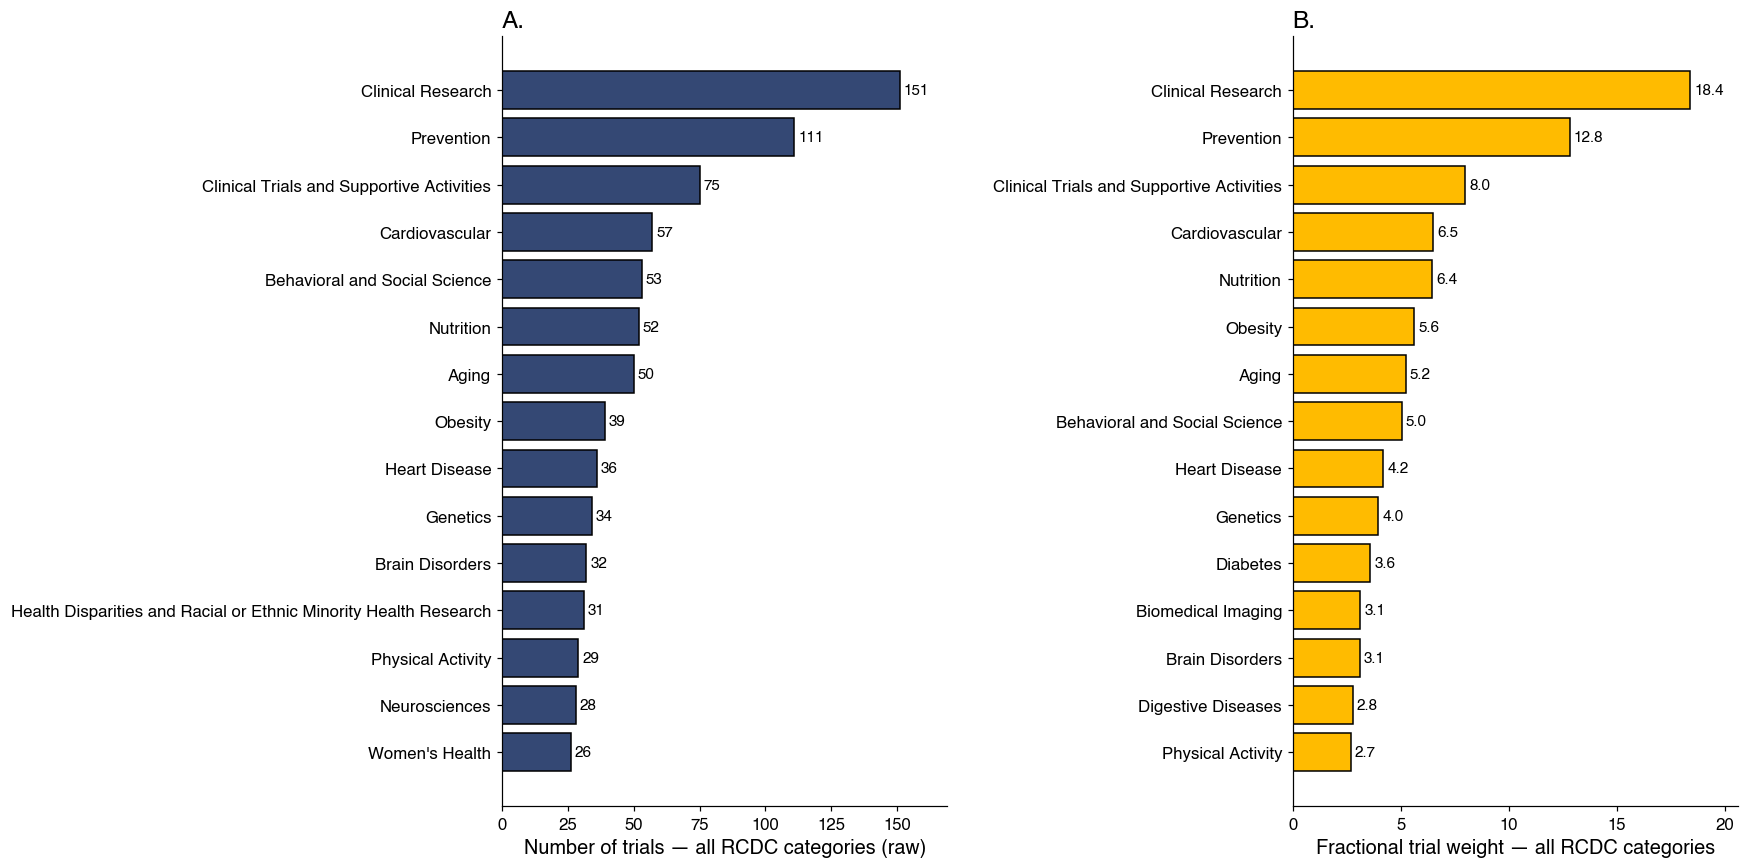

In [17]:
# =============================================================================
# RCDC (NIH Research, Condition & Disease Categorisation) — tags, stop-list, bars
# =============================================================================
# RCDC mixes diseases with research areas / methods / populations / portfolio labels.
# The stop-list below marks the NON-disease tags; everything else is treated as a condition.
# It is deliberately explicit (not a heuristic) so it can be inspected and extended.
RCDC_STOP = {
    # research-activity / portfolio labels
    "Clinical Research", "Clinical Trials and Supportive Activities", "Prevention",
    "Comparative Effectiveness Research", "Cost Effectiveness Research",
    "Dissemination and Implementation Research", "Patient Safety", "Health Services",
    "Primary Health Care", "Emergency Care", "Telehealth", "Rehabilitation",
    "Physical Rehabilitation", "Precision Medicine", "Orphan Drug", "Transplantation",
    "Organ Transplantation", "Regenerative Medicine",
    # methods / platforms / technology
    "Biomedical Imaging", "Bioengineering", "Biotechnology", "Biodefense",
    "Machine Learning and Artificial Intelligence", "Data Science", "Assistive Technology",
    "Networking and Information Technology R&D (NITRD)",
    # biology / mechanism — not a disease axis
    "Genetics", "Human Genome", "Genetic Testing", "Microbiome", "Neurosciences",
    "Hematology", "Endocannabinoid System Research", "Cannabinoid Research",
    # behavioural / lifestyle / exposure research areas
    "Behavioral and Social Science", "Basic Behavioral and Social Science",
    "Physical Activity", "Dietary Supplements", "Complementary and Integrative Health",
    "Sleep Research", "Breastfeeding, Lactation and Breast Milk", "Contraception/Reproduction",
    # populations / equity / life-stage framings
    "Aging", "Women's Health", "Maternal Health", "Minority Health", "Health Disparities",
    "Health Disparities and Racial or Ethnic Minority Health Research",
    "Social Determinants of Health", "Pediatric Research Initiative", "Rural Health",
    "Rare Diseases", "Infant Mortality", "Vaccine Related", "Immunization",
    "Pain Research",   # the research *field*; the conditions are 'Chronic Pain' / 'Back Pain'
}
RCDC_STOP_PREFIX = ("Stem Cell Research",)   # 5 near-identical variants


def is_disease_rcdc(name):
    """True if an RCDC tag names a condition rather than a research area / method / population."""
    return name not in RCDC_STOP and not name.startswith(RCDC_STOP_PREFIX)


# two list columns: every tag, and the disease-only subset
df_ct["rcdc_all"] = df_ct["category_rcdc"].apply(item_names)
df_ct["rcdc_disease"] = df_ct["rcdc_all"].apply(lambda ts: [t for t in ts if is_disease_rcdc(t)])

n_rcdc     = int((df_ct["rcdc_all"].str.len() > 0).sum())
n_rcdc_dis = int((df_ct["rcdc_disease"].str.len() > 0).sum())
print(f"Trials with >=1 RCDC tag           : {n_rcdc}/{len(df_ct)} "
      f"({count_items(df_ct['rcdc_all']).size} distinct tags, "
      f"median {df_ct['rcdc_all'].str.len().median():.0f} tags per trial)")
print(f"Trials with >=1 *disease* RCDC tag  : {n_rcdc_dis}/{len(df_ct)} "
      f"({count_items(df_ct['rcdc_disease']).size} distinct tags) — "
      f"{len(RCDC_STOP)} cross-cutting tags stop-listed")

# ---- (i) ALL tags — raw vs fractional ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_hbar(count_items(df_ct["rcdc_all"], top=15), "a.",
          "Number of trials — all RCDC categories (raw)", color=STYLE["c_primary"], ax=axes[0])
plot_hbar(count_items_frac(df_ct["rcdc_all"]).head(15), "b.",
          "Fractional trial weight — all RCDC categories", color=STYLE["c_gold"], fmt="{:.1f}", ax=axes[1])
fig.tight_layout(w_pad=3); savefig(fig, "ct_rcdc_all")
plt.show()

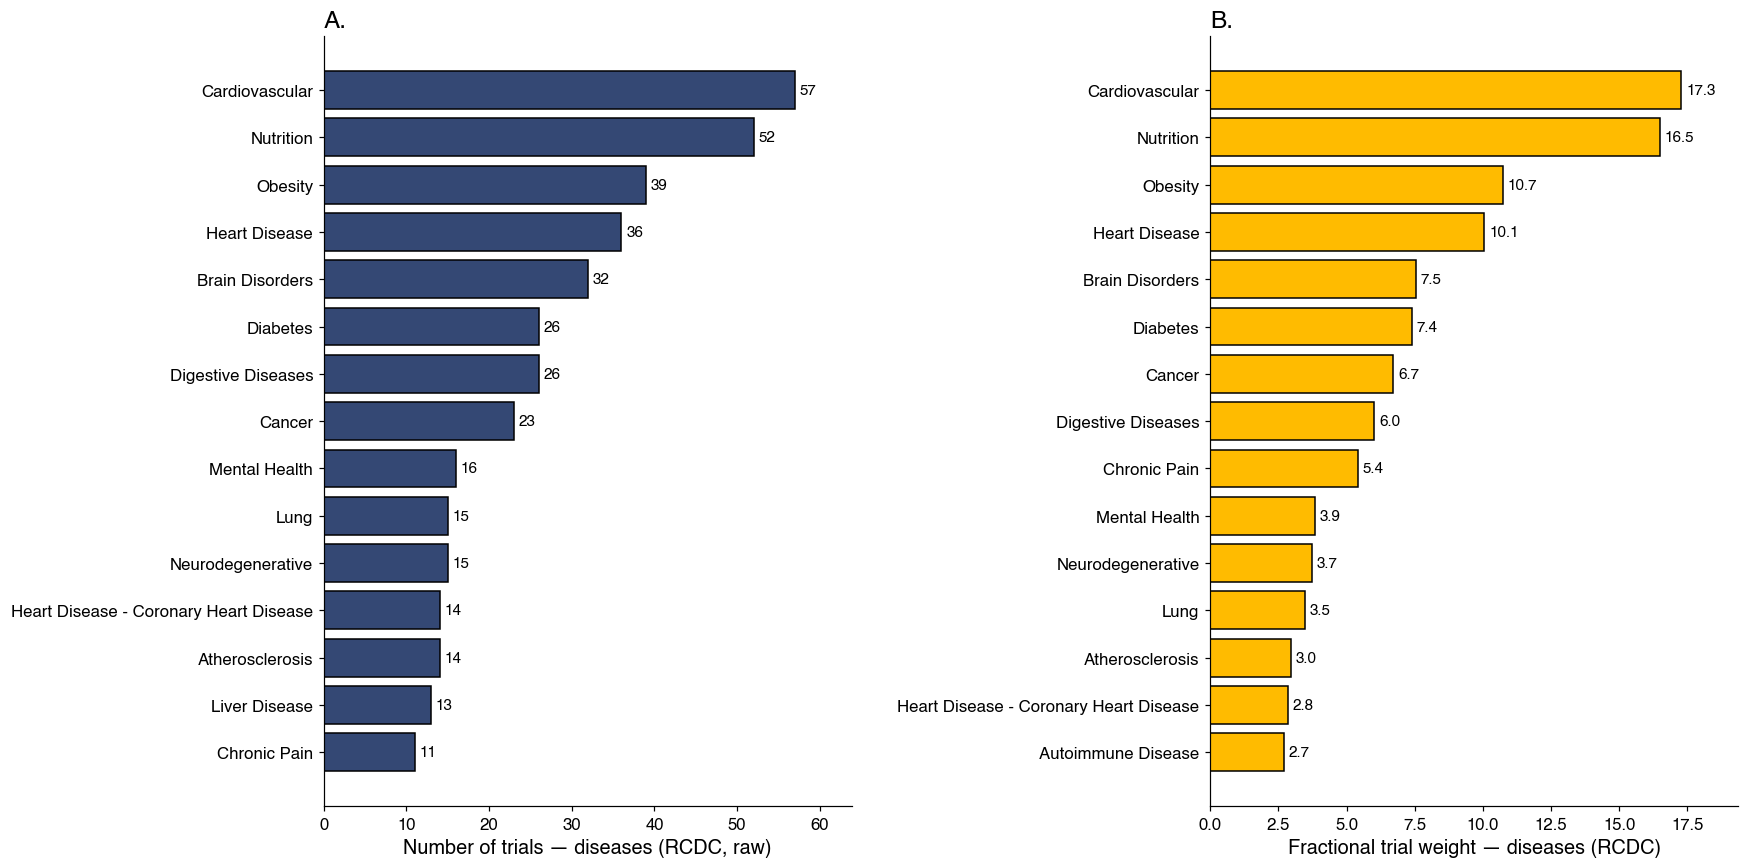

Stop-listed (cross-cutting) RCDC tags actually present, by trials carrying them:


,n_trials
Clinical Research,151
Prevention,111
Clinical Trials and Supportive Activities,75
Behavioral and Social Science,53
Aging,50
Genetics,34
Health Disparities and Racial or Ethnic Minority Health Research,31
Physical Activity,29
Neurosciences,28
Women's Health,26


In [18]:
# ---- (ii) DISEASE-ONLY tags — raw vs fractional ------------------------------
# The same two counts with the cross-cutting tags removed: this is the RCDC answer to
# "what diseases do the UKB-citing trials study?", directly comparable to the MeSH bars (§3.1).
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_hbar(count_items(df_ct["rcdc_disease"], top=15), "a.",
          "Number of trials — diseases (RCDC, raw)", color=STYLE["c_primary"], ax=axes[0])
plot_hbar(count_items_frac(df_ct["rcdc_disease"]).head(15), "b.",
          "Fractional trial weight — diseases (RCDC)", color=STYLE["c_gold"], fmt="{:.1f}", ax=axes[1])
fig.tight_layout(w_pad=3); savefig(fig, "ct_rcdc_disease")
plt.show()

# the dropped tags, for the record — check nothing disease-like was thrown away
dropped = count_items(df_ct["rcdc_all"].apply(lambda ts: [t for t in ts if not is_disease_rcdc(t)]))
print("Stop-listed (cross-cutting) RCDC tags actually present, by trials carrying them:")
display(dropped.head(15).rename("n_trials").to_frame())

#### 3.4.1 RCDC → ICD-10 chapters

The same **keyword → ICD-10 chapter** idea as §3.3, applied to the RCDC disease tags. Two
changes are needed because RCDC phrases its conditions differently from MeSH (*Brain
Disorders*, *Lung*, *Urologic Diseases*):

* the §3.3 `ICD_CHAPTERS` rules are **extended, not replaced** — RCDC's vocabulary is folded
  into the *same chapter labels*, so a term MeSH would have matched still lands in the same
  chapter and the two mappings stay directly comparable;
* RCDC reaches **six chapters MeSH never did** (blood/immune, eye, skin, perinatal, injury,
  symptoms), appended after the original rules so the first-hit-wins order is preserved.

With those rules **every** disease RCDC tag maps to a chapter, so the RCDC route covers more
trials than the MeSH route (`mesh_terms` is 8% missing and its qualifiers often don't name a
disease). Panel **b** puts the two side by side. No body map here — the chapter bar plus the
MeSH/RCDC comparison is what the write-up needs.

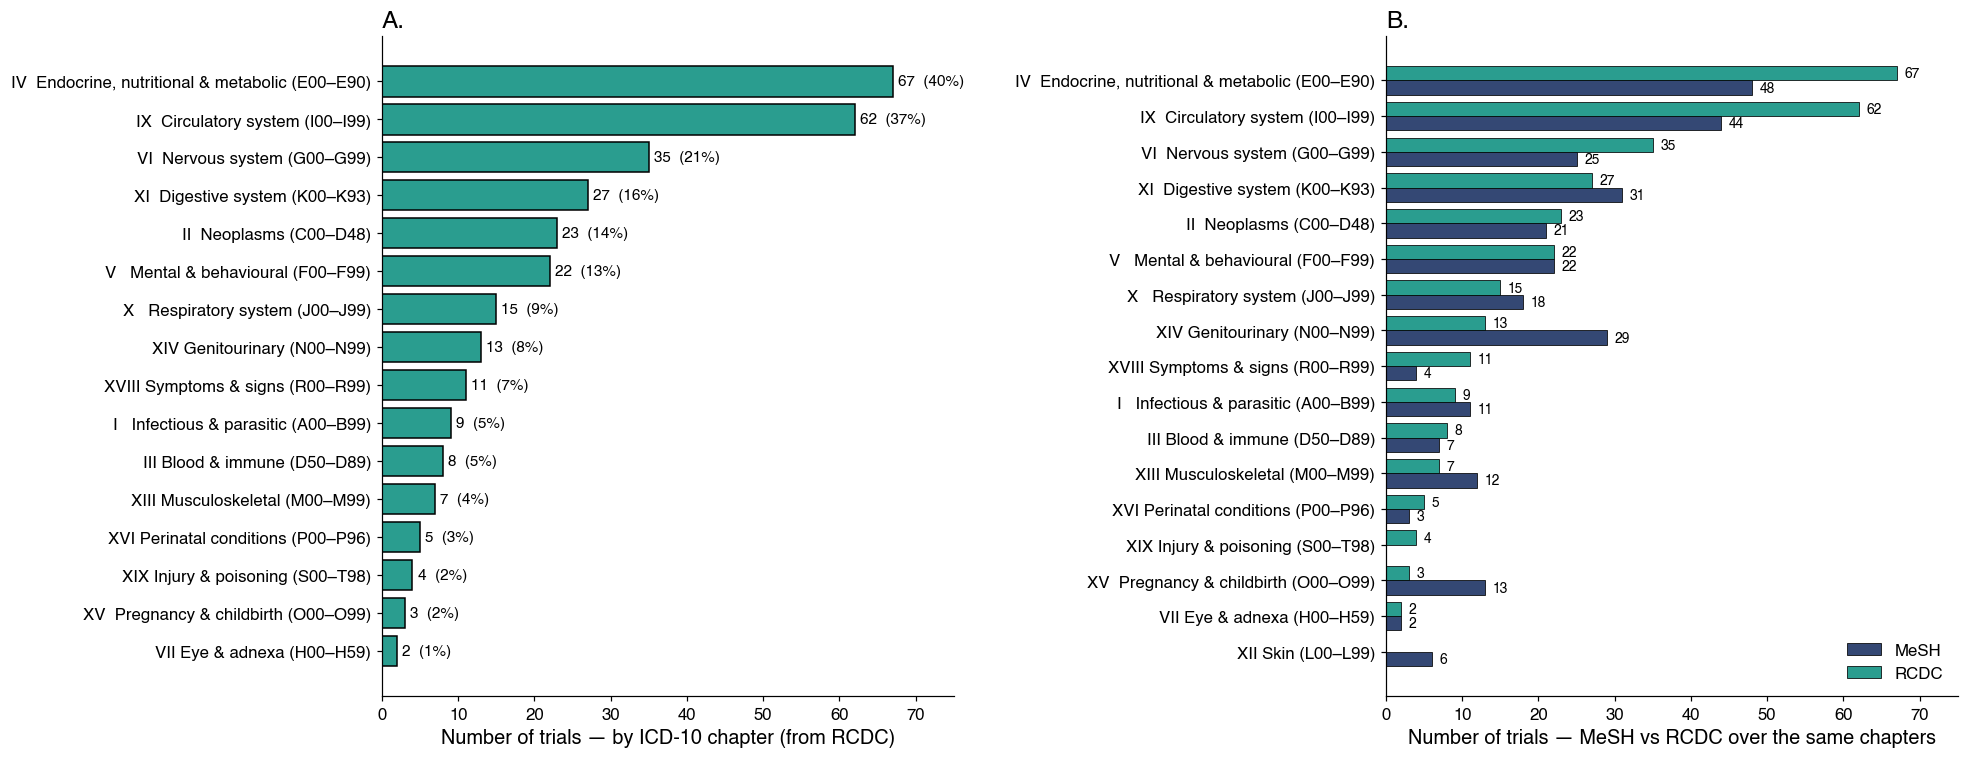

RCDC : 159/168 trials mapped to >=1 ICD-10 chapter (16 chapters touched)
MeSH : 144/168 trials mapped to >=1 ICD-10 chapter (16 chapters touched)

Unmapped disease RCDC tags: 2


,n_trials
Estrogen,1
Lymphatic Research,1


,MeSH,RCDC
"IV Endocrine, nutritional & metabolic (E00–E90)",48,67
IX Circulatory system (I00–I99),44,62
VI Nervous system (G00–G99),25,35
XI Digestive system (K00–K93),31,27
II Neoplasms (C00–D48),21,23
V Mental & behavioural (F00–F99),22,22
X Respiratory system (J00–J99),18,15
XIV Genitourinary (N00–N99),29,13
XVIII Symptoms & signs (R00–R99),4,11
I Infectious & parasitic (A00–B99),11,9


In [19]:
# =============================================================================
# RCDC -> ICD-10 chapters — extend the §3.3 rules with RCDC's vocabulary
# =============================================================================
# Keywords added to the EXISTING chapters (labels identical to §3.3, so counts are comparable).
RCDC_ICD_EXTRA = {
    "II  Neoplasms (C00–D48)": ["oncolog"],
    "V   Mental & behavioural (F00–F99)": [
        "mental health", "mental illness", "autism", "attention deficit", "adhd",
        "eating disorder", "anorexia", "suicide", "tobacco", "opioid", "drug abuse",
        "intellectual and developmental"],
    "VI  Nervous system (G00–G99)": ["brain disorder", "sleep", "aphasia", "headache"],
    "X   Respiratory system (J00–J99)": ["lung", "influenza"],
    "XI  Digestive system (K00–K93)": ["celiac", "coeliac", "dental", "oral"],
    "XIV Genitourinary (N00–N99)": ["urologic", "infertility", "reproduction"],
    "XV  Pregnancy & childbirth (O00–O99)": ["maternal", "lactation", "breastfeeding"],
    "I   Infectious & parasitic (A00–B99)": ["coronavirus", "vaccine", "immunization"],
}
# Chapters RCDC reaches that the MeSH map never needed — appended, so the §3.3 order still wins.
ICD_CHAPTERS_NEW = [
    ("III Blood & immune (D50–D89)",       ["autoimmune", "anemia", "anaemia", "immune"]),
    ("VII Eye & adnexa (H00–H59)",         ["eye", "vision", "macular", "retin", "glaucoma",
                                            "cataract"]),
    ("XII Skin (L00–L99)",                 ["psoriasis", "skin", "dermat", "eczema"]),
    ("XVI Perinatal conditions (P00–P96)", ["perinatal", "neonat", "embryonic and fetal"]),
    ("XIX Injury & poisoning (S00–T98)",   ["injury", "accident", "adverse effects", "poisoning"]),
    ("XVIII Symptoms & signs (R00–R99)",   ["pain"]),
]


def merge_icd_rules(base=ICD_CHAPTERS, extra=RCDC_ICD_EXTRA, new=ICD_CHAPTERS_NEW):
    """§3.3 chapters in §3.3 order with the RCDC keywords folded in, then the RCDC-only chapters."""
    return [(chap, kws + list(extra.get(chap, []))) for chap, kws in base] + list(new)


ICD_CHAPTERS_RCDC = merge_icd_rules()


def map_icd_chapter_rules(term, rules):
    """First-matching ICD-10 chapter under an explicit rule list, else None (unmapped)."""
    t = _norm_icd_term(term)      # see §3.3: defuses 'non-alcoholic' -> 'alcohol' -> Mental
    for chapter, kws in rules:
        if any(k in t for k in kws):
            return chapter
    return None


def icd_chapter_counts(series, rules=ICD_CHAPTERS_RCDC):
    """Trials per ICD-10 chapter from a list column (a trial counted once per chapter it touches)."""
    c, n_mapped = Counter(), 0
    for cell in series:
        chapters = {map_icd_chapter_rules(t, rules) for t in item_names(cell)}
        chapters.discard(None)
        if chapters:
            n_mapped += 1
        c.update(chapters)
    return pd.Series(c, dtype="int64").sort_values(ascending=False), n_mapped


rcdc_icd, n_rcdc_icd = icd_chapter_counts(df_ct["rcdc_disease"])
mesh_icd, n_mesh_icd = icd_chapter_counts(df_ct["mesh_terms"])       # SAME rules, so the
#                                                                    # comparison is like-for-like:
#                                                                    # only the vocabulary differs

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_hbar(rcdc_icd, "a.", "Number of trials — by ICD-10 chapter (from RCDC)",
          color=STYLE["c_green"], pct_of=len(df_ct), ax=axes[0])

# (b) the two vocabularies over the same chapters
comp = (pd.concat([mesh_icd.rename("MeSH"), rcdc_icd.rename("RCDC")], axis=1)
          .fillna(0).astype(int).sort_values("RCDC"))
ax = axes[1]
y, h = np.arange(len(comp)), 0.4
for i, (src, col) in enumerate([("MeSH", STYLE["c_primary"]), ("RCDC", STYLE["c_green"])]):
    bars = ax.barh(y + (i - 0.5) * h, comp[src].values, height=h, label=src,
                   color=col, edgecolor=STYLE["edgecolor"], linewidth=0.5)
    for b, v in zip(bars, comp[src].values):
        if v:
            ax.text(v + 1, b.get_y() + b.get_height() / 2, str(int(v)),
                    va="center", fontsize=STYLE["annot_fs"] - 1)
ax.set_yticks(y); ax.set_yticklabels(comp.index)
ax.set_xlabel("Number of trials — MeSH vs RCDC over the same chapters",
              fontsize=STYLE["label_fs"])
set_title(ax, "b.", fontsize=STYLE["title_fs"], loc="left", fontweight="bold")
ax.legend(fontsize=STYLE["legend_fs"], frameon=False); ax.margins(x=0.12)
fig.tight_layout(w_pad=4); savefig(fig, "ct_rcdc_icd")
plt.show()

print(f"RCDC : {n_rcdc_icd}/{len(df_ct)} trials mapped to >=1 ICD-10 chapter "
      f"({len(rcdc_icd)} chapters touched)")
print(f"MeSH : {n_mesh_icd}/{len(df_ct)} trials mapped to >=1 ICD-10 chapter "
      f"({len(mesh_icd)} chapters touched)")

# audit — disease RCDC tags the rules leave unmapped (empty = full coverage)
unmapped = Counter()
for ts in df_ct["rcdc_disease"]:
    for t in set(ts):
        if map_icd_chapter_rules(t, ICD_CHAPTERS_RCDC) is None:
            unmapped[t] += 1
print(f"\nUnmapped disease RCDC tags: {len(unmapped)}")
if unmapped:
    display(pd.Series(unmapped, dtype="int64").sort_values(ascending=False)
              .head(20).rename("n_trials").to_frame())
display(comp.sort_values("RCDC", ascending=False))

### 3.5 MeSH, rebuilt from the registry — condition-**leaf** terms

The §3.1 ranking has a problem worth spelling out, because it changes what that figure means.

**`mesh_terms` is not indexer-assigned MeSH.** ClinicalTrials.gov *derives* it from the
trial's free-text `conditions` / `interventions` and returns it in **three separate buckets**,
which Dimensions flattens into one column:

| bucket | what it holds | example (NCT01315639, an Alzheimer's trial) |
|---|---|---|
| `conditionBrowseModule.meshes` | **leaf** terms actually matched — *the diseases* | Alzheimer Disease · Cognitive Dysfunction · Dementia |
| `conditionBrowseModule.ancestors` | MeSH-**tree scaffolding** | Pathologic Processes · Signs and Symptoms · Nervous System Diseases |
| `interventionBrowseModule.*` | terms from the **intervention** text | Magnetic Resonance Spectroscopy · Biomarkers |

Flattened together, the scaffolding wins: the most common "disease" in §3.1 is **Pathologic
Processes** (42 trials), followed by *Pathological Conditions, Signs and Symptoms* (35). Those
are tree ancestors, not findings.

So we **re-fetch the browse module** for every trial from the ClinicalTrials.gov REST API (v2,
no key needed) and keep the buckets apart. `src/utils/clinical_trials_fetch_ctgov.py` does the
fetch, caches the raw response to `data/non_academic/clinical_trials/ctgov_browse.pkl`, and
writes three columns back into the CSV — `mesh_leaf`, `mesh_ancestors`, `mesh_intervention` —
leaving the original `mesh_terms` untouched so the two can be compared. Re-run it after any
refresh of the trials file:

```bash
python src/utils/clinical_trials_fetch_ctgov.py    -- refresh     # cached; only new trials are fetched
```

**What the re-fetch settles about the missing 8%.** Of the 10 trials with no `mesh_terms`,
one is an **ISRCTN** record (no NLM browse module exists — structurally unfetchable) and three
come back populated, of which only **COPD** is a disease; the other two return *Health
Behavior* / *Motor Activity*. The remaining six stay empty because their `conditions` are
`Healthy`, `Aging`, `Health behavior`, `Health promotion`, `Body composition` — trials that
genuinely **study no disease**. That blank is a *finding*, not a gap: **imputing a disease onto
them (e.g. from RCDC) would fabricate one**, so we don't. Coverage is quoted on the trials that
have a disease, and the disease-free trials are reported as such.

In [20]:
#!python src/utils/clinical_trials_fetch_ctgov.py    --refresh  

In [21]:
df_ct["mesh_leaf"].isnull().sum()

np.int64(0)

trials with MeSH   — shipped (leaf+ancestors+interventions): 158/168  |  registry leaf: 151/168  |  leaf & disease: 147/168
terms per trial    — shipped median 8  |  leaf median 2   (the difference is tree scaffolding + intervention terms)
distinct terms     — shipped 637  |  leaf 213


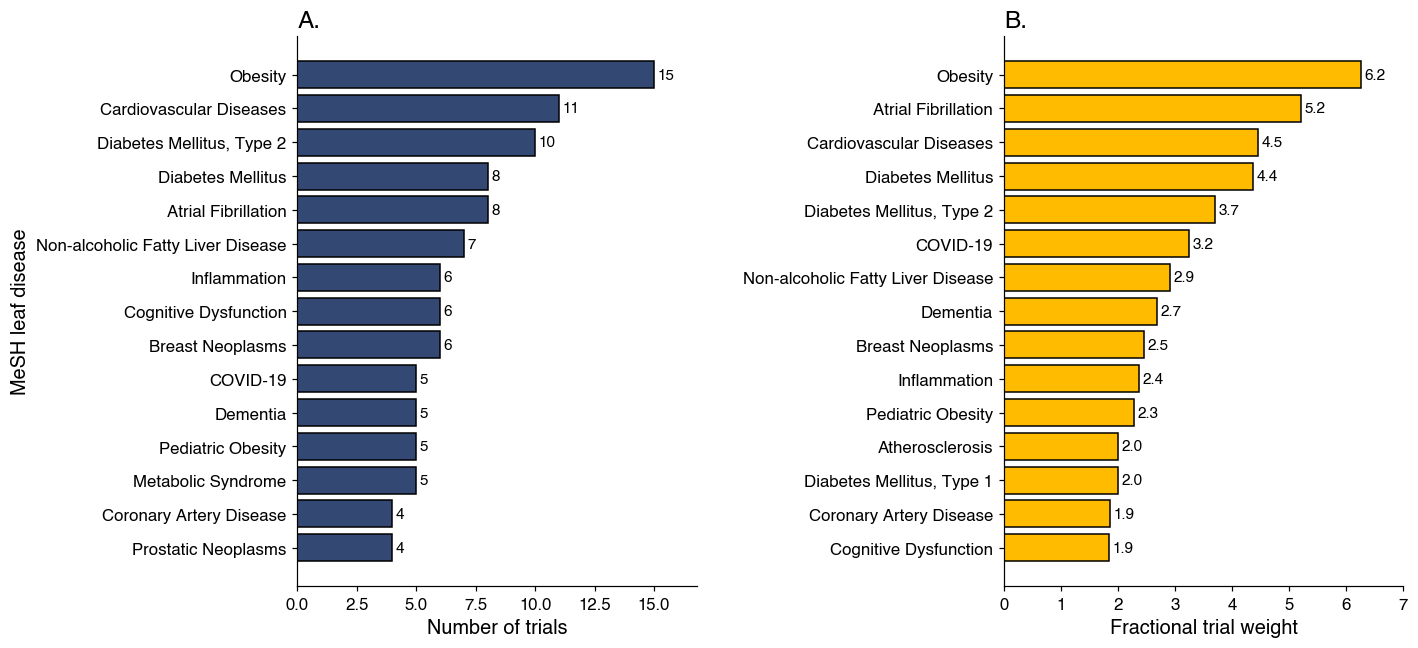

The terms §3.1 ranked that are NOT diseases (tree ancestors / intervention terms):


,index,n_trials (ancestors),index,n_trials (interventions)
0,"Pathological Conditions, Signs and Symptoms",75,Investigative Techniques,14
1,Pathologic Processes,46,Therapeutics,13
2,Nutritional and Metabolic Diseases,44,Diagnosis,10
3,Signs and Symptoms,40,Diagnostic Techniques and Procedures,10
4,Metabolic Diseases,33,Organic Chemicals,7
5,Nervous System Diseases,30,Quality of Health Care,6


In [22]:
# =============================================================================
# LEAF MeSH — the disease terms NLM actually matched (see src/utils/clinical_trials_fetch_ctgov.py)
# =============================================================================
# The three columns below are written into the CSV by that module; if they are absent, run it:
#     python src/utils/clinical_trials_fetch_ctgov.py
assert "mesh_leaf" in df_ct.columns, "run: python src/utils/clinical_trials_fetch_ctgov.py"

# A handful of leaf terms are still not diseases — CTgov maps condition text like "physical
# activity" / "healthy" onto behavioural or descriptive MeSH. Same treatment as RCDC_STOP.
MESH_LEAF_STOP = {
    "Motor Activity", "Health Behavior", "Genetic Risk Score", "Psychological Well-Being",
    "Weight Loss", "Chronic Disease", "Body Weight", "Life Style", "Exercise",
}

df_ct["mesh_leaf_disease"] = df_ct["mesh_leaf"].apply(
    lambda c: [t for t in item_names(c) if t not in MESH_LEAF_STOP])

n_ship = int(df_ct["mesh_terms"].apply(lambda x: len(parse_listcol(x)) > 0).sum())
n_leaf = int(df_ct["mesh_leaf"].apply(lambda x: len(parse_listcol(x)) > 0).sum())
n_leafd = int(df_ct["mesh_leaf_disease"].str.len().gt(0).sum())
med_ship = df_ct["mesh_terms"].apply(lambda x: len(parse_listcol(x))).median()
med_leaf = df_ct["mesh_leaf"].apply(lambda x: len(parse_listcol(x))).median()
print(f"trials with MeSH   — shipped (leaf+ancestors+interventions): {n_ship}/{len(df_ct)}"
      f"  |  registry leaf: {n_leaf}/{len(df_ct)}  |  leaf & disease: {n_leafd}/{len(df_ct)}")
print(f"terms per trial    — shipped median {med_ship:.0f}  |  leaf median {med_leaf:.0f}"
      f"   (the difference is tree scaffolding + intervention terms)")
print(f"distinct terms     — shipped {count_items(df_ct['mesh_terms']).size}"
      f"  |  leaf {count_items(df_ct['mesh_leaf']).size}")

# ---- the clean disease bars: leaf terms, raw vs fractional -------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_hbar(count_items(df_ct["mesh_leaf_disease"], top=15), "a.",
          "Number of trials", color=STYLE["c_primary"], ax=axes[0],ylabel="MeSH leaf disease")
plot_hbar(count_items_frac(df_ct["mesh_leaf_disease"]).head(15),
          "b.", "Fractional trial weight",
          color=STYLE["c_gold"], fmt="{:.1f}", ax=axes[1])
fig.tight_layout(w_pad=3); savefig(fig, "ct_diseases_mesh_leaf")
plt.show()

# ---- what the shipped column was actually showing ---------------------------
print("The terms §3.1 ranked that are NOT diseases (tree ancestors / intervention terms):")
scaffold = count_items(df_ct["mesh_ancestors"]).head(6).rename("n_trials (ancestors)")
interv = count_items(df_ct["mesh_intervention"]).head(6).rename("n_trials (interventions)")
display(pd.concat([scaffold.reset_index(), interv.reset_index()], axis=1))

trials with MeSH   — shipped (leaf+ancestors+interventions): 158/168  |  registry leaf: 149/168  |  leaf & disease: 149/168
terms per trial    — shipped median 8  |  leaf median 7   (the difference is tree scaffolding + intervention terms)
distinct terms     — shipped 637  |  leaf 294


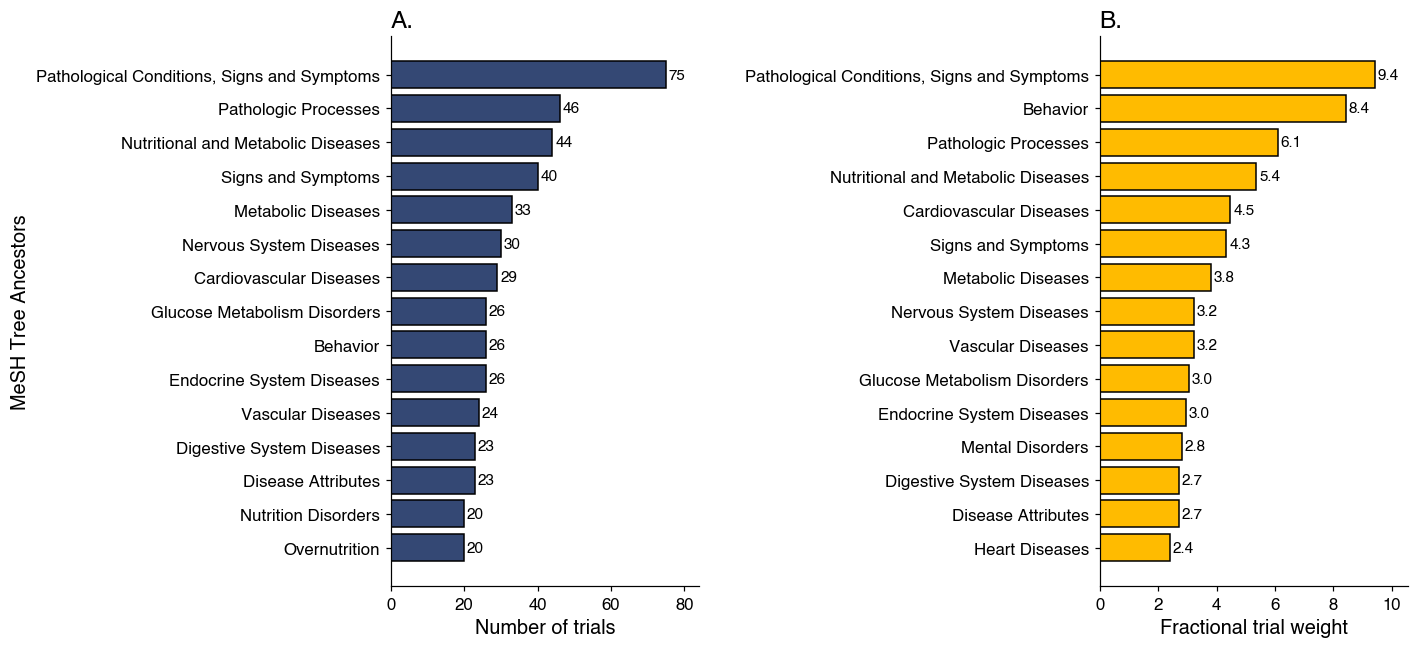

In [23]:
# ancestors 

assert "mesh_leaf" in df_ct.columns, "run: python src/utils/clinical_trials_fetch_ctgov.py"

# A handful of leaf terms are still not diseases — CTgov maps condition text like "physical
# activity" / "healthy" onto behavioural or descriptive MeSH. Same treatment as RCDC_STOP.
MESH_LEAF_STOP = {
    "Motor Activity", "Health Behavior", "Genetic Risk Score", "Psychological Well-Being",
    "Weight Loss", "Chronic Disease", "Body Weight", "Life Style", "Exercise",
}

df_ct["mesh_ancestors_condition"] = df_ct["mesh_ancestors"].apply(
    lambda c: [t for t in item_names(c) if t not in MESH_LEAF_STOP])

n_ship = int(df_ct["mesh_terms"].apply(lambda x: len(parse_listcol(x)) > 0).sum())
n_leaf = int(df_ct["mesh_ancestors"].apply(lambda x: len(parse_listcol(x)) > 0).sum())
n_leafd = int(df_ct["mesh_ancestors_condition"].str.len().gt(0).sum())
med_ship = df_ct["mesh_terms"].apply(lambda x: len(parse_listcol(x))).median()
med_leaf = df_ct["mesh_ancestors"].apply(lambda x: len(parse_listcol(x))).median()
print(f"trials with MeSH   — shipped (leaf+ancestors+interventions): {n_ship}/{len(df_ct)}"
      f"  |  registry leaf: {n_leaf}/{len(df_ct)}  |  leaf & disease: {n_leafd}/{len(df_ct)}")
print(f"terms per trial    — shipped median {med_ship:.0f}  |  leaf median {med_leaf:.0f}"
      f"   (the difference is tree scaffolding + intervention terms)")
print(f"distinct terms     — shipped {count_items(df_ct['mesh_terms']).size}"
      f"  |  leaf {count_items(df_ct['mesh_ancestors']).size}")

# ---- the clean disease bars: leaf terms, raw vs fractional -------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_hbar(count_items(df_ct["mesh_ancestors_condition"], top=15), "a.",
          "Number of trials", color=STYLE["c_primary"], ax=axes[0],ylabel="MeSH Tree Ancestors")
plot_hbar(count_items_frac(df_ct["mesh_ancestors_condition"]).head(15),
          "b.", "Fractional trial weight",
          color=STYLE["c_gold"], fmt="{:.1f}", ax=axes[1])
fig.tight_layout(w_pad=3); savefig(fig, "ct_diseases_mesh_ancestors")
plt.show()


#### 3.5.2 MeSH leaf → ICD-10, via MeSH's own hierarchy (not keywords)

§3.3 mapped disease names to ICD chapters with a **keyword list** (`"heart"` → Circulatory).
That was always a guess, and it failed in three ways: substring accidents (`"alcohol"` fired
on *NON-alcoholic Fatty Liver Disease*, putting every NAFLD trial in Mental & behavioural);
chapter *order* silently deciding ties; and it only knew the words someone thought to type —
**74 of 220** leaf terms went unmapped, including real conditions like *Wounds and Injuries*
and *Premature Birth*.

For the MeSH leaf axis we don't have to guess any more. ClinicalTrials.gov returns each
condition's **MeSH descriptor id** (`Pulmonary Disease, Chronic Obstructive` = `D029424`), the
re-fetch now stores it (`mesh_leaf_ids`), and every descriptor carries **tree numbers**
(`C08.381.495.389`) whose top-level category maps cleanly onto an ICD chapter. `src/utils/mesh_tree.py`
pulls the trees from NLM's **public MeSH SPARQL endpoint** (no key, no UMLS licence), caches
them, and applies the map in `MESH_CAT_TO_ICD` — which is a table you can read and argue with.

| | keyword route | descriptor → tree route |
|---|---|---|
| trials mapped to ≥1 chapter | 150 / 195 | **169 / 195** |
| distinct terms/descriptors mapped | 146 / 220 (66%) | **209 / 227 (92%)** |
| *Wounds and Injuries* | unmapped | XIX Injury |
| *Premature Birth* | unmapped | XV Pregnancy |
| *Motor Activity*, *Smoking Cessation* | unmapped (by luck) | **unmapped by construction** (F01 = behaviour, not disease) |

Three design decisions, all visible in `mesh_tree.py`:

* **Behaviour trees (F01) map to nothing.** *Motor Activity*, *Sedentary Behavior* and
  *Smoking Cessation* are not diseases, so they get no chapter — the hierarchy enforces what
  the `MESH_LEAF_STOP` list previously had to do by hand.
* **The generic C23 branch (*Pathological Conditions, Signs and Symptoms*) is a last resort.**
  A descriptor is placed by its specific body-system tree if it has one; only descriptors that
  have *nothing but* C23 (*Inflammation*, *Frailty*, *Fibrosis*, *Genetic Predisposition*) land
  in chapter XVIII. That is why XVIII is suddenly visible — those trials existed before, they
  were simply invisible.
* **Supplementary Concept Records are followed, not dropped.** Rare-disease concepts
  (*Prostate cancer, familial*) carry no trees of their own; we resolve them through their
  `preferredMappedTo` heading (→ *Prostatic Neoplasms* → II Neoplasms).

The **keyword map is still used** — but only for the two axes that have no descriptor ids: the
shipped `mesh_terms` column (names only) and RCDC. Those remain approximations, and the three-axis
comparison below now mixes one principled mapping with two keyword ones, which is worth
remembering when reading it.

> Re-running the pipeline: `python src/utils/clinical_trials_fetch_ctgov.py --refresh` (stores
> `mesh_leaf_ids`), then this cell fetches and caches the MeSH trees on first run.

MeSH leaf -> ICD : descriptor/tree route maps 145/168 trials; the keyword route managed 130/168


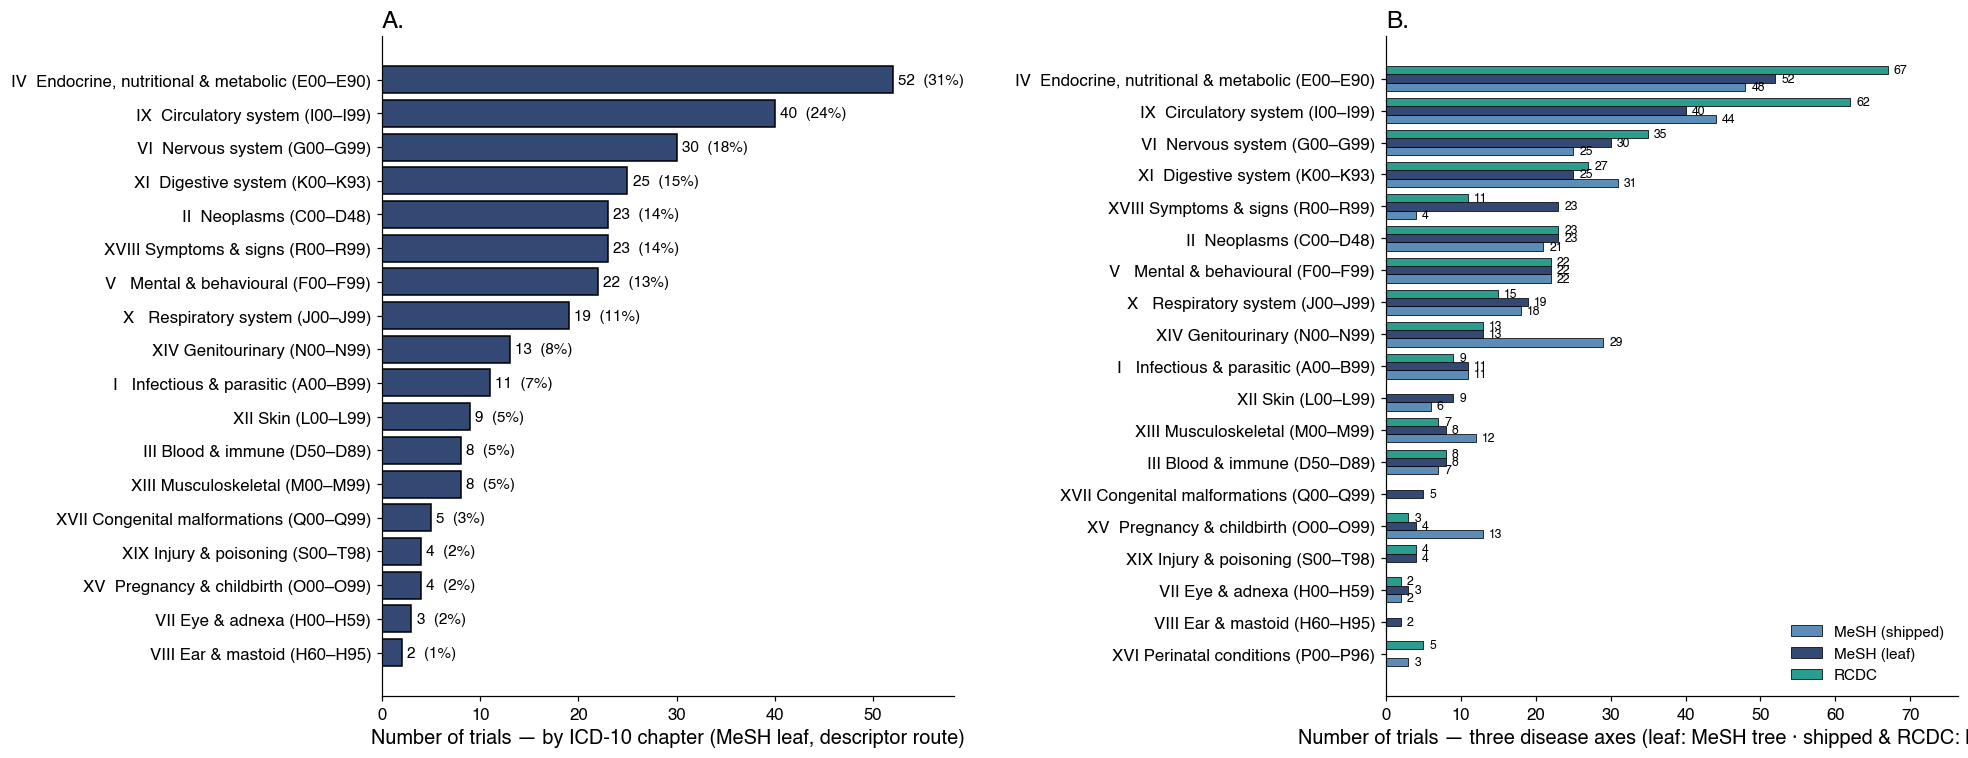

MeSH (shipped) : 144/168 trials mapped to >=1 ICD-10 chapter   [keyword]
MeSH (leaf)    : 145/168 trials mapped to >=1 ICD-10 chapter   [MeSH tree]
RCDC           : 159/168 trials mapped to >=1 ICD-10 chapter   [keyword]

Descriptors: 206 | mapped 192 | not a disease / unmapped 14 (behaviour & generic-symptom trees)

The shipped column maps MORE trials only because its ancestor terms (e.g. 'Nervous System Diseases') match a chapter even when no disease was studied.


,MeSH (shipped),MeSH (leaf),RCDC
"IV Endocrine, nutritional & metabolic (E00–E90)",48,52,67
IX Circulatory system (I00–I99),44,40,62
VI Nervous system (G00–G99),25,30,35
XI Digestive system (K00–K93),31,25,27
XVIII Symptoms & signs (R00–R99),4,23,11
II Neoplasms (C00–D48),21,23,23
V Mental & behavioural (F00–F99),22,22,22
X Respiratory system (J00–J99),18,19,15
XIV Genitourinary (N00–N99),29,13,13
I Infectious & parasitic (A00–B99),11,11,9


In [24]:
# =============================================================================
# LEAF MeSH -> ICD-10 chapters — via MeSH's OWN HIERARCHY, not keywords
# =============================================================================
# The keyword map (§3.3/§3.4.1) guesses a chapter from the term STRING. For the MeSH leaf
# axis we no longer have to guess: CTgov gives us each condition's MeSH descriptor id
# (D029424 = COPD), and every descriptor carries tree numbers (C08.381.495.389) whose
# top-level category maps onto an ICD chapter. src/utils/mesh_tree.py fetches the trees from
# NLM's public SPARQL endpoint (cached to disk) and applies that map.
#
# Why it is better than the keyword list:
#   * no substring accidents (it was 'alcohol' in 'NON-alcoholic Fatty Liver Disease' that
#     put every NAFLD trial in Mental & behavioural);
#   * it knows terms nobody thought to type — Wounds and Injuries -> XIX, Premature Birth ->
#     XV, Memory Disorders -> VI;
#   * behaviour-only descriptors (F01: Motor Activity, Smoking Cessation, Sedentary Behavior)
#     map to NOTHING, which is correct — they are not diseases;
#   * supplementary concepts (rare diseases, no trees of their own) are resolved through
#     their `preferredMappedTo` heading instead of being dropped.
#
# The KEYWORD map is kept for the two axes that have no descriptor ids: the shipped
# `mesh_terms` column (names only) and RCDC.
from utils.data_analysis_04_non_academic_clinical_trials_mesh_tree import fetch_tree_numbers, descriptor_chapters, audit

if "mesh_leaf_ids" not in df_ct.columns:
    raise FileNotFoundError(
        "Missing clinical-trial MeSH descriptor IDs (mesh_leaf_ids). Restore the enriched "
        "clinical_trials.csv and mesh_tree_numbers.pkl; the Showcase+ snapshot contains "
        "term names but cannot recover descriptor IDs. "
        "See src/utils/data_creation_clinical_trials_fetch_ctgov.py for the separate enrichment step."
    )

# IMPORTANT: filter the descriptor ids by the SAME stop-list applied to the names
# (mesh_leaf_disease). Otherwise non-disease leaves (Genetic Risk Score, Body Weight, ...)
# leak into the ICD chapters through the id path — they all carry only a C23 tree, so they
# spuriously inflate chapter XVIII (Symptoms & signs). Names and ids are position-aligned.
def _leaf_ids_disease(row):
    return [d for n, d in zip(item_names(row["mesh_leaf"]), parse_listcol(row["mesh_leaf_ids"]))
            if n not in MESH_LEAF_STOP]
df_ct["mesh_leaf_id_list"] = df_ct.apply(_leaf_ids_disease, axis=1)
MESH_TREE = fetch_tree_numbers(
    {d for L in df_ct["mesh_leaf_ids"].apply(parse_listcol) for d in L},
    allow_network=False,
)

# per-trial ICD chapters from the descriptors (the set a trial touches)
df_ct["icd_leaf"] = df_ct["mesh_leaf_id_list"].apply(
    lambda L: descriptor_chapters(L, MESH_TREE))

leaf_icd = (pd.Series(Counter(ch for S in df_ct["icd_leaf"] for ch in S), dtype="int64")
              .sort_values(ascending=False))
n_leaf_icd = int(df_ct["icd_leaf"].apply(len).gt(0).sum())

# the two axes WITHOUT descriptor ids still use the keyword rules
ship_icd, n_ship_icd = icd_chapter_counts(df_ct["mesh_terms"])
rcdc_icd2, n_rcdc_icd2 = icd_chapter_counts(df_ct["rcdc_disease"])

# what the old keyword route made of the same leaf terms — the honest before/after
_kw_leaf, _n_kw_leaf = icd_chapter_counts(df_ct["mesh_leaf_disease"])
print(f"MeSH leaf -> ICD : descriptor/tree route maps {n_leaf_icd}/{len(df_ct)} trials; "
      f"the keyword route managed {_n_kw_leaf}/{len(df_ct)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_hbar(leaf_icd, "a.", "Number of trials — by ICD-10 chapter (MeSH leaf, descriptor route)",
          color=STYLE["c_primary"], pct_of=len(df_ct), ax=axes[0])

# (b) the three axes over the same chapters
comp3 = (pd.concat([ship_icd.rename("MeSH (shipped)"), leaf_icd.rename("MeSH (leaf)"),
                    rcdc_icd2.rename("RCDC")], axis=1)
           .fillna(0).astype(int).sort_values("MeSH (leaf)"))
ax = axes[1]
y, h = np.arange(len(comp3)), 0.26
for i, (src, col) in enumerate([("MeSH (shipped)", STYLE["colors"][3]),
                                ("MeSH (leaf)", STYLE["c_primary"]),
                                ("RCDC", STYLE["c_green"])]):
    bars = ax.barh(y + (i - 1) * h, comp3[src].values, height=h, label=src,
                   color=col, edgecolor=STYLE["edgecolor"], linewidth=0.5)
    for b, v in zip(bars, comp3[src].values):
        if v:
            ax.text(v + 0.8, b.get_y() + b.get_height() / 2, str(int(v)),
                    va="center", fontsize=STYLE["annot_fs"] - 2)
ax.set_yticks(y); ax.set_yticklabels(comp3.index)
# NOT "identical rules" any more: the leaf axis is mapped by MeSH's hierarchy, the other
# two by the keyword list (they have no descriptor ids). Say so on the axis.
ax.set_xlabel("Number of trials — three disease axes "
              "(leaf: MeSH tree · shipped & RCDC: keyword)",
              fontsize=STYLE["label_fs"])
set_title(ax, "b.",
             fontsize=STYLE["title_fs"], loc="left", fontweight="bold")
ax.legend(fontsize=STYLE["legend_fs"] - 1, frameon=False, loc="lower right")
ax.margins(x=0.14)
fig.tight_layout(w_pad=4); savefig(fig, "ct_icd_three_axes")
plt.show()

for lab, n, how in [("MeSH (shipped)", n_ship_icd, "keyword"),
                    ("MeSH (leaf)", n_leaf_icd, "MeSH tree"),
                    ("RCDC", n_rcdc_icd2, "keyword")]:
    print(f"{lab:<15}: {n}/{len(df_ct)} trials mapped to >=1 ICD-10 chapter   [{how}]")

# audit — every descriptor, its trees, and the chapter(s) they resolve to
_aud = audit({d for L in df_ct["mesh_leaf_id_list"] for d in L}, MESH_TREE)
_unmapped = _aud[_aud["chapters"] == "— none —"]
print(f"\nDescriptors: {len(_aud)} | mapped {len(_aud) - len(_unmapped)} | "
      f"not a disease / unmapped {len(_unmapped)} (behaviour & generic-symptom trees)")
print("\nThe shipped column maps MORE trials only because its ancestor terms "
      "(e.g. 'Nervous System Diseases') match a chapter even when no disease was studied.")
display(comp3.sort_values("MeSH (leaf)", ascending=False))

In [25]:
169/195

0.8666666666666667

#### 3.5.1 The trials with **no** `mesh_terms` — what are they actually about?

Dimensions ships **no MeSH at all** for a handful of trials. Rather than treat that as a hole
to be filled, the cell below reads what those trials *say* (`conditions`, `brief_title`,
`registry`, `start_date`, RCDC) and sorts them into **why** the MeSH is absent. The reasons
are derived from the data, not hand-typed per trial, so this survives a refresh of the
trials file:

| reason | rule | what it means |
|---|---|---|
| **non-CTgov registry** | `registry != ClinicalTrials.gov` | ISRCTN/EU-CTR records never get an NLM browse module — MeSH is *structurally* unavailable, not missing |
| **recovered by re-fetch** | registry leaf MeSH now non-empty | the Dimensions snapshot pre-dates NLM's indexing; §3.5 already pulled the terms back |
| **too recent to be indexed** | `start_year >= 2025` | registrations in the final analysis year (future starts are excluded). NLM has not generated the browse module yet — these will populate on their own |
| **studies no disease** | everything else | `conditions` is `Healthy`, `Aging`, `Health promotion`, `Body composition`, `Post menopause`… — healthy-volunteer physiology, behaviour and life-stage trials |

That last group is the point worth carrying into the write-up: **the blank is a finding, not a
gap.** Imputing a disease onto a healthy-volunteer salt-intake trial or a twins MRI ageing
study would manufacture a disease focus that the trial does not have.

In [26]:
# =============================================================================
# WHY is mesh_terms missing? — classify, don't impute
# =============================================================================
def _no_mesh_reason(r):
    """Data-derived reason a trial carries no Dimensions MeSH (rules, not a hard-coded list)."""
    if str(r["registry"]).strip() != "ClinicalTrials.gov":
        return "1. non-CTgov registry (no NLM MeSH exists)"
    if len(parse_listcol(r["mesh_leaf"])) > 0:
        return "2. recovered by the §3.5 re-fetch"
    yr = r["start_year"]
    if pd.notna(yr) and int(yr) >= 2025:
        return "3. too recent — not yet indexed by NLM"
    return "4. studies no disease (healthy / physiology / behaviour)"


no_mesh = df_ct[df_ct["mesh_terms"].isna()].copy()
no_mesh["reason"] = no_mesh.apply(_no_mesh_reason, axis=1)
no_mesh["conditions_txt"] = no_mesh["conditions"].apply(lambda x: "; ".join(parse_listcol(x)))
no_mesh["rcdc_top"] = no_mesh["rcdc_disease"].apply(lambda ts: ", ".join(ts[:4]) or "—")
no_mesh["leaf_now"] = no_mesh["mesh_leaf"].apply(lambda x: ", ".join(item_names(x)) or "—")

print(f"Trials with NO Dimensions mesh_terms: {len(no_mesh)}/{len(df_ct)}\n")
print(no_mesh["reason"].value_counts().sort_index().to_string())
print("\nEvery one of them, and what it is about:")
with pd.option_context("display.max_colwidth", 60, "display.width", 250):
    display(no_mesh.sort_values("reason")[
        ["id", "reason", "brief_title", "conditions_txt", "leaf_now", "rcdc_top",
         "start_year", "study_type"]
    ].rename(columns={"conditions_txt": "conditions (free text)",
                      "leaf_now": "registry MeSH leaf (now)",
                      "rcdc_top": "RCDC disease tags"}).reset_index(drop=True))

print("\nEvery one of these trials still carries RCDC disease tags "
      f"({int(no_mesh['rcdc_disease'].str.len().gt(0).sum())}/{len(no_mesh)}), which is why "
      "RCDC (§3.4) covers more trials than any MeSH route — but a disease-free trial with a\n"
      "generic RCDC tag is still a disease-free trial. We report the blank; we do not fill it.")

Trials with NO Dimensions mesh_terms: 10/168

reason
2. recovered by the §3.5 re-fetch                           3
3. too recent — not yet indexed by NLM                      3
4. studies no disease (healthy / physiology / behaviour)    4

Every one of them, and what it is about:


,id,reason,brief_title,conditions (free text),registry MeSH leaf (now),RCDC disease tags,start_year,study_type
0,NCT04785469,2. recovered by the §3.5 re-fetch,Eccentric Training in Individuals With COPD,Copd,"Pulmonary Disease, Chronic Obstructive","Chronic Obstructive Pulmonary Disease, Lung",2021,Interventional
1,NCT04035941,2. recovered by the §3.5 re-fetch,The Cycle Nation Project (Phase 2: Feasibility),Health behavior,"Health Behavior, Motor Activity",—,2019,Interventional
2,NCT06169020,2. recovered by the §3.5 re-fetch,Developing Intelligent Wearable Algorithms,Health promotion,Motor Activity,"Obesity, Cardiovascular, Nutrition",2023,Interventional
3,NCT06769347,3. too recent — not yet indexed by NLM,Circulating Vascular Regenerative Cell Exhaustion in Ind...,Cardiovascular diseases risk,—,"Nutrition, Heart Disease, Cardiovascular, Diabetes",2025,Observational
4,NCT07163767,3. too recent — not yet indexed by NLM,Acute Myocardial Infarction Prediction Using Artificial ...,Acute myocardial infarction (AMI); Electrocardiography; ...,—,"Heart Disease, Cardiovascular, Heart Disease - Coronary ...",2025,Observational
5,NCT07170904,3. too recent — not yet indexed by NLM,"Dietary Patterns, Inflammation, Zinc Status, and Body Co...",Body composition; Zinc status; Dietary analysis; TNF Alp...,—,"Obesity, Nutrition, Cardiovascular",2025,Observational
6,NCT06014567,4. studies no disease (healthy / physiology / behaviour),Twins MR Imaging Study,Aging,—,"Dementia, Neurodegenerative, Brain Disorders, Acquired C...",2023,Observational
7,NCT05052749,4. studies no disease (healthy / physiology / behaviour),High Intensity Resistance Training In Postmenopausal Wom...,Post menopause,—,"Osteoporosis, Estrogen, Cardiovascular",2021,Interventional
8,NCT05839860,4. studies no disease (healthy / physiology / behaviour),"Salt Intake, Hydration Status and Gastrointestinal Disco...",Healthy,—,"Nutrition, Cardiovascular",2023,Interventional
9,NCT06031545,4. studies no disease (healthy / physiology / behaviour),An Exploratory Study of Perioperative Venous Access in O...,Catheter complications,—,Obesity,2023,Interventional



Every one of these trials still carries RCDC disease tags (9/10), which is why RCDC (§3.4) covers more trials than any MeSH route — but a disease-free trial with a
generic RCDC tag is still a disease-free trial. We report the blank; we do not fill it.


### 3.6 What each disease is *called*, and where it sits in ICD — two heatmaps

Both panels share the **same y-axis**: the top-10 **MeSH leaf diseases** (§3.5), ranked by trial count, with each row's trial count in the label.

* **(a) disease × free-text `conditions`.** The rows are the *controlled* vocabulary NLM
  derived; the columns are what the sponsor actually **typed** into the registry, normalised
  with the same `norm_key` + synonym map as the §3.2 word cloud. The cell is the **% of that
  disease's trials whose `conditions` carry that phrase**. The strong cells on the "diagonal"
  are expected — `mesh_leaf` is *derived from* `conditions`, so this is partly a picture of
  the mapping itself (which surface forms NLM folded into which MeSH descriptor). The
  informative part is **off-diagonal**: the *other* things a disease's trials are also about
  — e.g. what obesity trials co-list alongside obesity.
* **(b) disease × ICD-10 chapter.** The same rows against the ICD chapters, using the §3.4.1
  rules. The diagonal is 100% by construction (an *Atrial Fibrillation* trial is always
  Circulatory); the informative part is again **off-diagonal** — the co-morbidity spread of
  each disease's trials.

Both use `Spectral_r` (cool = rare → warm = common) and are drawn as one figure.

> Percentages are over the trials **in that row**, and the tail rows are small (`n` is in each
> label) — read the bottom rows as indicative, not as rates.

Rows: top 10 MeSH leaf diseases  |  (a) cols: top 10 normalised free-text conditions  |  (b) cols: 10 ICD-10 chapters touched


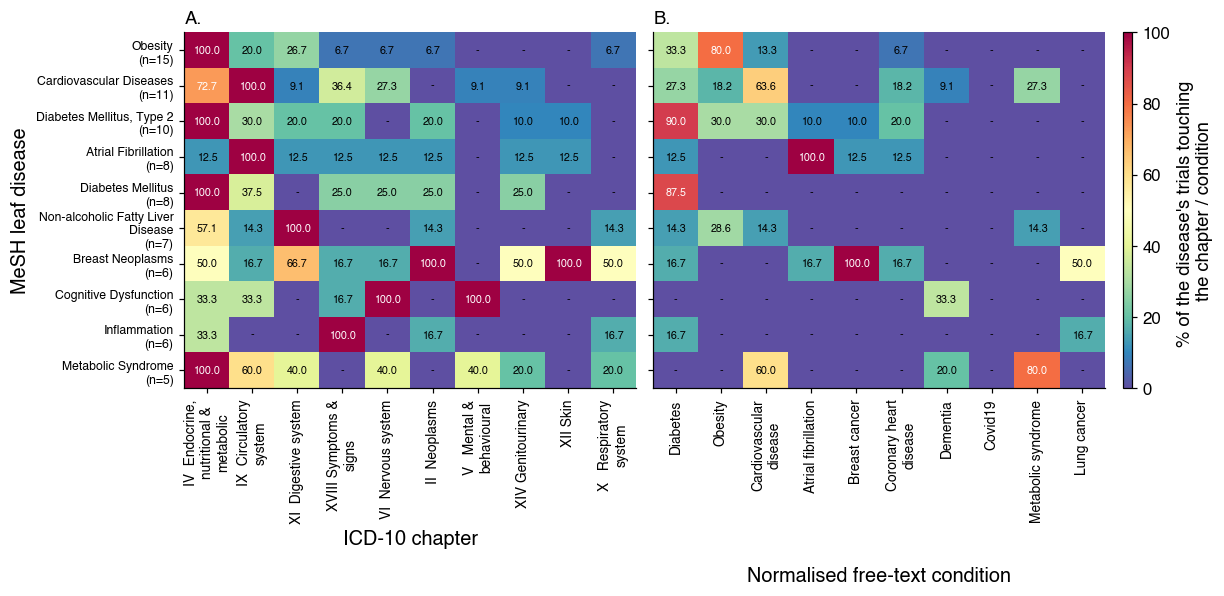

In [27]:
# =============================================================================
# §3.6  MeSH leaf x {free-text conditions, ICD chapters} — one figure, shared y-axis
# =============================================================================
import textwrap

# ---- per-trial NORMALISED conditions -----------------------------------------
# Same normalisation as the §3.2 word cloud (norm_key + COND_SYNONYMS), so the labels here
# and there are the same objects. normalized_condition_freq() only returns totals, so we
# rebuild the key -> display-label map (canonical synonym if any, else the commonest
# surface form) and then tag each trial with its labels.
def build_cond_label_map(series):
    """merge-key -> display label, exactly as normalized_condition_freq labels them."""
    surf = defaultdict(Counter)
    for cell in series:
        for it in item_names(cell):
            surf[norm_key(it)][html.unescape(it)] += 1
    return {k: (k if k in _CANON else c.most_common(1)[0][0]) for k, c in surf.items()}


COND_LABEL = build_cond_label_map(df_ct["conditions"])
df_ct["cond_norm"] = df_ct["conditions"].apply(
    lambda cell: sorted({COND_LABEL[norm_key(it)] for it in item_names(cell)}))

TOP_LEAF, TOP_COND = 10, 10

# rows = the TOP_LEAF diseases by RAW trial count (so the row order matches the n= in each
# label; fractional weight would push e.g. COVID-19 above higher-count Cognitive Dysfunction).
leaf_rank = count_items(df_ct["mesh_leaf_disease"]).head(TOP_LEAF)
leaves = list(leaf_rank.index)
leaf_trials = {L: df_ct[df_ct["mesh_leaf_disease"].apply(lambda T: L in T)] for L in leaves}

# (a) columns: the commonest normalised conditions among the disease-coded trials
# raw trial count (consistent with the row ranking), restricted to disease-coded trials
conditions = list(count_items(
    df_ct.loc[df_ct["mesh_leaf_disease"].apply(len).gt(0), "cond_norm"]
).head(TOP_COND).index)

# (b) columns: the ICD chapters these diseases actually touch, most-used first.
# `icd_leaf` comes from §3.5 — the MeSH descriptor -> tree -> chapter route, not keywords.
_ch_count = Counter()
for sub in leaf_trials.values():
    for S in sub["icd_leaf"]:
        _ch_count.update(S)
chapters = [c for c, _ in _ch_count.most_common()]
chapters = chapters[0:TOP_COND] if len(chapters) > TOP_COND else chapters
H_cond = pd.DataFrame(
    [[100 * sub["cond_norm"].apply(lambda C: c in C).mean() for c in conditions]
     for sub in leaf_trials.values()], index=leaves, columns=conditions)
H_icd = pd.DataFrame(
    [[100 * sub["icd_leaf"].apply(lambda S: ch in S).mean() for ch in chapters]
     for sub in leaf_trials.values()], index=leaves, columns=chapters)

print(f"Rows: top {len(leaves)} MeSH leaf diseases  |  "
      f"(a) cols: top {len(conditions)} normalised free-text conditions  |  "
      f"(b) cols: {len(chapters)} ICD-10 chapters touched")

# ---- draw --------------------------------------------------------------------
n = len(leaves)
# n on the same line, wrapped as one string: the two-line form collided row-to-row
ylabels = [textwrap.fill(f"{L} \n", 25)+f"\n(n={len(leaf_trials[L])})" for L in leaves][::-1]
# ylabels = [textwrap.fill(f"{L} \n(n={len(leaf_trials[L])})", 32) for L in leaves][::-1]
short_chap = [c.split("(")[0].strip() for c in chapters]     # 'IX  Circulatory system'

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5), sharey=True, layout="constrained",
                               gridspec_kw={"width_ratios": [1, 1]})

# Both panels are the SAME quantity on the SAME 0-100 scale (% of the row's trials), so they
# share one colour scale and ONE colourbar — two bars would imply two different scales.
for i, ax, M, cols, title in [
        (0, ax0, H_icd.values[::-1], short_chap,
         "a."),
        (1, ax1, H_cond.values[::-1], conditions,
         "b.")]:
    im = ax.imshow(M, aspect="auto", cmap="Spectral_r", origin="lower", vmin=0, vmax=100,
                   extent=(-0.5, len(cols) - 0.5, -0.5, n - 0.5))
    if i==0:
        ax.set_xticks(range(len(cols)))
        ax.set_ylabel("MeSH leaf disease", fontsize=STYLE["label_fs"])
        #ax.set_xlabel("Normalised free-text condition", fontsize=STYLE["label_fs"])
        ax.set_xlabel("ICD-10 chapter", fontsize=STYLE["label_fs"])
    else:
        ax.set_xticks(range(len(cols)))
        
        ax.text(0.5, -0.5, "Normalised free-text condition", fontsize=STYLE["label_fs"],
                ha="center", va="top", transform=ax.transAxes)
   
    ax.set_xticklabels([textwrap.fill(c, 20) for c in cols], rotation=90, ha="center",
                       fontsize=STYLE["tick_fs"] - 2)
    for i in range(n):
        for j in range(len(cols)):
            ax.text(j, i, f"{M[i, j]:.1f}" if M[i, j]>0 else '-', ha="center", va="center", #  if M[i, j]>0 else ''
                    fontsize=STYLE["annot_fs"] - 3,
                    color="white" if M[i, j] > 72 else "black")
    # add grid
    set_title(ax, title, loc="left", fontsize=12, fontweight="bold")

# one horizontal colourbar under both panels
cb = fig.colorbar(im, ax=[ax0, ax1], #orientation="horizontal", location="bottom",
                  fraction=0.05, pad=0.02, aspect=40)
cb.set_label("% of the disease's trials touching \nthe chapter / condition",
             fontsize=STYLE["label_fs"] - 1)

ax0.set_yticks(np.arange(n))
ax0.set_yticklabels(ylabels, fontsize=STYLE["tick_fs"] - 3)

savefig(fig, "ct_mesh_leaf_condition_icd_heatmaps")
plt.show()

## 4. Status — aggregated lifecycle stage

We report status only at the **coarse lifecycle stage** (not the raw 9 registry labels),
split by interventional vs. observational `study_type`. The 9→5 mapping:

| stage | registry `overall_status` values folded in |
|---|---|
| **Planned** | Not yet recruiting |
| **Ongoing** | Recruiting · Enrolling by invitation · Active, not recruiting |
| **Completed** | Completed |
| **Stopped early** | Terminated · Withdrawn · Suspended |
| **Unknown** | Unknown status |

Each bar is annotated with its count; **Σ** is the per-stage total.

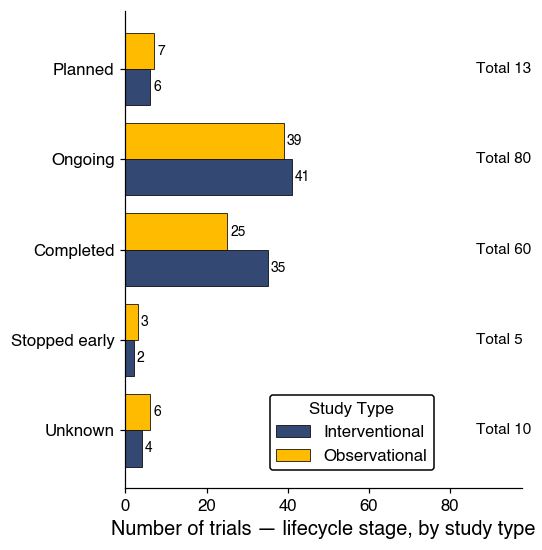

study_type,Interventional,Observational,Total
status_stage,,,
Unknown,4,6,10
Stopped early,2,3,5
Completed,35,25,60
Ongoing,41,39,80
Planned,6,7,13


In [28]:
def plot_grouped_status(df, status_col, group_col, style=STYLE, ax=None,
                        title="", order=None, name="status"):
    """Horizontal grouped bars with per-bar counts and a bold per-status Σ total."""
    tab = df.groupby([status_col, group_col]).size().unstack(fill_value=0)
    if order is not None:
        tab = tab.reindex([o for o in order if o in tab.index]).iloc[::-1]
    else:
        tab = tab.loc[tab.sum(axis=1).sort_values().index]
    groups = list(tab.columns)
    totals = tab.sum(axis=1)
    xmax = max(int(totals.max()), 1)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 0.7 * len(tab) + 1.6))
    else:
        fig = ax.figure
    y = np.arange(len(tab)); h = 0.8 / max(len(groups), 1)
    for i, g in enumerate(groups):
        bars = ax.barh(y + i*h - 0.4 + h/2, tab[g].values, height=h,
                       label=str(g), color=style["colors"][i % len(style["colors"])],
                       edgecolor=style["edgecolor"], linewidth=0.5)
        for b, v in zip(bars, tab[g].values):
            if v > 0:
                ax.text(v + xmax*0.01, b.get_y() + b.get_height()/2, f"{int(v)}",
                        va="center", fontsize=style["annot_fs"] - 1)
    for yi, tot in zip(y, totals.values):
        ax.text(xmax*1.08, yi, f"Total {int(tot)}", va="center", ha="left",
                fontsize=style["annot_fs"], fontweight="bold")
    ax.set_yticks(y); ax.set_yticklabels(tab.index)
    ax.set_xlim(0, xmax * 1.22)
    ax.set_xlabel("Number of trials", fontsize=style["label_fs"])
    set_title(ax, title, fontsize=style["title_fs"], fontweight="bold")
    ax.legend(title=group_col.replace("_", " ").title(), frameon=True,
              fontsize=style["legend_fs"],loc="lower right", bbox_to_anchor=(0.8, 0.02))
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax, tab


STATUS_STAGE = {
    "Not yet recruiting":      "Planned",
    "Recruiting":              "Ongoing",
    "Enrolling by invitation": "Ongoing",
    "Active, not recruiting":  "Ongoing",
    "Completed":               "Completed",
    "Terminated":              "Stopped early",
    "Withdrawn":               "Stopped early",
    "Suspended":               "Stopped early",
    "Unknown status":          "Unknown",
}
STAGE_ORDER = ["Planned", "Ongoing", "Completed", "Stopped early", "Unknown"]
df_ct["status_stage"] = df_ct["overall_status"].map(STATUS_STAGE).fillna("Unknown")

_, _ax, stage_tab = plot_grouped_status(
    df_ct, "status_stage", "study_type", order=STAGE_ORDER,
    title="", name="ct_status_stage")
_ax.set_xlabel("Number of trials — lifecycle stage, by study type",
               fontsize=STYLE["label_fs"])
plt.show()


stage_tab.assign(Total=lambda t: t.sum(axis=1))

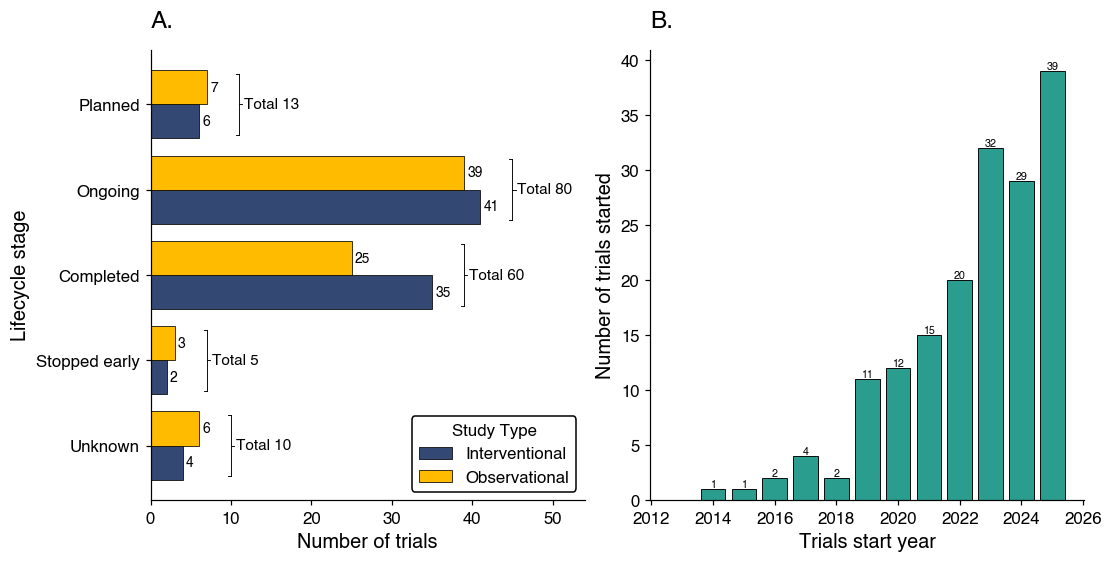

In [29]:
def plot_grouped_status(df, status_col, group_col, style=STYLE, ax=None,
                        title="", order=None, name="status", show_legend=True):
    """Horizontal grouped bars with per-bar counts and a bold per-status Σ total."""
    tab = df.groupby([status_col, group_col]).size().unstack(fill_value=0)

    if order is not None:
        tab = tab.reindex([o for o in order if o in tab.index]).iloc[::-1]
    else:
        tab = tab.loc[tab.sum(axis=1).sort_values().index]

    groups = list(tab.columns)
    totals = tab.sum(axis=1)

    # max single bar length, used for annotation spacing
    bar_max = max(int(tab.to_numpy().max()), 1)

    # longest bar in each row (use this to place Σ just to the right)
    row_max = tab.max(axis=1)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 0.7 * len(tab) + 1.6))
    else:
        fig = ax.figure

    y = np.arange(len(tab))
    h = 0.8 / max(len(groups), 1)

    for i, g in enumerate(groups):
        bars = ax.barh(
            y + i * h - 0.4 + h / 2,
            tab[g].values,
            height=h,
            label=str(g),
            color=style["colors"][i % len(style["colors"])],
            edgecolor=style["edgecolor"],
            linewidth=0.5,
            
        )

        for b, v in zip(bars, tab[g].values):
            if v > 0:
                ax.text(
                    v + bar_max * 0.01,
                    b.get_y() + b.get_height() / 2,
                    f"{int(v)}",
                    va="center",
                    fontsize=style["annot_fs"] - 1,
                )

    # place Σ next to the longest bar in each row
    row_max = tab.max(axis=1)

    offset = 4
    bracket_h = h * (len(groups) - 0.2)   # span almost the whole grouped bar height
    bracket_w = 0.4                        # horizontal tick length

    for yi, tot, rmax in zip(y, totals.values, row_max.values):

        x = rmax + offset

        # vertical line
        ax.plot(
            [x, x],
            [yi - bracket_h/2, yi + bracket_h/2],
            color="black",
            lw=0.6,
            clip_on=False,
        )
        
        # vertical line
        ax.plot(
            [x , x+bracket_w],
            [yi,yi],
            color="black",
            lw=0.6,
            clip_on=False,
        )

        # top tick
        ax.plot(
            [x - bracket_w, x],
            [yi - bracket_h/2, yi - bracket_h/2],
            color="black",
            lw=0.6,
            clip_on=False,
        )

        # bottom tick
        ax.plot(
            [x - bracket_w, x],
            [yi + bracket_h/2, yi + bracket_h/2],
            color="black",
            lw=0.6,
            clip_on=False,
        )

        # Σ label
        ax.text(
            x + 0.6,
            yi,
            f"Total {int(tot)}",
            va="center",
            ha="left",
            fontsize=style["annot_fs"],
            fontweight="bold",
        )
    ax.set_yticks(y)
    ax.set_yticklabels(tab.index)
    ax.set_xlabel("Number of trials", fontsize=style["label_fs"])

    # leave enough room on the right for Σ labels and legend
    xmax = max(int((row_max + offset).max()), bar_max)
    ax.set_xlim(0, xmax * 1.20)

    if show_legend:
        ax.legend(
            title=group_col.replace("_", " ").title(),
            frameon=True,
            fontsize=style["legend_fs"],
            loc="lower right",
            edgecolor="black",
        )

    if own_fig:
        fig.tight_layout()
        savefig(fig, name, style)

    return fig, ax, tab


def plot_bar_over_time(counts_by_year, title, ylabel, style=STYLE, color=None,
                       ax=None, name="over_time"):
    color = color or style["c_green"]
    own_fig = ax is None

    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    ax.bar(
        counts_by_year.index.astype(int),
        counts_by_year.values,
        color=color,
        edgecolor=style["edgecolor"],
        linewidth=0.6,
    )

    for x, v in zip(counts_by_year.index.astype(int), counts_by_year.values):
        if v > 0:
            ax.text(
                x, v, f"{int(v)}",
                ha="center", va="bottom",
                fontsize=style["annot_fs"] - 3
            )

    set_title(ax, title, fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year", fontsize=style["label_fs"])
    ax.set_ylabel(ylabel, fontsize=style["label_fs"])

    if own_fig:
        fig.tight_layout()
        savefig(fig, name, style)

    return fig, ax


# ---- data prep ----
STATUS_STAGE = {
    "Not yet recruiting":      "Planned",
    "Recruiting":              "Ongoing",
    "Enrolling by invitation": "Ongoing",
    "Active, not recruiting":  "Ongoing",
    "Completed":               "Completed",
    "Terminated":              "Stopped early",
    "Withdrawn":               "Stopped early",
    "Suspended":               "Stopped early",
    "Unknown status":          "Unknown",
}
STAGE_ORDER = ["Planned", "Ongoing", "Completed", "Stopped early", "Unknown"]
df_ct["status_stage"] = df_ct["overall_status"].map(STATUS_STAGE).fillna("Unknown")

start_counts = (
    df_ct.dropna(subset=["start_year"])
         .astype({"start_year": int})
         .groupby("start_year")
         .size()
)
start_counts = start_counts.reindex(
    range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1),
    fill_value=0
)

# ---- one merged figure ----
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [1, 1]},
    constrained_layout=True
)

plot_grouped_status(
    df_ct,
    "status_stage",
    "study_type",
    order=STAGE_ORDER,
    title="",
    ax=ax1,
    show_legend=True,
)

plot_bar_over_time(
    start_counts,
    "",
    "Number of trials started",
    color=STYLE["c_green"],
    ax=ax2,
)

# panel labels
ax1.text(0, 1.05, "A.", transform=ax1.transAxes, fontsize=STYLE['title_fs'], fontweight="bold", ha="left")
ax2.text(0, 1.05, "B.", transform=ax2.transAxes, fontsize=STYLE['title_fs'], fontweight="bold", ha="left")

# the panel titles now live on the x axes
ax1.set_xlabel("Number of trials", fontsize=STYLE["label_fs"])
ax1.set_ylabel("Lifecycle stage", fontsize=STYLE["label_fs"])
ax2.set_ylabel("Number of trials started", fontsize=STYLE["label_fs"])
ax2.set_xlabel("Trials start year", fontsize=STYLE["label_fs"])

# optional: save the combined figure once
savefig(fig, "ct_combined_figure", STYLE)
plt.show()

## 5. Recruitment size

How big are these trials? `study_participants` is the **planned enrollment** each trial
registered. It is heavily right-skewed, so we show it on a **log** axis with the median /
quartiles marked, plus a bucketed breakdown. (A handful of very large observational cohorts
dominate the raw total.)

In [30]:
print(df_ct['study_participants'].sum())

print(df_ct['study_participants'].describe())

615546
count       168.000000
mean       3663.964286
std       20186.829117
min           0.000000
25%          60.750000
50%         160.000000
75%         570.750000
max      203424.000000
Name: study_participants, dtype: float64


In [31]:
df_ct.sort_values(by='study_participants',ascending=False).head(10)

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,n_pids,org_sectors,rcdc_all,rcdc_disease,mesh_leaf_disease,mesh_ancestors_condition,mesh_leaf_id_list,icd_leaf,cond_norm,status_stage
171,This study will examine whether the type of di...,None,"[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]",Pre-Diagnosis GLP-1 Receptor Agonist Use and P...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '80138', 'name': '4203 Health Services...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '911', 'name': 'Cancer'}, {'id': '906'...","[{'id': '10501', 'name': '5.1 Pharmaceuticals'...",...,38,"[Academia, Government, Healthcare]","[Prevention, Clinical Trials and Supportive Ac...","[Cancer, Obesity, Nutrition, Diabetes]","[Obesity, Overweight, Diabetes Mellitus, Type ...","[Overnutrition, Nutrition Disorders, Nutrition...","[D009765, D050177, D003924, D009369]","{IV Endocrine, nutritional & metabolic (E00–E...","[Diabetes, Neoplasms, Obesity]",Completed
138,The goal of this observational study is to dev...,None,"[2025, 2026, 2027, 2028]",Acute Myocardial Infarction Prediction Using A...,None,"[{'id': '80017', 'name': '46 Information and C...","[{'id': '80017', 'name': '46 Information and C...",None,"[{'id': '894', 'name': 'Cardiovascular'}]","[{'id': '10401', 'name': '4.1 Discovery and pr...",...,33,[Healthcare],"[Prevention, Clinical Research, Networking and...","[Heart Disease, Cardiovascular, Heart Disease ...",[],[],[],{},"[Acute myocardial infarction, Artifical intell...",Ongoing
107,This is an observational study of participants...,Tobrisk-CoV,"[2017, 2018, 2019, 2020, 2021]",Tobacco Use and COVID-19 Incidence in the Finn...,"[{'id': '4003', 'name': 'Public Health'}]","[{'id': '80141', 'name': '4206 Public Health'}...","[{'id': '80141', 'name': '4206 Public Health'}...","[{'id': '3903', 'name': 'Population & Society'}]",None,"[{'id': '10204', 'name': '2.4 Surveillance and...",...,8,"[Academia, Government]","[Substance Misuse, Coronaviruses, Tobacco Smok...","[Substance Misuse, Coronaviruses, Tobacco Smok...","[COVID-19, Tobacco Use]","[Pneumonia, Viral, Pneumonia, Respiratory Trac...","[D000086382, D064424]","{I Infectious & parasitic (A00–B99), X Res...","[Covid19, SARS-Cov-2 infection]",Completed
14,The eMERGE Network embraces the opportunity to...,eMERGE,"[2022, 2023, 2024, 2025, 2026]",The Electronic Medical Records and GEnomics (e...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '3903', 'name': 'Population & Society'}]","[{'id': '890', 'name': 'Generic health relevan...",None,...,63,"[Academia, Healthcare]","[Minority Health, Human Genome, Biotechnology,...",[],"[Genetic Diseases, Inborn]","[Congenital, Hereditary, and Neonatal Diseases...",[D030342],{XVII Congenital malformations (Q00–Q99)},[Genetic disease],Ongoing
19,The Electronic Medical Records and Genomics (e...,eMERGE,"[2015, 2016, 2017, 2018, 2019, 2020]",Electronic Medical Records and Genomics (eMERG...,None,"[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...",None,None,None,...,11,"[Academia, Government, Healthcare, Industry, N...","[Human Genome, Precision Medicine, Biotechnolo...",[],"[Heart Diseases, Neoplasms, Hypercholesterolem...","[Cardiovascular Diseases, Hyperlipidemias, Dys...","[D006331, D009369, D006937, D003920, D007674, ...","{VI Nervous system (G00–G99), II Neoplasms (...","[Cancer, Cardiac disease, Diabetes, Hyperchole...",Completed
67,The purpose of this study is to characterize t...,ASAP,"[2021, 2022, 2023, 2024, 2025, 2026]",Avera Cancer Sequencing and Analytics Protocol...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id'

## 7. Who / where — organisations by geography and sector

Where are the trials that cite UKB research run, and **who** runs them? **Two figures**:

* **a world map** — trials per country (continuous shading, no bins), with the **top-5
  countries outlined and labelled** (leader lines), in the authorship notebook's
  `plot_country_map` style; ISO-3 matched via `patent_utils`;
* **a sector breakdown** — each research org mapped to a **sector** (Academia / Healthcare /
  Industry / Government / Nonprofit / Other) via its Dimensions `types`, stacked per country.

> Title note: these organisations run **UKB-citing** trials — **UK Biobank is not the trial
> sponsor**, so the figure says "where UKB-citing trials are run", not "UKB trials".

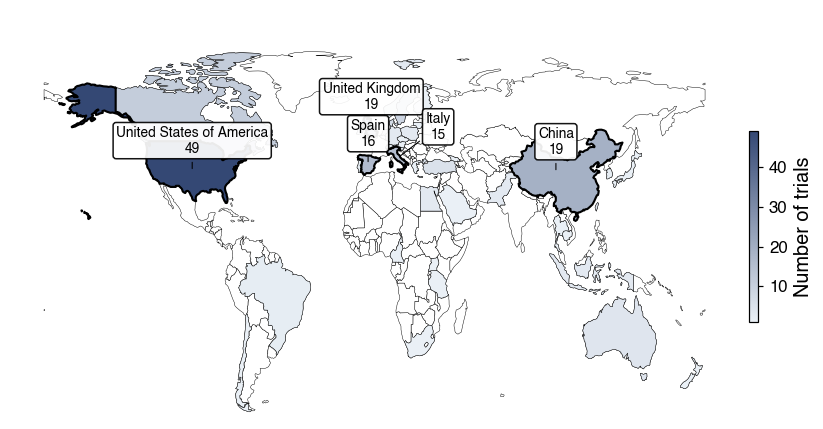

In [32]:
from functools import lru_cache


@lru_cache(maxsize=None)
def to_iso3(code, name):
    """ISO-3 from an ISO-2 country_code when clean, else fuzzy-match the country name
    (reuses patent_utils, same matcher as the authorship / patents maps)."""
    iso2 = None
    if isinstance(code, str) and len(code.strip()) == 2:
        iso2 = code.strip().upper()
    if iso2 is None:
        iso2 = patent.to_iso2(name)
    if iso2 is None:
        return None
    return patent.iso2_to_iso3(iso2)


def ct_country_iso_counts(df):
    """Trials per country as an ISO-3-indexed Series (each country once per trial)."""
    c = Counter()
    for cell in df["research_orgs"]:
        iso = set()
        for o in parse_listcol(cell):
            if isinstance(o, dict) and o.get("country_name"):
                i = to_iso3(o.get("country_code"), o.get("country_name"))
                if i:
                    iso.add(i)
        c.update(iso)
    return pd.Series(c, dtype="int64").sort_values(ascending=False)


def plot_ct_country_map(counts_iso, title, style=STYLE, ax=None, label="Trials",
                        annotate_top=5, name="ct_country_map"):
    """Continuous-shaded choropleth (no bins) of a per-country trial count. Countries with
    no trials are light grey; a colourbar carries the scale. `annotate_top` highlights and
    labels the N highest countries (black outline + name + value + leader line), mirroring
    the authorship notebook's `plot_country_map` style."""
    from matplotlib.colors import LinearSegmentedColormap
    import geopandas as gpd
    world = gpd.read_file(P.WORLD_SHP)
    world.columns = [c.lower() for c in world.columns]
    world = world[world["admin"] != "Antarctica"]
    world["iso_key"] = world["iso_a3"].where(world["iso_a3"] != "-99", world["adm0_a3"])
    cdf = counts_iso.rename_axis("iso3").reset_index(name="value")
    merged = world.merge(cdf, how="left", left_on="iso_key", right_on="iso3")

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 4))
    else:
        fig = ax.figure
    cmap = LinearSegmentedColormap.from_list("brand_seq", ["#EAF0F6", style["c_primary"]])
    merged.plot(color="#FFFFFF", ax=ax, edgecolor=style["edgecolor"], linewidth=0.3)  # base
    merged.dropna(subset=["value"]).plot(
        column="value", cmap=cmap, ax=ax, edgecolor=style["edgecolor"], linewidth=0.3,
        legend=True, legend_kwds={"label": label, "shrink": 0.5, "pad": 0.01})

    # highlight + label the top-N countries (black outline, leader lines, greedy stagger)
    if annotate_top:
        top = merged.dropna(subset=["value"]).nlargest(annotate_top, "value")
        top.boundary.plot(ax=ax, edgecolor="black", linewidth=1.4)
        placed = []
        def free_slot(x, y):
            # Wider search + wider "too close" box than a single map needs: in a 1x2 panel
            # the European top-5 (UK / Sweden / Netherlands) sit within a few degrees and
            # their label boxes overlapped at the tighter thresholds.
            for dy in (12, -12, 26, -26, 40, -40, 54, -54):
                for dx in (0, 22, -22, 42, -42, 62, -62):
                    cx, cy = x + dx, y + dy
                    if all(abs(cx - px) > 30 or abs(cy - py) > 14 for px, py in placed):
                        return cx, cy
            return x, y + 12
        for _, row in top.sort_values("value", ascending=False).iterrows():
            pt = row.geometry.representative_point()
            nm = row.get("name") or row.get("admin") or row["iso3"]
            lx, ly = free_slot(pt.x, pt.y); placed.append((lx, ly))
            ax.annotate(f"{nm}\n{int(row['value'])}", xy=(pt.x, pt.y), xytext=(lx, ly),
                        textcoords="data", ha="center", va="center",
                        fontsize=style["annot_fs"] - 1, fontweight="bold", color="black",
                        bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black",
                                  lw=1.0, alpha=0.92),
                        arrowprops=dict(arrowstyle="-", lw=0.7, color="black"), zorder=6)
    ax.set_ylim(-58, 90)
    set_title(ax, title, fontsize=style["title_fs"]-3, fontweight="bold", loc="left")
    ax.axis("off")
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


def country_sector_table(df, top_countries=10):
    """Fractional (country x sector) trial weights from research_orgs. Each trial spreads
    weight 1 across its unique (country, sector) org pairs -> columns sum to #located trials."""
    rows = []
    for cell in df["research_orgs"]:
        pairs = {(o.get("country_name"), org_sector(o))
                 for o in parse_listcol(cell)
                 if isinstance(o, dict) and o.get("country_name")}
        if not pairs:
            continue
        f = 1.0 / len(pairs)
        for c, s in pairs:
            rows.append((c, s, f))
    t = pd.DataFrame(rows, columns=["country", "sector", "w"])
    mat = t.pivot_table(index="country", columns="sector", values="w",
                        aggfunc="sum", fill_value=0)
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index].head(top_countries)
    cols = [s for s in SECTOR_ORDER if s in mat.columns]
    return mat[cols]


def plot_stacked_sectors(mat, title, xlabel, style=STYLE, ax=None,
                         color_map=SECTOR_COLORS, name="ct_where_sector"):
    mat = mat.iloc[::-1]                              # largest on top (barh)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10,7))
    else:
        fig = ax.figure
    y = np.arange(len(mat)); left = np.zeros(len(mat))
    for s in mat.columns:
        vals = mat[s].values
        ax.barh(y, vals, left=left, label=s, color=color_map.get(s, "#999"),
                edgecolor=style["edgecolor"], linewidth=0.4)
        left = left + vals
    totals = mat.sum(axis=1).values
    for yi, tot in zip(y, totals):
        ax.text(tot + totals.max()*0.01, yi, f"{tot:.0f}", va="center",
                fontsize=style["annot_fs"])
    ax.set_yticks(y); ax.set_yticklabels(mat.index)
    ax.set_xlabel(xlabel, fontsize=style["label_fs"])
    set_title(ax, title, fontsize=style["title_fs"], fontweight="bold")
    ax.legend(title="Sector", frameon=True, fontsize=style["legend_fs"], ncol=2,edgecolor="black")
    ax.margins(x=0.10)
    if own_fig:
        fig.tight_layout(); savefig(fig, name, style)
    return fig, ax


# Two separate figures (kept apart so the map keeps its natural aspect ratio).
# (1) annotated world map
iso_counts = ct_country_iso_counts(df_ct)
plot_ct_country_map(iso_counts, " ",#"Where UKB-citing trials are run (trials per country)",
                    label="Number of trials", annotate_top=5, name="ct_country_map")
plt.show()


In [33]:
iso_counts

USA    49
CHN    19
GBR    19
ESP    16
ITA    15
CAN    11
SWE     9
DNK     7
TUR     5
AUS     4
NLD     4
TWN     4
NOR     3
EGY     3
POL     3
DEU     3
PAK     3
IDN     3
BRA     2
CHE     2
PRT     2
KOR     2
AUT     1
SAU     1
GEO     1
KHM     1
FIN     1
CHL     1
IRL     1
BEL     1
GRC     1
SVN     1
ZAF     1
CMR     1
TZA     1
UGA     1
SGP     1
JPN     1
LTU     1
NZL     1
THA     1
CZE     1
CYM     1
dtype: int64

#### 7.1 Two geographies: where the **trials** run vs. where the **research** came from

The map above locates the *trials*. This pair sets it beside the geography of the **UK Biobank
papers those trials cite** — using the papers' **`research_orgs`** (the institutions credited on
the paper), *not* author affiliations, matched to ISO-3 with the same `to_iso3` used for the
trials, so the two panels are strictly comparable.

* **(a) Trials** — where the UKB-citing trials are run (each country counted once per trial).
* **(b) Cited UKB papers** — where the research those trials lean on was produced (each country
  once per paper).

Read together they separate **who produces the evidence** from **who acts on it**: a country
heavy in (b) but thin in (a) is exporting influence — its UKB findings are changing trial design
elsewhere.

Cited UKB papers : 166  |  with >=1 research-org country: 161/166  (60 countries)
Trials           : 168  |  with >=1 research-org country: 160/168  (43 countries)


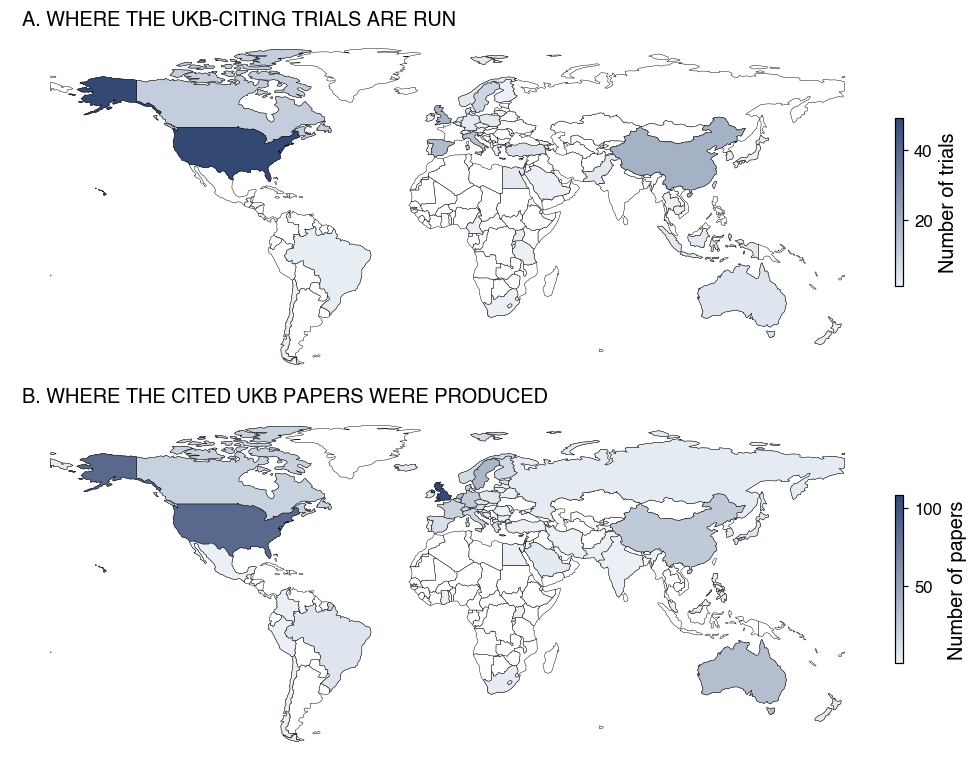

Top 12 countries by TRIALS — trials vs cited papers (research-org basis):


,trials,cited papers,papers/trial
USA,49,87,1.8
GBR,19,108,5.7
CHN,19,26,1.4
ESP,16,12,0.8
ITA,15,18,1.2
CAN,11,21,1.9
SWE,9,38,4.2
DNK,7,22,3.1
TUR,5,1,0.2
AUS,4,33,8.2


Top 12 countries by CITED PAPERS (who the trials draw their evidence from):


,trials,cited papers,papers/trial
GBR,19,108,5.7
USA,49,87,1.8
SWE,9,38,4.2
NLD,4,36,9.0
AUS,4,33,8.2
CHN,19,26,1.4
DEU,3,25,8.3
DNK,7,22,3.1
CAN,11,21,1.9
FRA,0,20,NaN


In [34]:
# =============================================================================
# §7.1  trials by country  vs  cited papers by country (research ORGS, not authors)
# =============================================================================
# §7 runs before §8 builds the corpus, and the columns §8 keeps do not include
# research_orgs — so read just the two columns this map needs, straight from the parquet
# (cheap, and it cannot clobber §8's `corpus`).
_papers_all = filter_analysis_window(pd.read_parquet(
    P.SHOWCASE_PLUS, columns=["id", "year", "date", "research_orgs"]
))

_pid_counter = Counter(p for ps in df_ct["pids"] for p in ps)
papers_geo = _papers_all[_papers_all["id"].isin(_pid_counter)].copy()

# ct_country_iso_counts() only needs a `research_orgs` column of {country_code, country_name}
# dicts — the papers frame has exactly that shape, so the SAME function serves both panels
# (and the same ISO-3 matcher, so the maps are comparable).
paper_iso_counts = ct_country_iso_counts(papers_geo)

_papers_have_country = papers_geo["research_orgs"].apply(
    lambda x: any(isinstance(d, dict) and d.get("country_name") for d in parse_listcol(x)))
print(f"Cited UKB papers : {len(papers_geo)}  |  with >=1 research-org country: "
      f"{int(_papers_have_country.sum())}/{len(papers_geo)}  ({paper_iso_counts.size} countries)")
print(f"Trials           : {len(df_ct)}  |  with >=1 research-org country: "
      f"{int(iso_counts.sum() > 0) and int(_has_country.sum())}/{len(df_ct)}"
      f"  ({iso_counts.size} countries)")

fig, axes = plt.subplots(2,1, figsize=(10, 7))
plot_ct_country_map(iso_counts, "  a. Where the UKB-citing trials are run",
                    label="Number of trials", annotate_top=0, ax=axes[0])
plot_ct_country_map(paper_iso_counts, "  b. Where the cited UKB papers were produced",
                    label="Number of papers", annotate_top=0, ax=axes[1])
fig.tight_layout()
savefig(fig, "ct_country_maps_trials_vs_papers")
plt.show()

# Ranked by TRIALS (so the trials column is monotonic and complete — the earlier
# cited-papers sort made this read like a broken raw list). `ratio` = cited papers per trial;
# a high ratio is the "exports influence" signal (research produced here, trials run elsewhere).
_geo = (pd.concat([iso_counts.rename("trials"),
                   paper_iso_counts.rename("cited papers")], axis=1)
          .fillna(0).astype(int))
import numpy as np
_geo["papers/trial"] = np.where(_geo["trials"] > 0,
                                (_geo["cited papers"] / _geo["trials"]).round(1), np.nan)
print("Top 12 countries by TRIALS — trials vs cited papers (research-org basis):")
display(_geo.sort_values("trials", ascending=False).head(12))
print("Top 12 countries by CITED PAPERS (who the trials draw their evidence from):")
display(_geo.sort_values("cited papers", ascending=False).head(12))

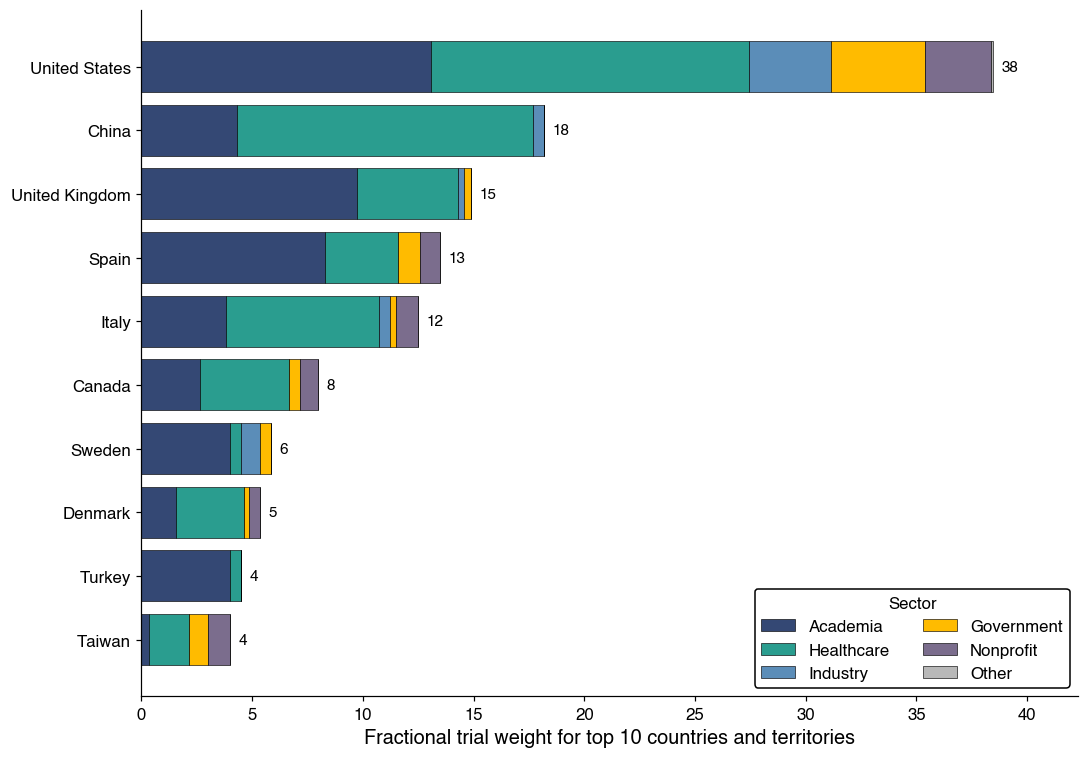

Trials involving >=1 organisation of each sector (can overlap):
Academia      111
Healthcare     99
Government     23
Nonprofit      18
Industry       15
Other           1


In [35]:

# (2) sector breakdown
cs_mat = country_sector_table(df_ct, top_countries=10)
plot_stacked_sectors(cs_mat, "",
                     "Fractional trial weight for top 10 countries and territories",
                     name="ct_where_sector")
plt.show()

# overall sector engagement (trials involving >=1 org of each sector) — the industry vs
# academia headline for the write-up
sector_involvement = pd.Series(
    {s: int(df_ct["org_sectors"].apply(lambda L: s in L).sum()) for s in SECTOR_ORDER}
).sort_values(ascending=False)
print("Trials involving >=1 organisation of each sector (can overlap):")
print(sector_involvement.to_string())


## 8. The UK Biobank papers behind the trials

The **impact core** of this notebook. Each trial's `publication_ids` are matched against the
UK Biobank corpus (`data/df_dimensions.xlsx`); the intersection is the set of **UKB papers
the trials cite**. We persist that matched set as a standalone dataset and explore what
those papers are about.

The matched frame is written to
`data/non_academic/clinic_trials/ct_ukbb_papers.csv` (one row per UKB paper, with
`n_trials` = how many trials reference it).

In [36]:
# =============================================================================
# LOAD the UKB corpus — data/showcase/showcase+/showcase_plus_all_endpoints_wide.parquet
# =============================================================================
# This export (unlike papers_20260713.pkl) carries the field-normalised citation ratios
# (RCR / FCR) and `concepts_scores`, which the earlier pickle had dropped. Parquet reads a
# column subset natively, so no xlsx-style caching is needed.
#
# Two shape notes about this file:
#   * list/dict columns are JSON strings — ast.literal_eval (parse_listcol) handles them,
#     verified across every column we touch;
#   * there is no flat `journal.title`; the journal is a JSON blob {'id','title'}, so we
#     derive `journal.title` from it and keep the downstream code unchanged.
import hashlib
DIM_PARQUET = P.SHOWCASE_PLUS
DIM_COLS = ["id", "date", "title", "abstract", "mesh_terms", "category_for_2020", "category_for",
            "concepts", "concepts_scores", "year", "times_cited",
            "relative_citation_ratio", "field_citation_ratio", "type", "journal"]


def load_ukbb_corpus(path=DIM_PARQUET, cols=DIM_COLS):
    d = filter_analysis_window(pd.read_parquet(path, columns=cols))
    # flatten the journal blob -> the `journal.title` column the rest of the notebook uses
    d["journal.title"] = d["journal"].apply(lambda x: parse_dictcol(x).get("title"))
    return d


corpus = load_ukbb_corpus()
print(f"UKB corpus loaded: {len(corpus):,} papers  "
      f"(RCR present for {corpus['relative_citation_ratio'].notna().sum():,})")

# how many trials reference each UKB paper
pid_counter = Counter(p for ps in df_ct["pids"] for p in ps)
ct_papers = corpus[corpus["id"].isin(pid_counter)].copy()
ct_papers["n_trials"] = ct_papers["id"].map(pid_counter)
add_for_columns(ct_papers, "category_for_2020")
ct_papers = ct_papers.sort_values("n_trials", ascending=False).reset_index(drop=True)

OUT = P.CT_UKBB_PAPERS
ct_papers.to_csv(OUT, index=False)

# how many UKB papers each TRIAL cites (its referenced papers that are in our corpus)
corpus_ids = set(corpus["id"])
df_ct["n_ukbb"] = df_ct["pids"].apply(lambda ps: sum(p in corpus_ids for p in ps))

print(f"Matched UKB papers referenced by trials : {len(ct_papers)}")
print(f"Trials referencing >=1 matched UKB paper : {(df_ct['n_ukbb'] > 0).sum()}/{len(df_ct)}")
print(f"Median citations of matched papers       : {ct_papers['times_cited'].median():.0f}")
print(f"Saved -> {P.raw_path(OUT)}")

UKB corpus loaded: 23,442 papers  (RCR present for 7,687)
Matched UKB papers referenced by trials : 166
Trials referencing >=1 matched UKB paper : 168/168
Median citations of matched papers       : 154
Saved -> data/analysis/non_academic/clinical_trials/ct_ukbb_papers.csv


In [37]:
df = filter_analysis_window(pd.read_parquet(P.SHOWCASE_PLUS))


In [38]:
df.loc[df['clinical_trial_ids'].notna()][['id','title','clinical_trial_ids']]

,id,title,clinical_trial_ids
58,pub.1020559731,Serial Patterns of Ovarian Cancer Biomarkers i...,"[""ISRCTN22488978"",""NCT00058032""]"
69,pub.1022435973,How Does Cardiovascular Disease First Present ...,"[""NCT01164371""]"
132,pub.1034394716,Genome-wide study for circulating metabolites ...,"[""NCT02160899""]"
224,pub.1062816855,OP82 Long-lived parents and cardiovascular out...,"[""NCT02681848""]"
379,pub.1090747969,Association analyses based on false discovery ...,"[""ISRCTN48489393""]"
...,...,...,...
23237,pub.1196516311,Calcium channel blockers increase the risk of ...,"[""NCT04765605""]"
23263,pub.1196588862,Reversal of proteomic aging with exercise—resu...,"[""NCT01803568""]"
23310,pub.1196683872,Shared genetic architecture across fibrotic di...,"[""NCT04905693""]"
23992,pub.1198021065,Enhancing cardiovascular risk assessment: the ...,"[""ACTRN12622000436774""]"


In [39]:
df_ct.loc[df_ct['id']=='NCT04369807']

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,org_sectors,rcdc_all,rcdc_disease,mesh_leaf_disease,mesh_ancestors_condition,mesh_leaf_id_list,icd_leaf,cond_norm,status_stage,n_ukbb
66,"A prospective, longitudinal, observational coh...",COVERSCAN,"[2020, 2021, 2022]",Mapping Organ Health Following COVID-19 Diseas...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]",None,None,...,"[Academia, Healthcare, Industry]","[Digestive Diseases, Infectious Diseases, Biom...","[Digestive Diseases, Infectious Diseases, Coro...","[COVID-19, Metabolic Syndrome, Obesity, Non-al...","[Pneumonia, Viral, Pneumonia, Respiratory Trac...","[D000086382, D024821, D009765, D065626]","{IV Endocrine, nutritional & metabolic (E00–E...",[COVID-19],Completed,1


In [40]:
ct_papers['times_cited'].describe()

count     166.000000
mean      429.096386
std       905.394428
min         1.000000
25%        57.000000
50%       154.000000
75%       458.000000
max      9463.000000
Name: times_cited, dtype: float64

In [41]:
print("Number of clinical trials with relative citation ratio > 1:", len(ct_papers.loc[ct_papers['relative_citation_ratio']>1]))
print("Number of clinical trials with more than one citation:", len(ct_papers.loc[ct_papers['n_trials']>1]))

Number of clinical trials with relative citation ratio > 1: 150
Number of clinical trials with more than one citation: 34


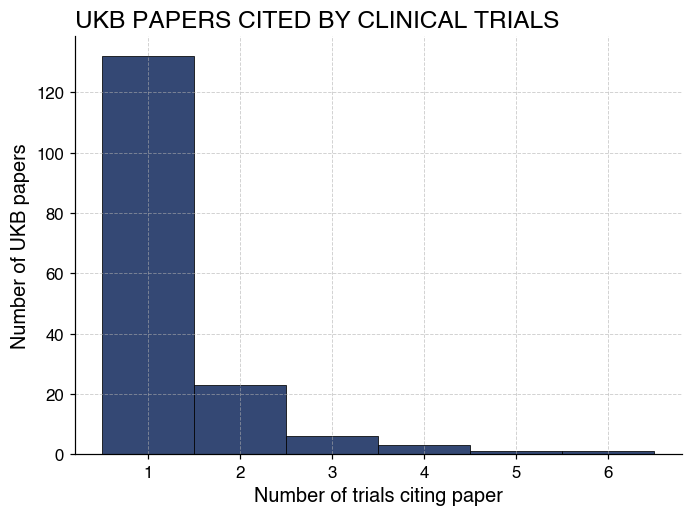

In [42]:
ct_papers["n_trials"].hist(bins=np.arange(1, ct_papers["n_trials"].max() + 2) - 0.5,
                           color=STYLE["c_primary"], edgecolor=STYLE["edgecolor"], linewidth=0.5)
set_title(plt.gca(), "UKB papers cited by clinical trials", fontsize=STYLE["title_fs"], fontweight="bold")
plt.xlabel("Number of trials citing paper", fontsize=STYLE["label_fs"])
plt.ylabel("Number of UKB papers", fontsize=STYLE["label_fs"])
plt.tight_layout(); 
plt.show()

### 8.1 What are those papers about? — research fields & concepts

Two fractional bar charts over the matched UKB papers:

* **(a) Research fields** — the FOR **L4** taxonomy (L2 was too coarse to be interesting);
* **(b) Concepts** — Dimensions' extracted key phrases.

**Both are counted fractionally**: each paper spreads a total weight of **1** across its
distinct items, so a paper tagged with 4 fields (or 70 concepts) cannot outweigh one tagged
with a single field. The column then sums to the number of papers carrying ≥1 item, and the
two panels are on the same footing.

> **Note on `concepts` in this export.** `papers_20260713.pkl` ships `concepts` as a plain
> **list of strings with no relevance scores** (`concepts_scores` is gone), so the earlier
> relevance-weighted ranking is no longer possible. Papers carry a **median of ~70 concepts**
> each, most of them corpus scaffolding — unfiltered, the ranking is just *study · risk ·
> disease · association · participants · biobank*. So we (i) drop generic phrases via the
> explicit `CONCEPT_STOP` list, and (ii) count fractionally, which is what keeps the
> 70-concept papers from swamping the focused ones. Matching is **exact** on the lowercased
> phrase, so bare *"disease"* is dropped while *"cardiovascular disease"* survives.

In [43]:
ct_papers['concepts_scores']

0      [{"concept":"cardiovascular disease risk","rel...
1      [{"concept":"global burden","relevance":0.682}...
2      [{"concept":"genome-wide polygenic scores","re...
3      [{"concept":"Emerging Risk Factors Collaborati...
4      [{"concept":"body-mass index","relevance":0.80...
                             ...                        
161    [{"concept":"association of grip strength","re...
162    [{"concept":"fetal genetic effects","relevance...
163    [{"concept":"urinary sodium excretion","releva...
164    [{"concept":"short-chain fatty acids","relevan...
165    [{"concept":"China Health and Retirement Longi...
Name: concepts_scores, Length: 166, dtype: object

FOR L4   : 158/166 papers carry >=1 field
Concepts : 166/166 papers carry >=1 concept after the stop-list (median 70 raw concepts per paper, 150 phrases stop-listed)


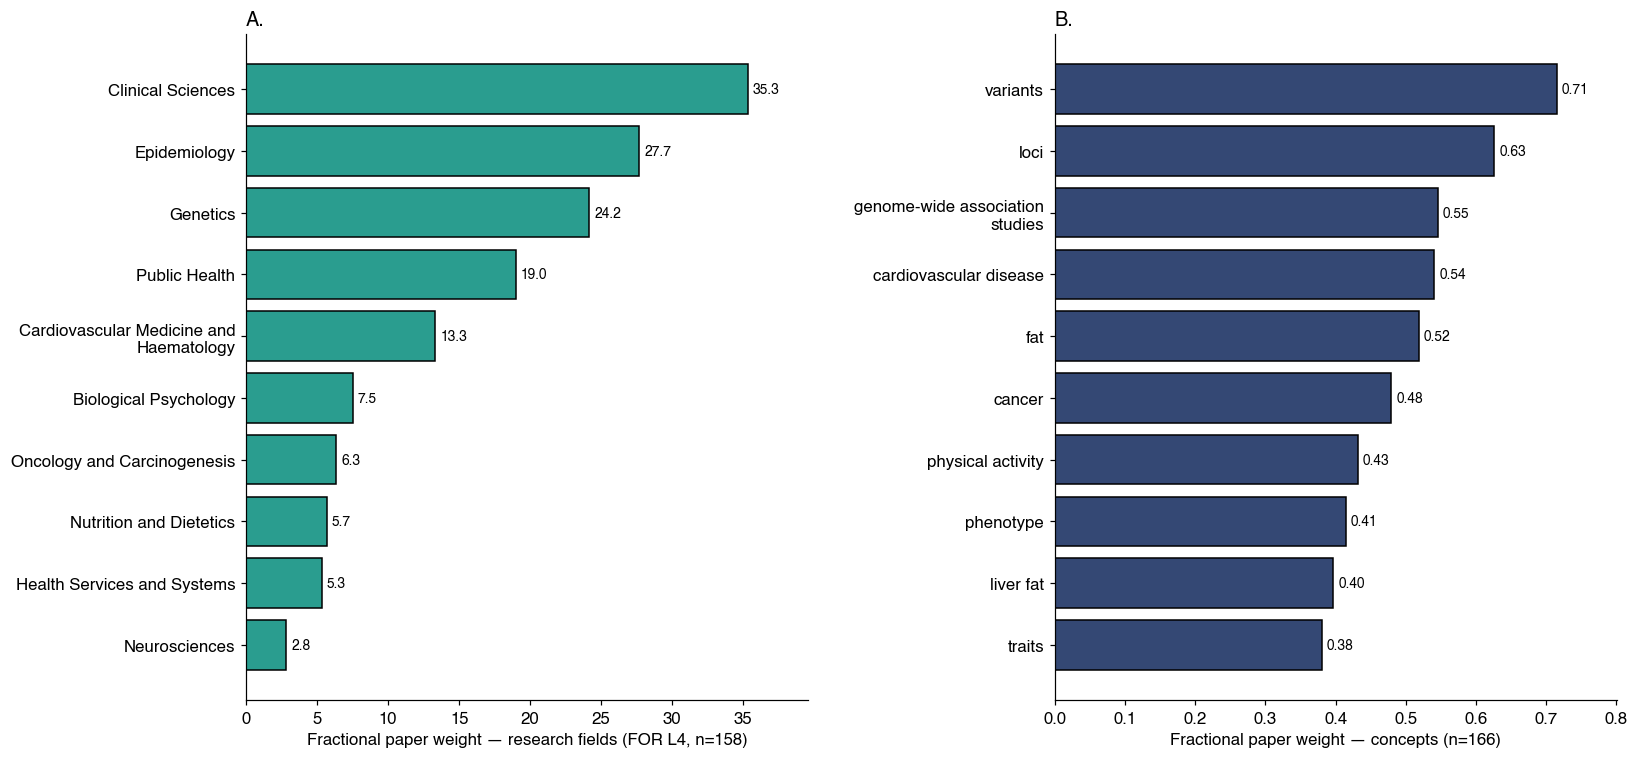


Top fields  : Clinical Sciences (35.3), Epidemiology (27.7), Genetics (24.2), Public Health (19.0), Cardiovascular Medicine and Haematology (13.3)
Top concepts: variants (0.71), loci (0.63), genome-wide association studies (0.55), cardiovascular disease (0.54), fat (0.52)


In [44]:
import textwrap

# The concept stop-list + cleaner live in src/utils/ct_concepts.py, shared with §3.6 so the
# two sections cannot drift apart. Three families (stats / corpus / epidemiology) are kept
# separate in that module so they are easy to audit and extend. Matching is EXACT on the
# lowercased phrase, so bare "disease" is dropped while "cardiovascular disease" survives.
from utils.data_analysis_04_non_academic_clinical_trials_concepts import CONCEPT_STOP, clean_concepts

ct_papers["concepts_clean"] = ct_papers["concepts"].apply(clean_concepts)

# ---- fractional counts: each paper spreads weight 1 across its distinct items ----
for_frac = count_items_frac(ct_papers["for_l4"]).head(10)
con_frac = count_items_frac(ct_papers["concepts_clean"]).head(10)

n_for = int(ct_papers["for_l4"].apply(len).gt(0).sum())
n_con = int(ct_papers["concepts_clean"].apply(len).gt(0).sum())
med_con = ct_papers["concepts"].apply(lambda x: len(parse_listcol(x))).median()
print(f"FOR L4   : {n_for}/{len(ct_papers)} papers carry >=1 field")
print(f"Concepts : {n_con}/{len(ct_papers)} papers carry >=1 concept after the stop-list "
      f"(median {med_con:.0f} raw concepts per paper, {len(CONCEPT_STOP)} phrases stop-listed)")

# wrap long labels so neither axis eats the figure
WRAP = 30
for s in (for_frac, con_frac):
    s.index = [x if len(x) <= WRAP else textwrap.fill(x, width=WRAP) for x in s.index]

cstyle = {**STYLE, "title_fs": 13, "label_fs": 11, "annot_fs": 9}
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

plot_hbar(for_frac, "",
          f"Fractional paper weight — research fields (FOR L4, n={n_for})",
          style=cstyle, color=STYLE["c_green"], fmt="{:.1f}", ax=axes[0])
set_title(axes[0], "a.", loc="left", fontsize=cstyle["title_fs"], fontweight="bold")

plot_hbar(con_frac, "",
          f"Fractional paper weight — concepts (n={n_con})",
          style=cstyle, color=STYLE["c_primary"], fmt="{:.2f}", ax=axes[1])
set_title(axes[1], "b.", loc="left", fontsize=cstyle["title_fs"], fontweight="bold")

fig.tight_layout(w_pad=3); savefig(fig, "ct_ukbb_papers_fields_concepts")
plt.show()

print("\nTop fields  :", ", ".join(f"{k.replace(chr(10), ' ')} ({v:.1f})"
                                  for k, v in for_frac.head(5).items()))
print("Top concepts:", ", ".join(f"{k.replace(chr(10), ' ')} ({v:.2f})"
                                 for k, v in con_frac.head(5).items()))

#### 8.1.1 What is each field *about*? — concept profile per FOR L4

The bars above say *how much* of the cited corpus sits in each field; they don't say what
those papers are **about**. This pairs the same L4 ranking (left, identical order) with a
**heatmap sharing the y-axis** (right): each row is a field, each column one of the **top-10
concepts**, and the cell is the **frequency of that concept among that field's papers** —
i.e. the % of Genetics papers that mention *loci*, the % of Oncology papers that mention
*cancer*, and so on. `Spectral_r` runs cool (rare) → warm (common).

A shared column vocabulary is what makes it a matrix, so the columns are the **top 10
concepts overall**. Each field's *own* top-10 (which is what you'd read off a per-field list)
is printed as a table underneath, since those lists differ from row to row.

> **Row `n` matters.** The percentage is over the papers *in that row*, and the tail fields
> are small — *Oncology and Carcinogenesis* is 89% "cancer" from **9 papers**, *Reproductive
> Medicine* from **6**. The paper count is in each y-label; treat the bottom rows as
> indicative, not as rates. Papers are multi-label, so a paper tagged with 3 L4 fields
> contributes to all 3 rows.

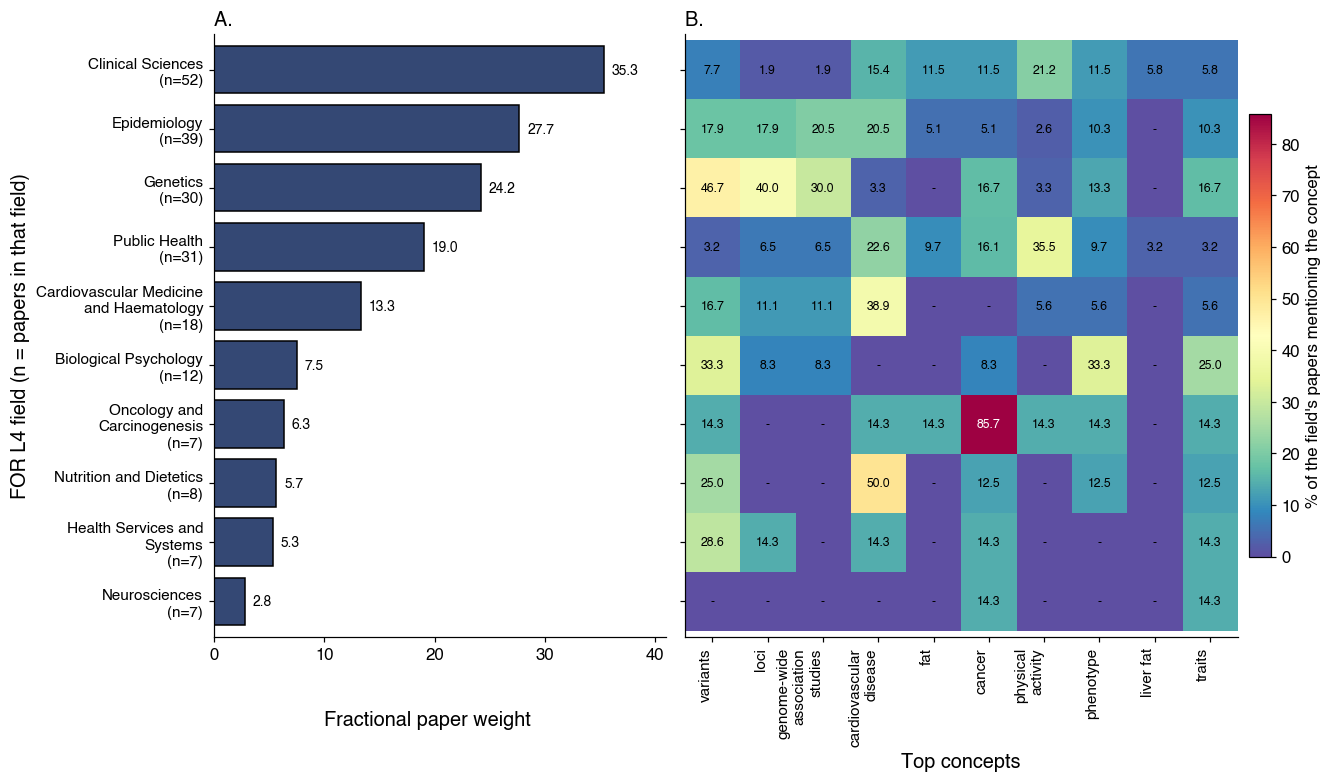

Each field's own top-5 concepts:


,FOR L4 field,papers,top 5 concepts (% of the field's papers)
0,Clinical Sciences,52,"physical activity (21%), volume (23%), cardiovascular disease (15%), hospital (15%), muscle (15%)"
1,Epidemiology,39,"polygenic risk scores (26%), genome-wide association studies (21%), diabetes (21%), risk prediction (21%), cardiovascular disease (21%)"
2,Genetics,30,"loci (40%), genome-wide association studies (30%), variants (47%), association analysis (17%), genotypes (20%)"
3,Public Health,31,"physical activity (35%), cardiovascular disease (23%), behavior (23%), duration (19%), bmi (23%)"
4,Cardiovascular Medicine and Haematology,18,"cardiovascular disease (39%), stroke (28%), sleep (17%), algorithm (22%), risk of cardiovascular disease (17%)"
5,Biological Psychology,12,"brain (50%), overlap (33%), phenotype (33%), variants (33%), variation (25%)"
6,Oncology and Carcinogenesis,7,"cancer (86%), cancer risk (57%), breast (57%), breast cancer (43%), prospective study (43%)"
7,Nutrition and Dietetics,8,"cardiovascular disease (50%), aim (38%), background (38%), intake (38%), risk of cardiovascular disease (25%)"
8,Health Services and Systems,7,"intervention (29%), predisposition (29%), response (29%), variants (29%), genetic variants (29%)"
9,Neurosciences,7,"dementia (57%), progression (43%), all-cause dementia (29%), polygenic risk scores (29%), mechanism (43%)"


In [45]:
# =============================================================================
# FIELD x CONCEPT — what each FOR L4 field is actually about
# =============================================================================
# Rows  : the same top-10 L4 fields as panel (a), same order (shared y-axis)
# Cols  : the top-10 concepts overall (a shared vocabulary is what makes it a matrix)
# Cell  : % of THAT field's papers whose concepts include the concept
TOP_FIELDS, TOP_CONCEPTS = 10, 10

field_frac = count_items_frac(ct_papers["for_l4"]).head(TOP_FIELDS)
fields = list(field_frac.index)
concepts = list(count_items_frac(ct_papers["concepts_clean"]).head(TOP_CONCEPTS).index)

# papers belonging to each field (multi-label: a paper counts in every field it carries)
field_papers = {f: ct_papers[ct_papers["for_l4"].apply(lambda L: f in L)] for f in fields}

heat = pd.DataFrame(
    [[100 * sub["concepts_clean"].apply(lambda C: c in C).mean() for c in concepts]
     for f, sub in field_papers.items()],
    index=fields, columns=concepts)

# y labels carry the row's paper count — the tail fields are small and the % is over them
ylabels = [textwrap.fill(f, 26) + f"\n(n={len(field_papers[f])})" for f in fields]

# ---- draw: bars (left) + heatmap (right), sharing the y-axis --------------------------
# Both panels use numeric y positions in ASCENDING order (largest field on top), so the
# shared axis lines up row-for-row with panel (a).
n = len(fields)
y = np.arange(n)
vals = field_frac.values[::-1]
M = heat.values[::-1, :]
ylabels_r = ylabels[::-1]

fig, (ax0, ax1) = plt.subplots(
    1, 2, figsize=(12, 7), sharey=True, layout="constrained",
    gridspec_kw={"width_ratios": [0.9, 1.1]})

bars = ax0.barh(y, vals, color=STYLE["c_primary"], edgecolor=STYLE["edgecolor"], linewidth=1)
for b, v in zip(bars, vals):
    ax0.text(v + vals.max() * 0.02, b.get_y() + b.get_height() / 2, f"{v:.1f}",
             va="center", fontsize=STYLE["annot_fs"] - 1)
ax0.set_yticks(y)
ax0.set_yticklabels(ylabels_r, fontsize=STYLE["tick_fs"] - 1)
ax0.text(10, -2.1, "Fractional paper weight" ,fontsize=STYLE["label_fs"])

ax0.set_ylabel("FOR L4 field (n = papers in that field)", fontsize=STYLE["label_fs"])
set_title(ax0, "a. ",
              loc="left", fontsize=13, fontweight="bold")
ax0.margins(x=0.16)
ax0.set_ylim(-0.6, n - 0.4)

im = ax1.imshow(M, aspect="auto", cmap="Spectral_r", origin="lower", vmin=0,
                extent=(-0.5, len(concepts) - 0.5, -0.5, n - 0.5))
ax1.set_xticks(range(len(concepts)))
ax1.set_xticklabels([textwrap.fill(c, 14) for c in concepts],
                     ha="right", fontsize=STYLE["tick_fs"] - 1,rotation=90)
vmax = M.max()
for i in range(n):
    for j in range(len(concepts)):
        ax1.text(j, i, f"{M[i, j]:.1f}" if M[i, j] > 0 else "-", ha="center", va="center",
                 fontsize=STYLE["annot_fs"] - 2,
                 color="white" if M[i, j] > 0.72 * vmax else "black")
set_title(ax1, "b. ",
              loc="left", fontsize=13, fontweight="bold")
cb = fig.colorbar(im, ax=ax1, pad=0.02, fraction=0.04)
ax1.set_xlabel("Top concepts", fontsize=STYLE["label_fs"])
cb.set_label("% of the field's papers mentioning the concept",
             fontsize=STYLE["label_fs"] - 2)

savefig(fig, "ct_field_concept_heatmap")
plt.show()

# ---- each field's OWN top-5 concepts (the per-field list the heatmap columns can't show)
rows = []
for f, sub in field_papers.items():
    top = count_items_frac(sub["concepts_clean"]).head(5)
    share = {c: 100 * sub["concepts_clean"].apply(lambda C: c in C).mean() for c in top.index}
    rows.append({"FOR L4 field": f, "papers": len(sub),
                 "top 5 concepts (% of the field's papers)":
                     ", ".join(f"{c} ({share[c]:.0f}%)" for c in top.index)})
print("Each field's own top-5 concepts:")
with pd.option_context("display.max_colwidth", 200):
    display(pd.DataFrame(rows))

### 8.2 Citation impact & how intensively trials draw on UK Biobank

Two distributions in one figure: **(left)** raw citations of the cited papers
(`times_cited` — heavily-cited landmark papers); **(right)** how many UKB papers each
*trial* cites. (How many trials re-use each paper is printed below the figure.)

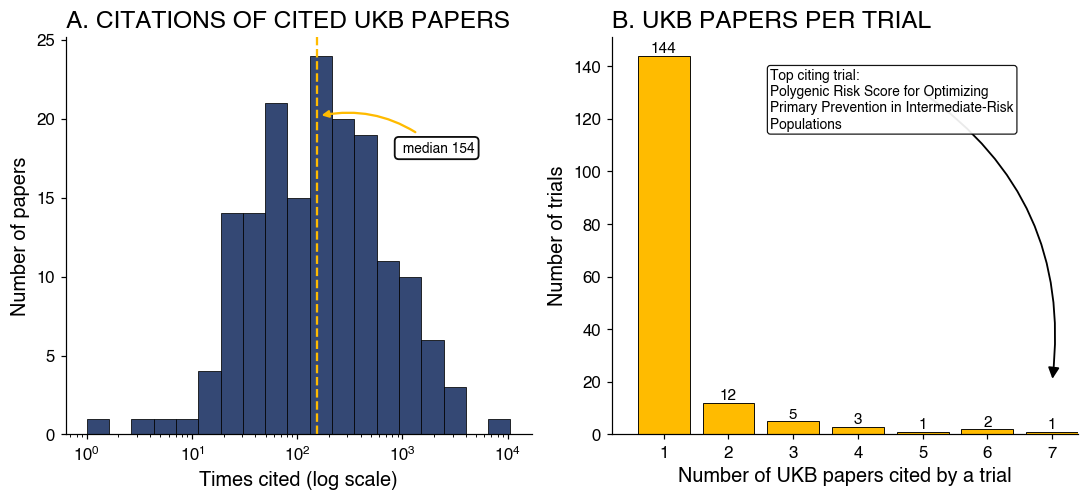

Trials per UKB paper: 34 papers cited by >1 trial (max 6).


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# (a) raw citation counts (times_cited), log scale
ax = axes[0]
c = ct_papers["times_cited"].clip(lower=1)
ax.hist(c, bins=np.logspace(0, np.log10(c.max()) + 0.05, 20),
        color=STYLE["c_primary"], edgecolor=STYLE["edgecolor"], linewidth=0.5)
ax.set_xscale("log")
med = ct_papers["times_cited"].median()
ax.axvline(med, ls="--", color=STYLE["c_gold"], linewidth=1.5)

ax.annotate(
    f" median {int(med)}",
    xy=(med, ax.get_ylim()[1] * 0.80),          # arrow points here
    xytext=(med * 6, ax.get_ylim()[1] * 0.72),  # text box position
    fontsize=STYLE["annot_fs"] - 1,
    color="black",
    ha="left",
    va="center",

    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        lw=1.2,
        alpha=0.95,
    ),

    arrowprops=dict(
        arrowstyle="-|>",
        color=STYLE["c_gold"],
        lw=1.5,
        connectionstyle="arc3,rad=0.25",   # <-- curved arrow
        shrinkA=5,
        shrinkB=3,
    ),
)

#ax.text(med+10, ax.get_ylim()[1]*0.4, f" median {int(med)}", rotation=90, va="top", ha="left",
#        color=STYLE["c_gold"], fontsize=STYLE["annot_fs"])
ax.set_xlabel("Times cited (log scale)", fontsize=STYLE["label_fs"])
ax.set_ylabel("Number of papers", fontsize=STYLE["label_fs"])
set_title(ax, f"a. Citations of cited UKB papers",
             fontsize=STYLE["title_fs"], fontweight="bold", loc="left")

# (b) UKB papers cited per trial
vc1 = df_ct["n_ukbb"].value_counts().sort_index()
axes[1].bar(vc1.index, vc1.values, color=STYLE["c_gold"],
            edgecolor=STYLE["edgecolor"], linewidth=0.6)
for x, v in zip(vc1.index, vc1.values):
    axes[1].text(x, v, str(int(v)), ha="center", va="bottom", fontsize=STYLE["annot_fs"])
axes[1].set_xlabel("Number of UKB papers cited by a trial", fontsize=STYLE["label_fs"])
axes[1].set_ylabel("Number of trials", fontsize=STYLE["label_fs"])
set_title(axes[1], f"b. UKB papers per trial",
                  fontsize=STYLE["title_fs"], fontweight="bold", loc="left")

axes[1].text(0.34, 0.92, f"Top citing trial: \n{textwrap.fill(df_ct.loc[df_ct['n_ukbb'].idxmax(), 'brief_title'], width=40)} ", 
                transform=axes[1].transAxes, fontsize=STYLE["annot_fs"] - 1, ha="left", va="top",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.92))

# add a curve arrow pointing to the annotated trial box from x=7, y=vc1.loc[7] + 5
# a curved arrow can be drawn using FancyArrowPatch, 
from matplotlib.patches import FancyArrowPatch
arrow = FancyArrowPatch( (5, 130), 
                        (7, 20),
                        connectionstyle="arc3,rad=-0.3", 
                        arrowstyle='-|>', 
                        mutation_scale=15, 
                        color='black', 
                        linewidth=1.2)
axes[1].add_patch(arrow)
axes[1].set_xlim(0.2, vc1.index.max()+0.4)
fig.tight_layout(rect=[0, 0, 1, 0.93]); savefig(fig, "ct_ukbb_papers_impact")
plt.show()
print(f"Trials per UKB paper: {(ct_papers['n_trials']>1).sum()} papers cited by >1 trial "
      f"(max {int(ct_papers['n_trials'].max())}).")

In [47]:
df_ct.loc[df_ct['n_ukbb']>=4]

,abstract,acronym,active_years,brief_title,category_bra,category_for,category_for_2020,category_hra,category_hrcs_hc,category_hrcs_rac,...,org_sectors,rcdc_all,rcdc_disease,mesh_leaf_disease,mesh_ancestors_condition,mesh_leaf_id_list,icd_leaf,cond_norm,status_stage,n_ukbb
1,The aim of this study is to determine the effe...,None,"[2022, 2023]",Utilization of MAsS in Patients Undergoing LT ...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '899', 'name': 'Oral and gastrointesti...",None,...,"[Academia, Healthcare, Industry]","[Liver Cancer, Infectious Diseases, Digestive ...","[Liver Cancer, Infectious Diseases, Digestive ...","[Non-alcoholic Fatty Liver Disease, Carcinoma,...","[Fatty Liver, Digestive System Diseases, Adeno...","[D065626, D006528, D008107, D008113, D008103, ...","{I Infectious & parasitic (A00–B99), II Neo...","[Cirrhosis, liver, Hepatitis c, Hepatocellular...",Stopped early,4
2,Prospective natural history pilot study to exp...,None,"[2022, 2023, 2024, 2025, 2026, 2027]",Adverse Outcomes and Mortality in Liver Transp...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '900', 'name': 'Musculoskeletal'}]","[{'id': '10401', 'name': '4.1 Discovery and pr...",...,"[Healthcare, Industry]",[Health Disparities and Racial or Ethnic Minor...,"[Sarcopenia, Liver Disease, Digestive Diseases...","[End Stage Liver Disease, Sarcopenia, Fibrosis]","[Liver Failure, Hepatic Insufficiency, Liver D...","[D058625, D055948, D005355]","{XVIII Symptoms & signs (R00–R99), VI Nervous...","[Cirrhosis, End stage liver DIsease, Sarcopeni...",Ongoing,6
29,This study looks at how physical activity leve...,None,"[2025, 2026]",Triaxial Accelerometry Study,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '80003', 'name': '32 Biomedical and Cl...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '900', 'name': 'Musculoskeletal'}]","[{'id': '10604', 'name': '6.4 Surgery'}]",...,"[Academia, Healthcare]","[Arthritis, Assistive Technology, Clinical Res...",[Arthritis],[],[Behavior],[],{},"[Accelerometers, Resurfacing hip arthroplasty,...",Completed,4
54,This trial will determine the clinical effecti...,GenoVA,"[2020, 2021, 2022, 2023, 2024, 2025]",The Genomic Medicine at VA Study,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '3901', 'name': 'Clinical'}]",None,"[{'id': '10701', 'name': '7.1 Individual care ...",...,"[Academia, Healthcare, Nonprofit]","[Diabetes, Aging, Colo-Rectal Cancer, Comparat...","[Diabetes, Colo-Rectal Cancer, Cardiovascular,...","[Coronary Artery Disease, Atrial Fibrillation,...","[Coronary Disease, Myocardial Ischemia, Heart ...","[D003324, D001281, D003924, D015179, D001943, ...","{XII Skin (L00–L99), II Neoplasms (C00–D48), ...","[Atrial fibrillation, Breast cancer, Colorecta...",Ongoing,6
59,The goal of this clinical trial is to determin...,PERSONAL,"[2025, 2026, 2027]",Polygenic Risk Score for Optimizing Primary Pr...,"[{'id': '4001', 'name': 'Clinical Medicine and...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '80002', 'name': '31 Biological Scienc...","[{'id': '3901', 'name': 'Clinical'}]","[{'id': '894', 'name': 'Cardiovascular'}]","[{'id': '10301', 'name': '3.1 Primary preventi...",...,[Academia],"[Clinical Research, Cardiovascular, Health Ser...","[Cardiovascular, Heart Disease, Atherosclerosi...",[Cardiovascular Diseases],"[Genetic Predisposition to Disease, Disease Su...",[D002318],{IX Circulatory system (I00–I99)},[Primary prevention of cardiovascular disease],Ongoing,7
60,Alzheimer's disease (AD) clinically cha

In [48]:
ct_papers.sort_values("n_trials", ascending=False).head(5)[['n_trials','relative_citation_ratio','year','journal.title','title']]

,n_trials,relative_citation_ratio,year,journal.title,title
0,6,66.42,2021,European Heart Journal,SCORE2 risk prediction algorithms: new models ...
1,5,34.11,2018,Nature,Facing up to the global challenges of ageing
2,4,71.57,2018,Nature Genetics,Genome-wide polygenic scores for common diseas...
4,4,74.29,2016,The Lancet,Body-mass index and all-cause mortality: indiv...
3,4,22.79,2015,JAMA: The Journal of the American Medical Asso...,Association of Cardiometabolic Multimorbidity ...


In [49]:
ct_papers

,id,date,title,abstract,mesh_terms,category_for_2020,category_for,concepts,concepts_scores,year,...,relative_citation_ratio,field_citation_ratio,type,journal,journal.title,n_trials,for_l2,for_l4,n_for_l2,concepts_clean
0,pub.1137772600,2021-06-13,SCORE2 risk prediction algorithms: new models ...,"AIMS: The aim of this study was to develop, va...","[""Algorithms"",""Blood Pressure"",""Cardiovascular...","[{""id"":""80003"",""name"":""32 Biomedical and Clini...","[{""id"":""80003"",""name"":""32 Biomedical and Clini...","[""cardiovascular disease risk"",""low-risk count...","[{""concept"":""cardiovascular disease risk"",""rel...",2021,...,66.42,608.95,article,"{""id"":""jour.1091325"",""title"":""European Heart J...",European Heart Journal,6,[Biomedical and Clinical Sciences],"[Cardiovascular Medicine and Haematology, Clin...",1,"[cardiovascular disease risk, low-risk countri..."
1,pub.1106432308,2018-09-05,Facing up to the global challenges of ageing,Longer human lives have led to a global burden...,"[""Aged"",""Aging"",""Animals"",""Biomarkers"",""Cellul...","[{""id"":""80138"",""name"":""4203 Health Services an...","[{""id"":""80138"",""name"":""4203 Health Services an...","[""global burden"",""electronic health records"",""...","[{""concept"":""global burden"",""relevance"":0.682}...",2018,...,34.11,314.31,article,"{""id"":""jour.1018957"",""title"":""Nature""}",Nature,5,[Health Sciences],[Health Services and Systems],1,"[global burden, electronic health records, lat..."
2,pub.1106070346,2018-08-13,Genome-wide polygenic scores for common diseas...,A key public health need is to identify indivi...,"[""Adult"",""Aged"",""Disease"",""Female"",""Genetic Pr...","[{""id"":""80002"",""name"":""31 Biological Sciences""...","[{""id"":""80002"",""name"":""31 Biological Sciences""...","[""genome-wide polygenic scores"",""monogenic mut...","[{""concept"":""genome-wide polygenic scores"",""re...",2018,...,71.57,347.54,article,"{""id"":""jour.1103138"",""title"":""Nature Genetics""}",Nature Genetics,4,[Biological Sciences],[Genetics],1,"[genome-wide polygenic scores, monogenic mutat..."
3,pub.1022462306,2015-07-07,Association of Cardiometabolic Multimorbidity ...,IMPORTANCE: The prevalence of cardiometabolic ...,"[""Adult"",""Aged"",""Comorbidity"",""Diabetes Mellit...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[""Emerging Risk Factors Collaboration"",""histor...","[{""concept"":""Emerging Risk Factors Collaborati...",2015,...,22.79,169.00,article,"{""id"":""jour.1081531"",""title"":""JAMA: The Journa...",JAMA: The Journal of the American Medical Asso...,4,[Health Sciences],"[Epidemiology, Public Health]",1,"[emerging risk factors collaboration, history ..."
4,pub.1037627059,2016-07-13,Body-mass index and all-cause mortality: indiv...,BACKGROUND: Overweight and obesity are increas...,"[""Adult"",""Aged"",""Asia"",""Australia"",""Body Mass ...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[""body-mass index"",""high body-mass index"",""haz...","[{""concept"":""body-mass index"",""relevance"":0.80...",2016,...,74.29,423.92,article,"{""id"":""jour.1077219"",""title"":""The Lancet""}",The Lancet,4,"[Biomedical and Clinical Sciences, Health Scie...","[Epidemiology, Public Health]",2,"[body-mass index, high body-mass index, analys..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,pub.1114351972,2019-09-01,The association of grip strength with health o...,BACKGROUND: higher grip strength is associated...,"[""Adult"",""Aged"",""Cardiovascular Diseases"",""Cau...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[{""id"":""80137"",""name"":""4202 Epidemiology""},{""i...","[""association of grip strength"",""higher grip s...","[{""concept"":""association of grip strength"",""re...",2019,...,3.28,12.69,article,"{""id"":""jour.1017780""

### 8.3 Timeliness & venues — how fast, and from where

Three disclosures that strengthen the impact / funding case:

* **Publication years** of the cited papers — a young, active evidence base;
* **Time-to-trial lag** (`trial start year − paper year`) — how quickly UKB findings reach
  the clinic. We show only **positive** lags (paper precedes trial); links with lag ≤ 0 are
  excluded and counted in the note below — these are trials whose start date pre-dates a
  paper they reference, most likely because the trial record's reference list was **edited /
  updated after registration**;
* **Top journals** — the calibre of the venues the trials are drawing on.

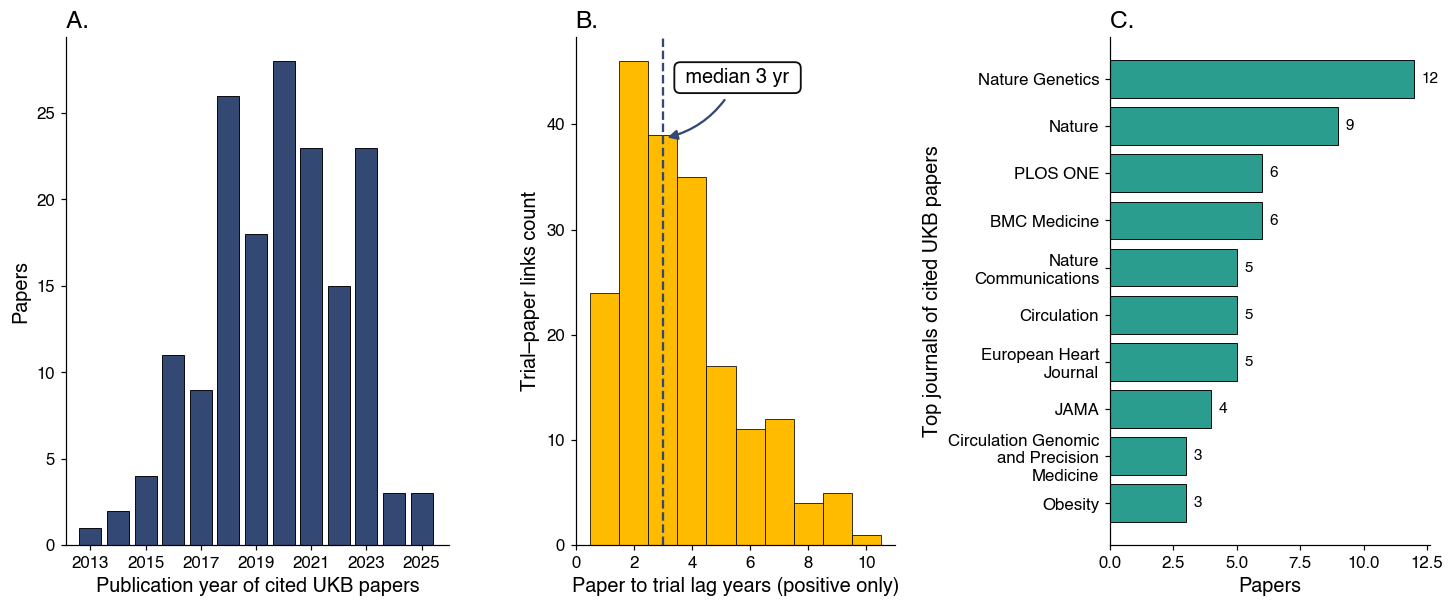

Paper→trial lag (positive only): median 3 yr, mean 3.6 yr over 194 links.
Excluded 25 links with lag <= 0 (12 strictly negative) — trials whose start date pre-dates a referenced paper, likely from post-registration edits.


In [50]:
# lag: for every (trial, cited UKB paper) pair, trial start year - paper publication year
paper_year = dict(zip(ct_papers["id"], ct_papers["year"]))
lags = []
for _, r in df_ct.iterrows():
    sy = r["start_year"]
    if pd.isna(sy):
        continue
    for p in r["pids"]:
        if p in paper_year and pd.notna(paper_year[p]):
            lags.append(int(sy) - int(paper_year[p]))
lags = pd.Series(lags)
lags_pos = lags[lags > 0]                 # keep only positive lags (paper precedes trial)
n_nonpos = int((lags <= 0).sum())
n_neg = int((lags < 0).sum())

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 6),
    gridspec_kw={
        "width_ratios": [1.2,1,1],
        "wspace": 0.5  # increase horizontal spacing
    }
)

# (a) publication years of the cited papers
yr = ct_papers["year"].dropna().astype(int)
yc = yr.value_counts().sort_index()
axes[0].bar([int(x) for x in yc.index], yc.values, color=STYLE["c_primary"],
            edgecolor=STYLE["edgecolor"], linewidth=0.6)
set_title(axes[0], "a. ", fontsize=STYLE["title_fs"], fontweight="bold", loc="left")
axes[0].set_xlabel("Publication year of cited UKB papers"); axes[0].set_ylabel("Papers")
axes[0].set_xlim(ANALYSIS_START_YEAR - 0.9, ANALYSIS_END_YEAR + 1)
axes[0].set_xticks(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1, 2))
#axes[0].set_xticklabels(range(2012, max(yr) + 1), ha="right", fontsize=STYLE["label_fs"] - 1)

# (b) time-to-trial lag — POSITIVE lags only (paper precedes trial start)
axes[1].hist(lags_pos, bins=range(1, int(lags_pos.max()) + 2),
             color=STYLE["c_gold"], edgecolor=STYLE["edgecolor"], linewidth=0.5, align="left")
axes[1].axvline(lags_pos.median(), ls="--", color=STYLE["c_primary"], linewidth=1.5)

axes[1].annotate(
    f" median {lags_pos.median():.0f} yr ",
    xy=(lags_pos.median(), axes[1].get_ylim()[1] * 0.80),          # arrow points here
    xytext=(lags_pos.median() * 1.2, axes[1].get_ylim()[1] * 0.92),  # text box position
    fontsize=STYLE["annot_fs"] +3,
    color="black",
    ha="left",
    va="center",

    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        lw=1.2,
        alpha=0.95,
    ),

    arrowprops=dict(
        arrowstyle="-|>",
        color=STYLE["c_primary"],
        lw=1.5,
        connectionstyle="arc3,rad=-0.25",   # <-- curved arrow
        shrinkA=5,
        shrinkB=3,
    ),
)

# add a curved arrow pointing to the median line

#axes[1].text(lags_pos.median(), axes[1].get_ylim()[1]*0.93, f" median {lags_pos.median():.0f} yr",
#             color=STYLE["c_gold"], fontsize=STYLE["annot_fs"])
set_title(axes[1], "b.", fontsize=STYLE["title_fs"], fontweight="bold", loc="left")
axes[1].set_xlabel("Paper to trial lag years (positive only)"); axes[1].set_ylabel("Trial–paper links count")
#axes[1].text(0.97, 0.72, f"excluded (lag ≤ 0): {n_nonpos}\n  of which lag < 0: {n_neg}",
#             transform=axes[1].transAxes, ha="right", va="top",
#             fontsize=STYLE["annot_fs"] - 1, color="#555",
#             bbox=dict(boxstyle="round,pad=0.3", fc="#F4F4F4", ec="#CCC"))

# (c) top journals
jc = ct_papers["journal.title"].value_counts().head(10).sort_values()
axes[2].barh([textwrap.fill(j if 'JAMA' not in j else 'JAMA', width=20) for j in jc.index.astype(str)], jc.values, color=STYLE["c_green"],
             edgecolor=STYLE["edgecolor"], linewidth=0.6)
for i, v in enumerate(jc.values):
    axes[2].text(v + 0.3, i, str(int(v)), va="center", fontsize=STYLE["annot_fs"])
set_title(axes[2], "c. ", fontsize=STYLE["title_fs"], fontweight="bold", loc="left")
axes[2].set_ylabel("Top journals of cited UKB papers");
axes[2].set_xlabel("Papers")

pos1 = axes[1].get_position()
axes[1].set_position([
    pos1.x0 - 0.025,  # move panel b left
    pos1.y0,
    pos1.width,
    pos1.height,
])


fig.tight_layout()
savefig(fig, "ct_papers_timeliness")
plt.show()
print(f"Paper→trial lag (positive only): median {lags_pos.median():.0f} yr, "
      f"mean {lags_pos.mean():.1f} yr over {len(lags_pos)} links.")
print(f"Excluded {n_nonpos} links with lag <= 0 ({n_neg} strictly negative) — trials whose "
      f"start date pre-dates a referenced paper, likely from post-registration edits.")

### 8.4 Title word cloud + the most-referenced papers

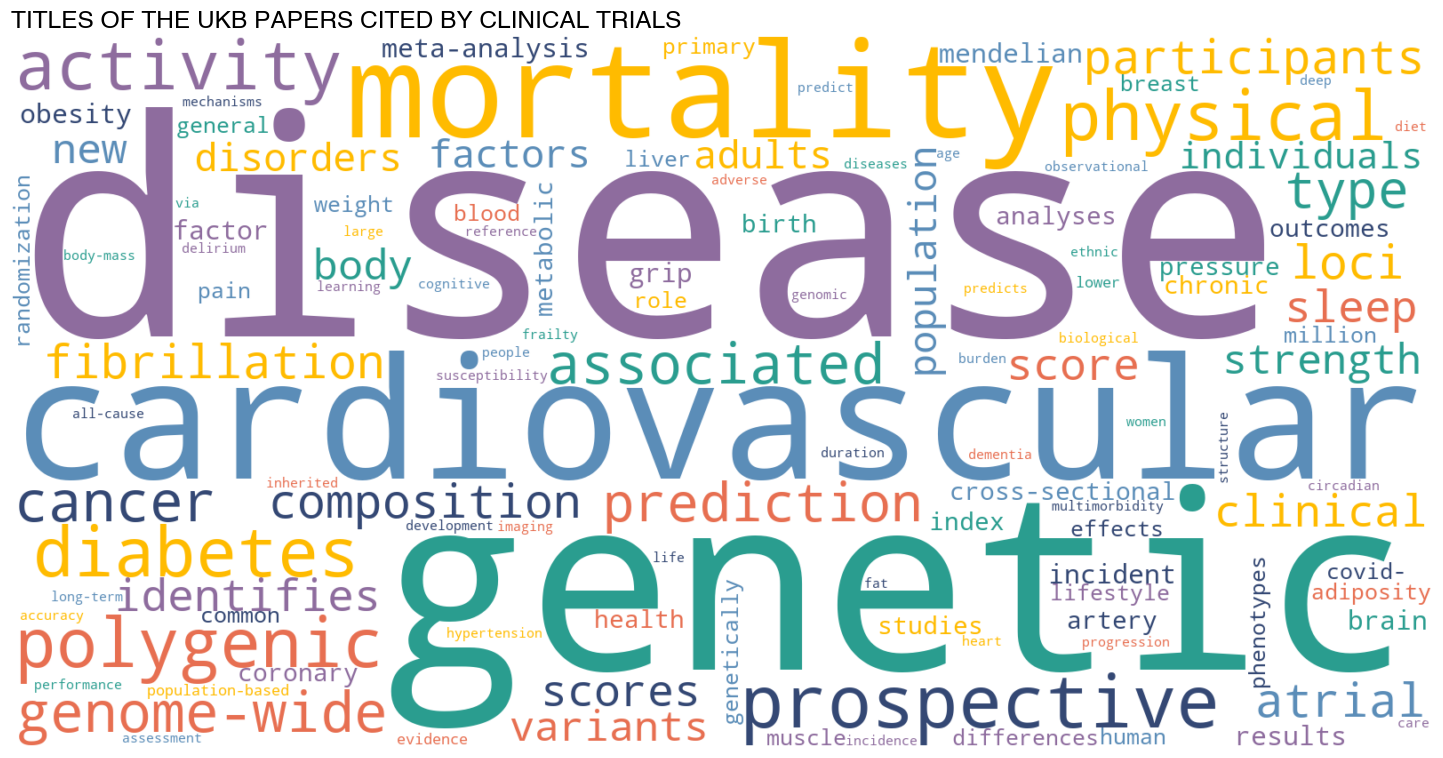

Most-referenced UKB papers (by number of citing trials):


,n_trials,RCR,times_cited,year,journal,title
0,6,66.42,1722,2021,European Heart Journal,SCORE2 risk prediction algorithms: new models ...
1,5,34.11,1395,2018,Nature,Facing up to the global challenges of ageing
2,4,71.57,3092,2018,Nature Genetics,Genome-wide polygenic scores for common diseas...
3,4,22.79,1039,2015,JAMA: The Journal of the American Medical Asso...,Association of Cardiometabolic Multimorbidity ...
4,4,74.29,2548,2016,The Lancet,Body-mass index and all-cause mortality: indiv...
5,3,4.27,155,2016,PLOS ONE,Feasibility of MR-Based Body Composition Analy...
6,3,4.92,158,2013,Journal of the American Medical Directors Asso...,New Normative Values for Handgrip Strength: Re...
7,3,6.60,226,2018,Obesity,Body Composition Profiling in the UK Biobank I...
8,3,110.15,3790,2015,NeuroImage,An integrated approach to correction for off-r...
9,3,8.69,144,2022,BMC Medicine,"Associations between grip strength, brain stru..."


In [51]:
from wordcloud import STOPWORDS
extra_stop = {"biobank", "uk", "study", "using", "analysis", "based", "cohort",
              "association", "associations", "risk", "among", "data"}
stop = set(map(str.lower, STOPWORDS)) | extra_stop
words = Counter()
for t in ct_papers["title"].dropna():
    for w in re.findall(r"[A-Za-z][A-Za-z\-]{2,}", t.lower()):
        if w not in stop:
            words[w] += 1
plot_wordcloud(words, "Titles of the UKB papers cited by clinical trials",
               name="ct_ukbb_paper_titles")
plt.show()

print("Most-referenced UKB papers (by number of citing trials):")
display(ct_papers.head(10)[["n_trials", "relative_citation_ratio", "times_cited",
                            "year", "journal.title", "title"]]
        .rename(columns={"relative_citation_ratio": "RCR", "journal.title": "journal"})
        .reset_index(drop=True))

In [52]:
df_ct['country']=df_ct['research_orgs'].apply(lambda x: [o.get('country_name') for o in parse_listcol(x) if isinstance(o, dict) and o.get('country_name')])

In [53]:
df_ct_uk =df_ct.loc[df_ct['country'].apply(lambda x: 'United Kingdom' in x if isinstance(x, list) else False)]

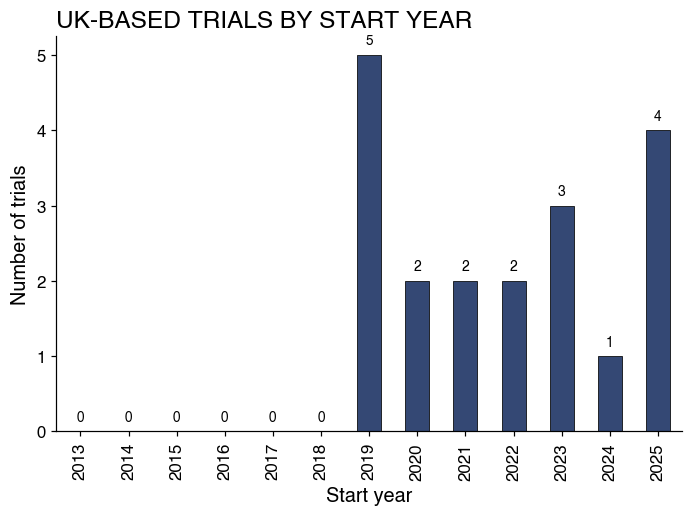

In [54]:
df_ct_uk['start_year'] = df_ct_uk['start_year'].astype(int)
df_ct_uk['start_year'].value_counts().reindex(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1), fill_value=0).plot(kind='bar', color=STYLE["c_primary"], edgecolor=STYLE["edgecolor"], linewidth=0.5)
# put annotations on the top of each bar with the count
for i, v in enumerate(df_ct_uk['start_year'].value_counts().reindex(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1), fill_value=0).values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=STYLE["annot_fs"] - 1)
set_title(plt.gca(), "UK-based trials by start year", fontsize=STYLE["title_fs"], fontweight="bold")
plt.xlabel("Start year", fontsize=STYLE["label_fs"])
plt.ylabel("Number of trials", fontsize=STYLE["label_fs"])
plt.tight_layout()

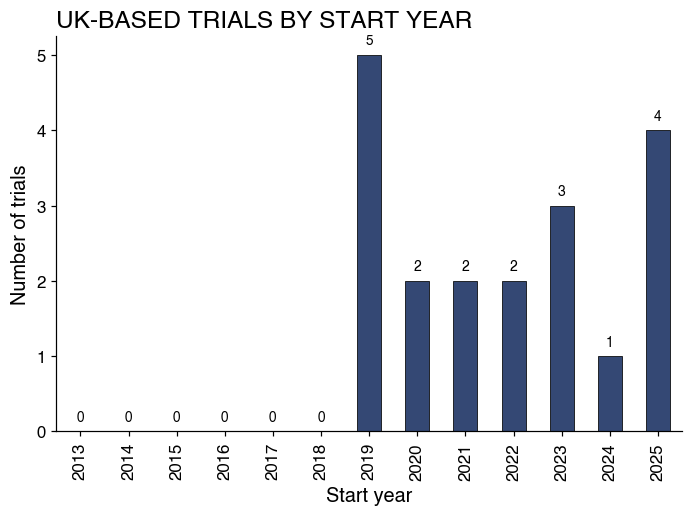

In [55]:
df_ct_uk['start_year'] = df_ct_uk['start_year'].astype(int)
df_ct_uk['start_year'].value_counts().reindex(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1), fill_value=0).plot(kind='bar', color=STYLE["c_primary"], edgecolor=STYLE["edgecolor"], linewidth=0.5)
# put annotations on the top of each bar with the count
for i, v in enumerate(df_ct_uk['start_year'].value_counts().reindex(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1), fill_value=0).values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=STYLE["annot_fs"] - 1)
set_title(plt.gca(), "UK-based trials by start year", fontsize=STYLE["title_fs"], fontweight="bold")
plt.xlabel("Start year", fontsize=STYLE["label_fs"])
plt.ylabel("Number of trials", fontsize=STYLE["label_fs"])
plt.tight_layout()